<a href="https://colab.research.google.com/github/Shruti-06/DATA70202_P3_BAE_Systems/blob/main/DATA70202_P3_BAE_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BAE Systems: Predictive Maintenance of Hydraulic Systems**


---


### **Project Overview**
This notebook implements a data-driven prognosis health management framework for hydraulic system fault diagnosis, developed in partnership with BAE Systems as part of DATA70202: Applying Data Science (MSc Data Science, University of Manchester).

### **Team P3**
Akash Rajendran · Shruti Kishor Patil · Shuting Wang · Yihan Chen · Yishu Liang

Industry Mentor: Andrew Gordon (BAE Systems) | UoM Mentor: Zhonghua Zheng

### **Aim**
To develop a robust predictive maintenance framework for hydraulic system condition monitoring, evaluated under realistic temporal deployment settings.
Dataset: https://www.kaggle.com/datasets/mayank1897/condition-monitoring-of-hydraulic-systems/data

### **Notebook Structure**
| Section | Description |
|---------|-------------|
| 1 | Data Loading |
| 2 | Data Quality & Outlier Analysis |
| 3 | Target Variable Analysis |
| 4 | Sensor Signal Visualisation |
| 5 | Feature Engineering |
| 6 | Dual Validation Strategy |
| 7 | Modelling |
| 8 | Evaluation & Error Analysis |
| 9 | Confidence & Uncertainty Analysis |
| 10 | Results, Sensor Validation & BAE Recommendations |


### **Key Design Decisions**
- Dual split strategy - random split for feature validation, temporal block split at cycle 1,664 for deployment simulation
- class_weight='balanced' - used across all classifiers to handle class imbalance; SMOTE ruled out after supervisor consultation
- Target-specific models - separate model selected per hydraulic component based on temporal block split performance
- Confidence thresholds - 70% confidence threshold applied to assess deployment readiness per component

# **SETUP and CONFIGURATION**

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from scipy import stats
from scipy.stats import kurtosis, entropy, kruskal
from scipy.fft import rfft
from itertools import combinations

from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, balanced_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

In [2]:
# Sensor registry
SENSORS = {
    'PS1':  {'hz': 100, 'unit': 'bar',   'desc': 'Pressure sensor 1 (pump outlet)'},
    'PS2':  {'hz': 100, 'unit': 'bar',   'desc': 'Pressure sensor 2'},
    'PS3':  {'hz': 100, 'unit': 'bar',   'desc': 'Pressure sensor 3'},
    'PS4':  {'hz': 100, 'unit': 'bar',   'desc': 'Pressure sensor 4'},
    'PS5':  {'hz': 100, 'unit': 'bar',   'desc': 'Pressure sensor 5'},
    'PS6':  {'hz': 100, 'unit': 'bar',   'desc': 'Pressure sensor 6'},
    'EPS1': {'hz': 100, 'unit': 'W',     'desc': 'Motor power'},
    'FS1':  {'hz': 10,  'unit': 'l/min', 'desc': 'Volume flow sensor 1'},
    'FS2':  {'hz': 10,  'unit': 'l/min', 'desc': 'Volume flow sensor 2'},
    'TS1':  {'hz': 1,   'unit': 'deg C', 'desc': 'Temperature sensor 1'},
    'TS2':  {'hz': 1,   'unit': 'deg C', 'desc': 'Temperature sensor 2'},
    'TS3':  {'hz': 1,   'unit': 'deg C', 'desc': 'Temperature sensor 3'},
    'TS4':  {'hz': 1,   'unit': 'deg C', 'desc': 'Temperature sensor 4'},
    'VS1':  {'hz': 1,   'unit': 'mm/s',  'desc': 'Vibration sensor'},
    'CE':   {'hz': 1,   'unit': '%',     'desc': 'Cooling efficiency (virtual)'},
    'CP':   {'hz': 1,   'unit': 'kW',    'desc': 'Cooling power (virtual)'},
    'SE':   {'hz': 1,   'unit': '%',     'desc': 'Efficiency factor'},
}

# Signal alignment constants
TARGET_HZ    = 100
TOTAL_POINTS = 6000           # 60 s × 100 Hz

# Target column names and label mapping
TARGET_COLS   = ['Cooler', 'Valve', 'Pump', 'Accumulator', 'Stable_Flag']
FAULT_TARGETS = ['Cooler', 'Valve', 'Pump', 'Accumulator']

LABEL_MAPS = {
    'Cooler': {3: 'Near failure (3%)', 20: 'Reduced (20%)', 100: 'Full (100%)'},
    'Valve': {100: 'Optimal (100%)', 90: 'Small lag (90%)', 80: 'Severe lag (80%)', 73: 'Near failure (73%)'},
    'Pump': {0: 'No leakage', 1: 'Weak leakage', 2: 'Severe leakage'},
    'Accumulator': {130: 'Optimal (130 bar)', 115: 'Slight (115 bar)', 100: 'Severe (100 bar)', 90: 'Near failure (90 bar)'},
    'Stable_Flag': {0: 'Unstable', 1: 'Stable'},
}

print('Libraries loaded and configuration set.')

Libraries loaded and configuration set.


In [3]:
# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

# Paths
DATA_PATH   = '/content/hydraulic_data/'
OUTPUT_PATH = '/content/processed_result/'
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

# **Section 1 - DATA LOADING**

In [5]:
import os

print("DATA_PATH =", DATA_PATH)
print(os.listdir(DATA_PATH))

DATA_PATH = /content/hydraulic_data/
['PS2.txt', 'PS3.txt', 'FS2.txt', 'SE.txt', 'TS2.txt', 'TS3.txt', 'VS1.txt', 'PS1.txt', 'CP.txt', 'TS4.txt', 'PS6.txt', 'TS1.txt', 'CE.txt', 'profile.txt', 'FS1.txt', 'EPS1.txt', 'PS4.txt', 'PS5.txt']


In [6]:
# Load raw sensor data as both DataFrames (for EDA) and numpy arrays (for speed)
sensor_data = {}
raw_data    = {}
for name, meta in SENSORS.items():
    fpath = os.path.join(DATA_PATH, f'{name}.txt')
    try:
        df = pd.read_csv(fpath, sep='\t', header=None)
        df.columns = [f'{name}_t{i}' for i in range(df.shape[1])]
        sensor_data[name] = df
        raw_data[name]    = df.values
        print(f'  {name:5s}: {df.shape[0]} cycles × {df.shape[1]} timesteps ({meta["hz"]} Hz)')
    except FileNotFoundError:
        print(f'  WARNING: {name}.txt not found - sensor skipped.')

profile  = pd.read_csv(os.path.join(DATA_PATH, 'profile.txt'), sep='\t', header=None)
profile.columns = TARGET_COLS
n_cycles = profile.shape[0]

print(f'\nLoaded {len(sensor_data)} sensors | {n_cycles} test cycles')

  PS1  : 2205 cycles × 6000 timesteps (100 Hz)
  PS2  : 2205 cycles × 6000 timesteps (100 Hz)
  PS3  : 2205 cycles × 6000 timesteps (100 Hz)
  PS4  : 2205 cycles × 6000 timesteps (100 Hz)
  PS5  : 2205 cycles × 6000 timesteps (100 Hz)
  PS6  : 2205 cycles × 6000 timesteps (100 Hz)
  EPS1 : 2205 cycles × 6000 timesteps (100 Hz)
  FS1  : 2205 cycles × 600 timesteps (10 Hz)
  FS2  : 2205 cycles × 600 timesteps (10 Hz)
  TS1  : 2205 cycles × 60 timesteps (1 Hz)
  TS2  : 2205 cycles × 60 timesteps (1 Hz)
  TS3  : 2205 cycles × 60 timesteps (1 Hz)
  TS4  : 2205 cycles × 60 timesteps (1 Hz)
  VS1  : 2205 cycles × 60 timesteps (1 Hz)
  CE   : 2205 cycles × 60 timesteps (1 Hz)
  CP   : 2205 cycles × 60 timesteps (1 Hz)
  SE   : 2205 cycles × 60 timesteps (1 Hz)

Loaded 17 sensors | 2205 test cycles


# **Section 2 - DATA QUALITY & OUTLIER ANALYSIS**

### **2.1. Missing Values**

In [7]:
# 2.1  Missing value check
any_missing = False
for name, df in sensor_data.items():
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f'  WARNING {name}: {missing} missing values ({missing/df.size*100:.2f}%)')
        any_missing = True

profile_missing = profile.isnull().sum()
if profile_missing.sum() > 0:
    print(f'  Target label gaps:\n{profile_missing}')
    any_missing = True

if not any_missing:
    print('  No missing values in any sensor or label file - dataset is complete.')


  No missing values in any sensor or label file - dataset is complete.


### **2.2. Duplicate cycles check**

In [8]:
# 2.2  Duplicate cycle check
all_concat = pd.concat(list(sensor_data.values()), axis=1)
n_dupes    = all_concat.duplicated().sum()
print(f'  Duplicate cycles: {n_dupes}')

  Duplicate cycles: 0


### **2.3. Outlier Detection**

  Cycles flagged as outliers (z > 3 on any sensor): 24 (1.1%)


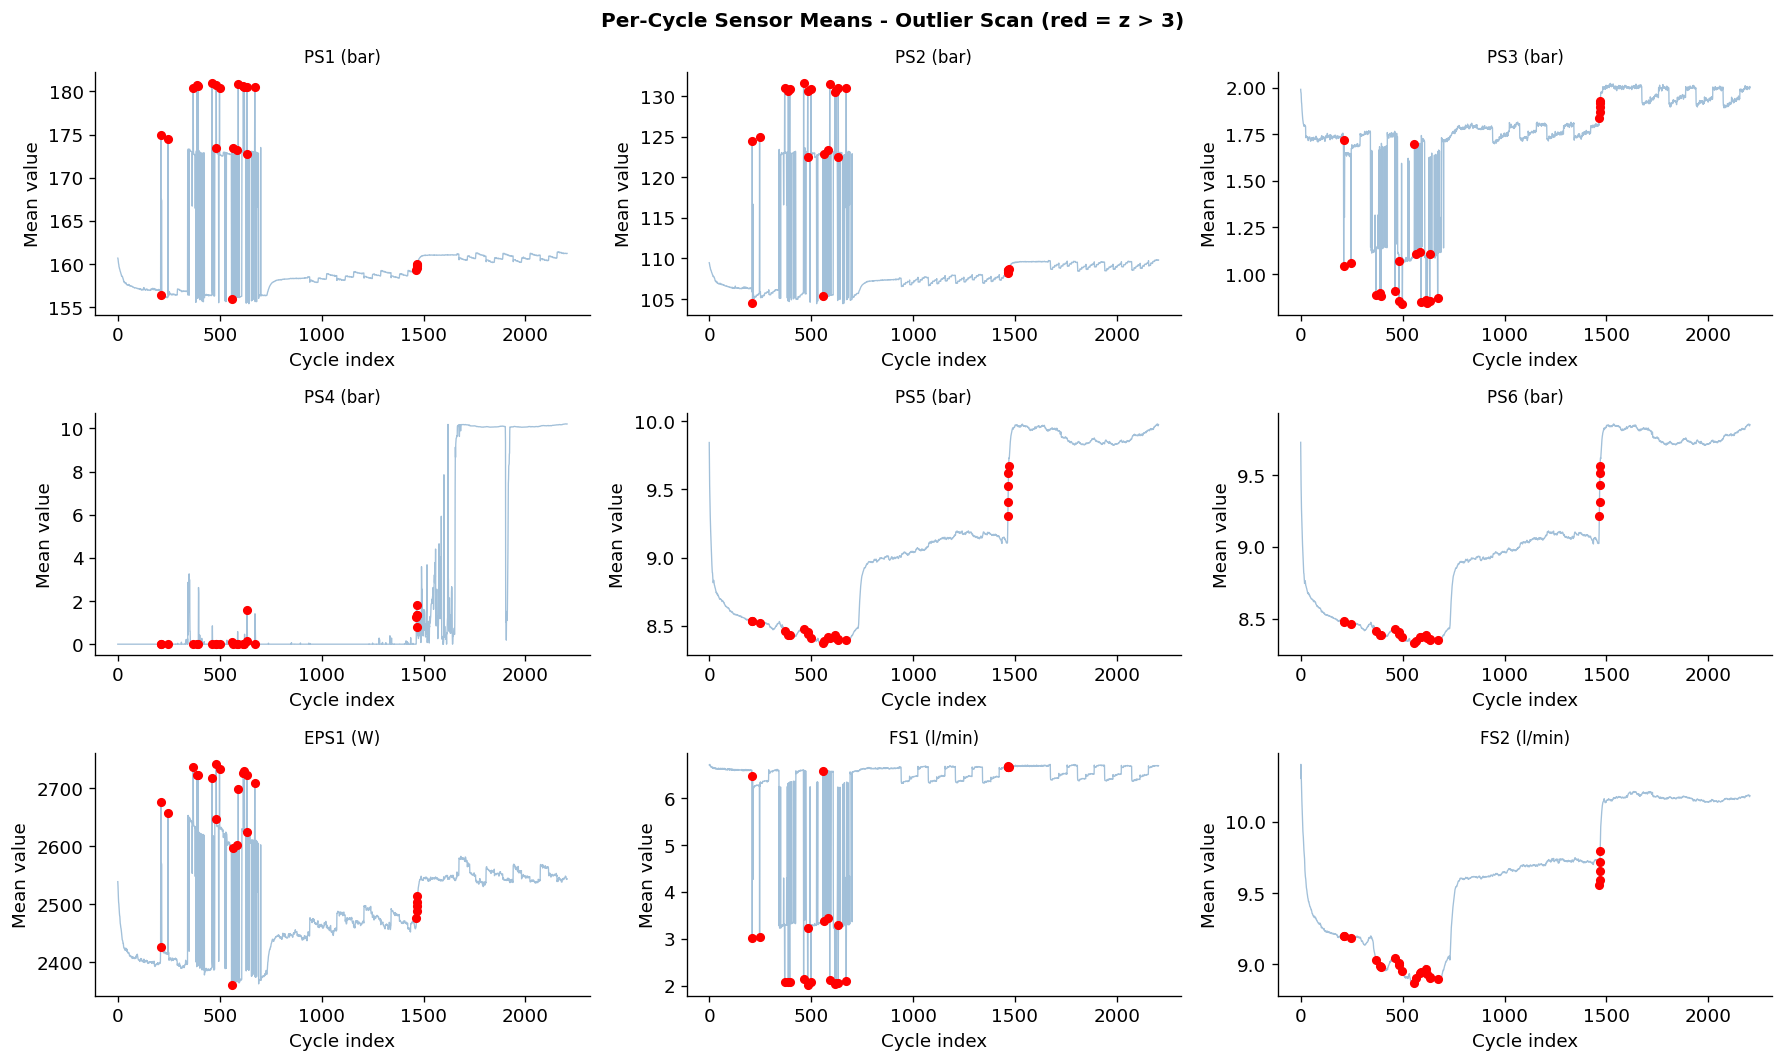

In [9]:
# 2.3  Outlier detection via z-score on per-cycle means

# Per-cycle means provide a compact representation per sensor. Cycles whose mean
# deviates more than 3 standard deviations are likely transient faults or sensor
# glitches worth investigating before modelling.

cycle_means  = pd.DataFrame({s: sensor_data[s].mean(axis=1) for s in sensor_data})
z_scores     = np.abs(stats.zscore(cycle_means))
outlier_mask = (z_scores > 3).any(axis=1)
print(f'  Cycles flagged as outliers (z > 3 on any sensor): '
      f'{outlier_mask.sum()} ({outlier_mask.sum()/n_cycles*100:.1f}%)')

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.flatten()
for i, sensor in enumerate(list(sensor_data.keys())[:9]):
    axes[i].plot(cycle_means[sensor], alpha=0.5, lw=0.8, color='steelblue')
    if outlier_mask.sum() > 0:
        axes[i].scatter(cycle_means[sensor][outlier_mask].index,
                        cycle_means[sensor][outlier_mask],
                        color='red', s=20, zorder=5, label='Outlier')
    axes[i].set_title(f'{sensor} ({SENSORS[sensor]["unit"]})', fontsize=10)
    axes[i].set_xlabel('Cycle index')
    axes[i].set_ylabel('Mean value')
plt.suptitle('Per-Cycle Sensor Means - Outlier Scan (red = z > 3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'PerCycle_Sensor_Means.png'), bbox_inches='tight')
plt.show()

Outliers detected correspond to known fault transition cycles, not data collection errors. All 2,205 cycles retained - no data removed.


  Health conditions during 24 outlier cycles:


   Cooler
Near failure (3%)    19
Full (100%)           5


   Valve
Optimal (100%)        9
Near failure (73%)    7
Small lag (90%)       6
Severe lag (80%)      2


   Pump
Severe leakage    11
No leakage        10
Weak leakage       3


   Accumulator
Near failure (90 bar)    10
Severe (100 bar)          7
Slight (115 bar)          4
Optimal (130 bar)         3


   Stable_Flag
Unstable    18
Stable       6


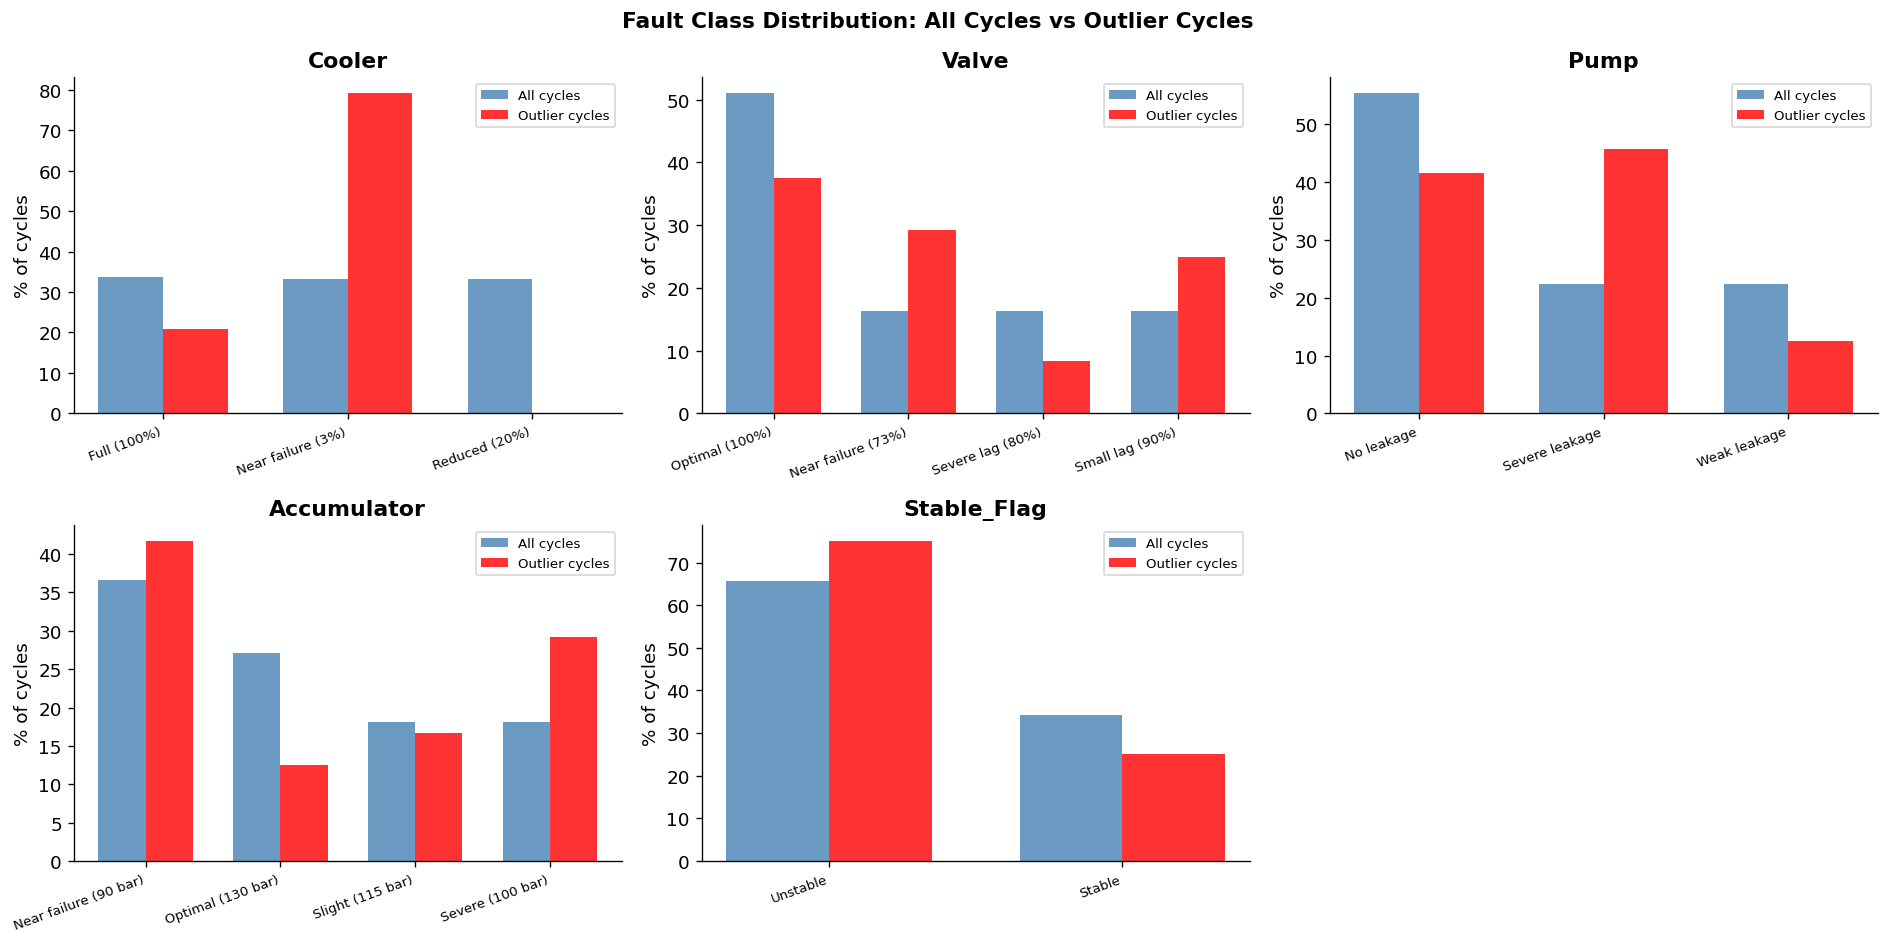

In [10]:
# Outlier fault context

outlier_indices = cycle_means[outlier_mask].index.tolist()
if outlier_indices:
    outlier_labels = profile.loc[outlier_indices]
    print(f'\n  Health conditions during {len(outlier_indices)} outlier cycles:')
    for col in TARGET_COLS:
        print(f'\n')
        print('  ', outlier_labels[col].map(LABEL_MAPS[col]).value_counts().to_string())

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for i, (col, lmap) in enumerate(LABEL_MAPS.items()):
        all_counts     = profile[col].map(lmap).value_counts(normalize=True) * 100
        outlier_counts = outlier_labels[col].map(lmap).value_counts(normalize=True) * 100
        x     = range(len(all_counts))
        width = 0.35
        lbls  = all_counts.index.tolist()
        axes[i].bar([p - width/2 for p in x], all_counts[lbls],
                    width=width, label='All cycles', color='steelblue', alpha=0.8)
        axes[i].bar([p + width/2 for p in x],
                    [outlier_counts.get(l, 0) for l in lbls],
                    width=width, label='Outlier cycles', color='red', alpha=0.8)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_ylabel('% of cycles')
        axes[i].set_xticks(list(x))
        axes[i].set_xticklabels(lbls, rotation=20, ha='right', fontsize=8)
        axes[i].legend(fontsize=8)
    axes[-1].set_visible(False)
    plt.suptitle('Fault Class Distribution: All Cycles vs Outlier Cycles',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# **Section 3 - TARGET VARIABLE ANALYSIS**

### **3.1.  Class distribution**

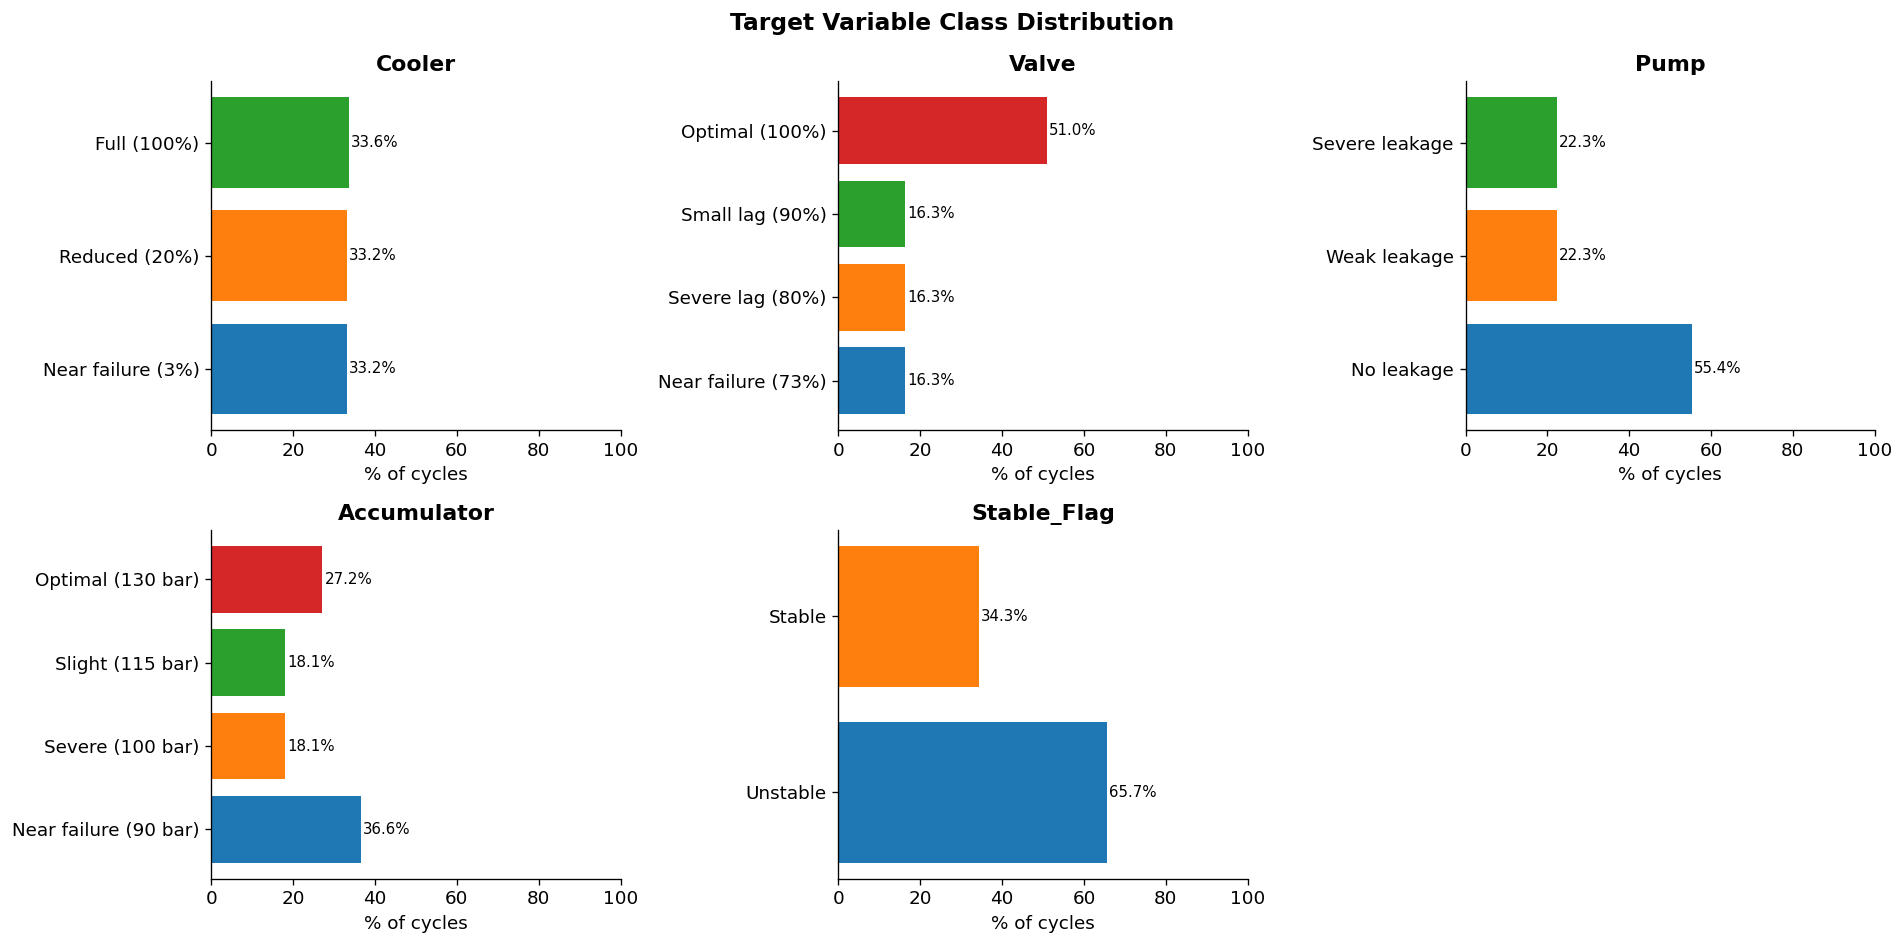


  Raw counts:

  Cooler:
    Near failure (3%): 732 (33.2%)
    Reduced (20%): 732 (33.2%)
    Full (100%): 741 (33.6%)

  Valve:
    Near failure (73%): 360 (16.3%)
    Severe lag (80%): 360 (16.3%)
    Small lag (90%): 360 (16.3%)
    Optimal (100%): 1125 (51.0%)

  Pump:
    No leakage: 1221 (55.4%)
    Weak leakage: 492 (22.3%)
    Severe leakage: 492 (22.3%)

  Accumulator:
    Near failure (90 bar): 808 (36.6%)
    Severe (100 bar): 399 (18.1%)
    Slight (115 bar): 399 (18.1%)
    Optimal (130 bar): 599 (27.2%)

  Stable_Flag:
    Unstable: 1449 (65.7%)
    Stable: 756 (34.3%)


In [11]:
# Valve condition is notably imbalanced: 51% Optimal vs 16% in each fault class.
# This will require compensating strategies during modelling

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (col, lmap) in enumerate(LABEL_MAPS.items()):
    counts     = profile[col].value_counts().sort_index()
    labels_txt = [lmap.get(k, str(k)) for k in counts.index]
    pcts       = counts.values / counts.sum() * 100
    bars       = axes[i].barh(labels_txt, pcts, color=sns.color_palette('tab10', len(counts)))
    for bar, pct in zip(bars, pcts):
        axes[i].text(pct + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{pct:.1f}%', va='center', fontsize=9)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('% of cycles')
    axes[i].set_xlim(0, 100)
axes[-1].set_visible(False)
plt.suptitle('Target Variable Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Target_Variable_Class_Distribution.png'), bbox_inches='tight')
plt.show()

print('\n  Raw counts:')
for col, lmap in LABEL_MAPS.items():
    print(f'\n  {col}:')
    for v, c in profile[col].value_counts().sort_index().items():
        print(f'    {lmap.get(v,v)}: {c} ({c/n_cycles*100:.1f}%)')

### **3.2.  Label distribution over time**

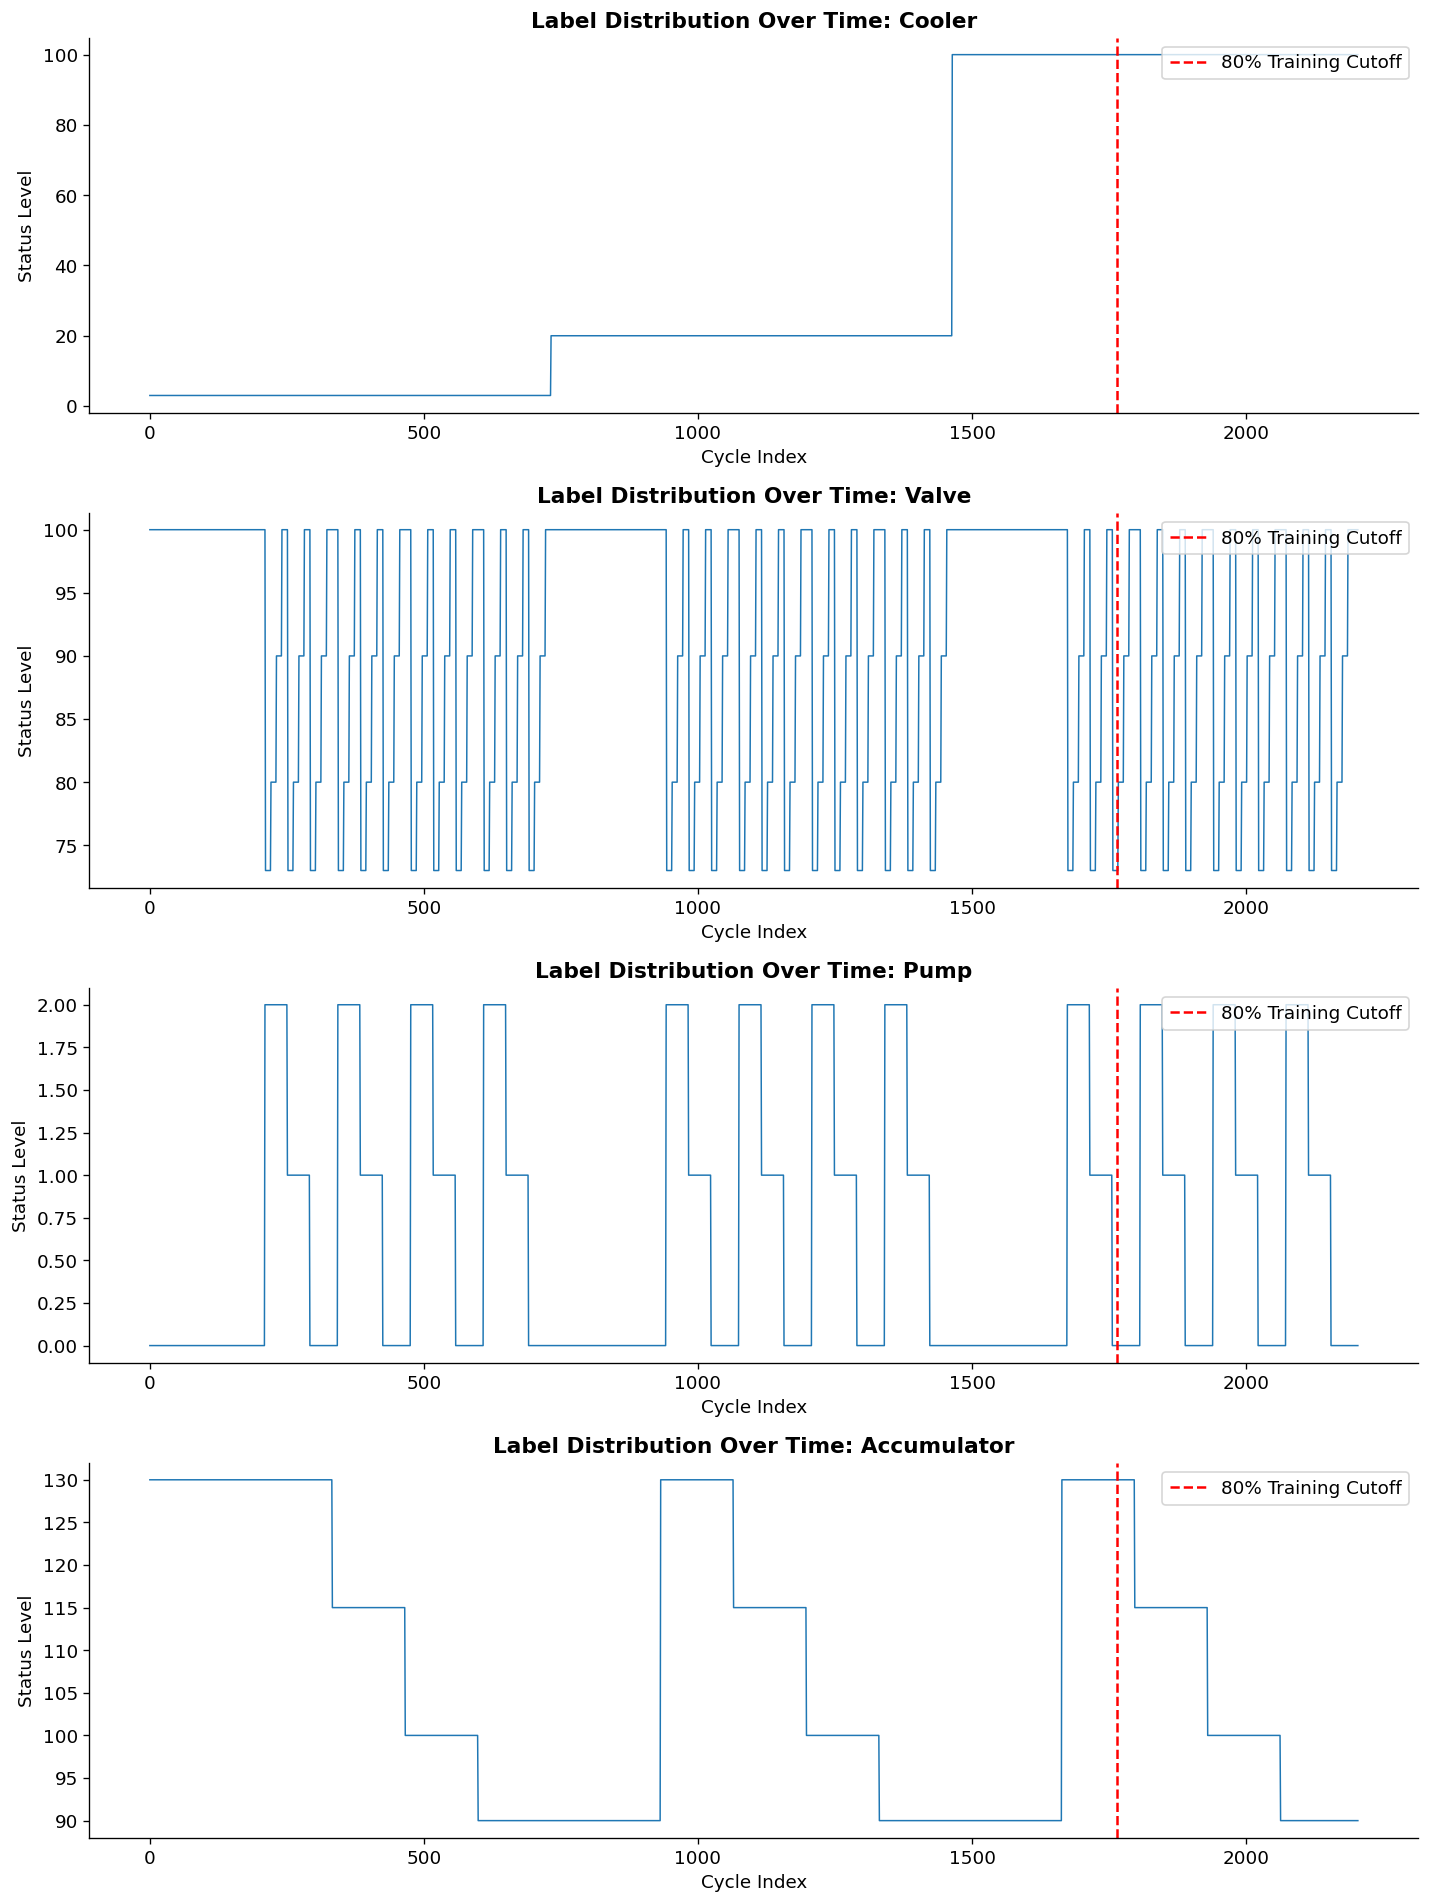

In [12]:
# The dataset is constructed by deliberately varying fault conditions.  The
# step-like pattern confirms labels are not continuous degradation signals but
# controlled experimental states - important context for model evaluation.

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for i, col in enumerate(FAULT_TARGETS):
    axes[i].plot(profile[col].values, color='tab:blue', lw=0.9)
    axes[i].set_title(f'Label Distribution Over Time: {col}',
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Status Level')
    axes[i].set_xlabel('Cycle Index')
    split_line = len(profile) * 0.8
    axes[i].axvline(x=split_line, color='red', linestyle='--',
                    label='80% Training Cutoff')
    axes[i].legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Label_Distribution_Over_Time.png'), bbox_inches='tight')
plt.show()

### **3.3.  Temporal train/test exposure analysis**

In [13]:
# Checks whether all fault states are adequately represented in a naive 80/20 temporal split.
# Under-represented states in training increase the risk of models that cannot generalise to unseen fault conditions.

print('\n  Temporal Train/Test Exposure Analysis (80/20 split):')
for col in FAULT_TARGETS:
    y_series  = profile[col]
    split_idx = int(len(y_series) * 0.8)
    y_train   = y_series.iloc[:split_idx]
    y_test    = y_series.iloc[split_idx:]
    train_dist = y_train.value_counts(normalize=True).sort_index() * 100
    test_dist  = y_test.value_counts(normalize=True).sort_index() * 100
    print(f'\n  [{col}]')
    lmap = LABEL_MAPS[col]
    for state in sorted(y_series.unique()):
        train_pct = train_dist.get(state, 0)
        test_pct  = test_dist.get(state, 0)
        ratio     = train_pct / (test_pct + 1e-9)
        flag      = '  Under-represented in train!' if ratio < 0.3 and test_pct > 0 else ''
        print(f'    {lmap.get(state, state)}: train={train_pct:.1f}%  '
              f'test={test_pct:.1f}%  ratio={ratio:.2f}{flag}')


  Temporal Train/Test Exposure Analysis (80/20 split):

  [Cooler]
    Near failure (3%): train=41.5%  test=0.0%  ratio=41496598639.46
    Reduced (20%): train=41.5%  test=0.0%  ratio=41496598639.46
    Full (100%): train=17.0%  test=100.0%  ratio=0.17  Under-represented in train!

  [Valve]
    Near failure (73%): train=15.1%  test=21.1%  ratio=0.72
    Severe lag (80%): train=14.7%  test=22.7%  ratio=0.65
    Small lag (90%): train=14.7%  test=22.7%  ratio=0.65
    Optimal (100%): train=55.4%  test=33.6%  ratio=1.65

  [Pump]
    No leakage: train=58.2%  test=44.2%  ratio=1.32
    Weak leakage: train=20.9%  test=27.9%  ratio=0.75
    Severe leakage: train=20.9%  test=27.9%  ratio=0.75

  [Accumulator]
    Near failure (90 bar): train=37.8%  test=32.2%  ratio=1.17
    Severe (100 bar): train=15.1%  test=30.2%  ratio=0.50
    Slight (115 bar): train=15.1%  test=30.2%  ratio=0.50
    Optimal (130 bar): train=32.1%  test=7.5%  ratio=4.29


### **3.4.  Target co-occurrence heatmaps**

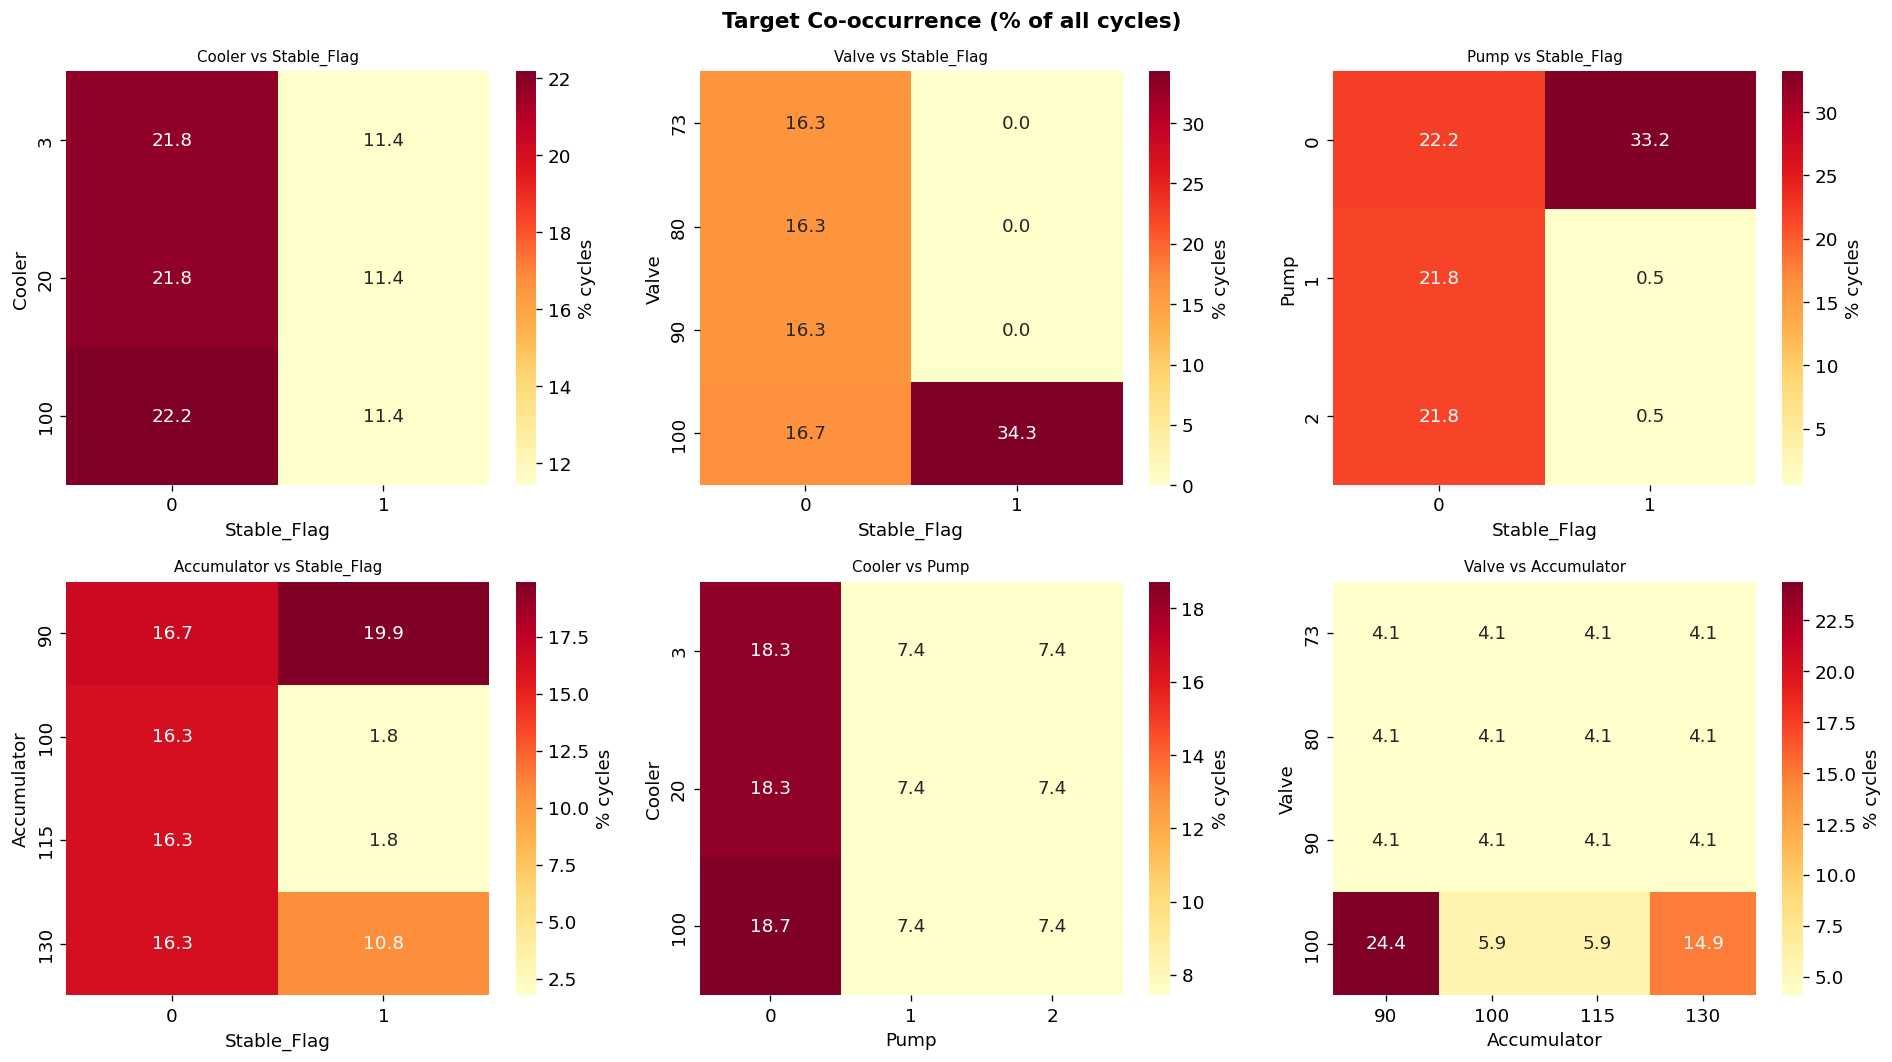

In [14]:
# Understanding which fault combinations occur together is critical:
# if Cooler failure and Pump leakage frequently co-occur, a model trained to predict onemay accidentally learn the other's signal.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
pairs = [
    ('Cooler', 'Stable_Flag'),   ('Valve',  'Stable_Flag'),
    ('Pump',   'Stable_Flag'),   ('Accumulator', 'Stable_Flag'),
    ('Cooler', 'Pump'),     ('Valve',  'Accumulator'),
]
for i, (t1, t2) in enumerate(pairs):
    ct = pd.crosstab(profile[t1], profile[t2], normalize='all') * 100
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[i],
                cbar_kws={'label': '% cycles'})
    axes[i].set_title(f'{t1} vs {t2}', fontsize=9)
plt.suptitle('Target Co-occurrence (% of all cycles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Target_Co-occurrence.png'), bbox_inches='tight')
plt.show()

Target co-occurrence analysis confirms fault conditions are deliberately varied independently across cycles - supporting the use of separate target-specific models rather than a single multi-output classifier.

# **Section 4 - SENSOR SIGNAL VISUALISATION**

### **4.1.  Raw waveforms by health condition**

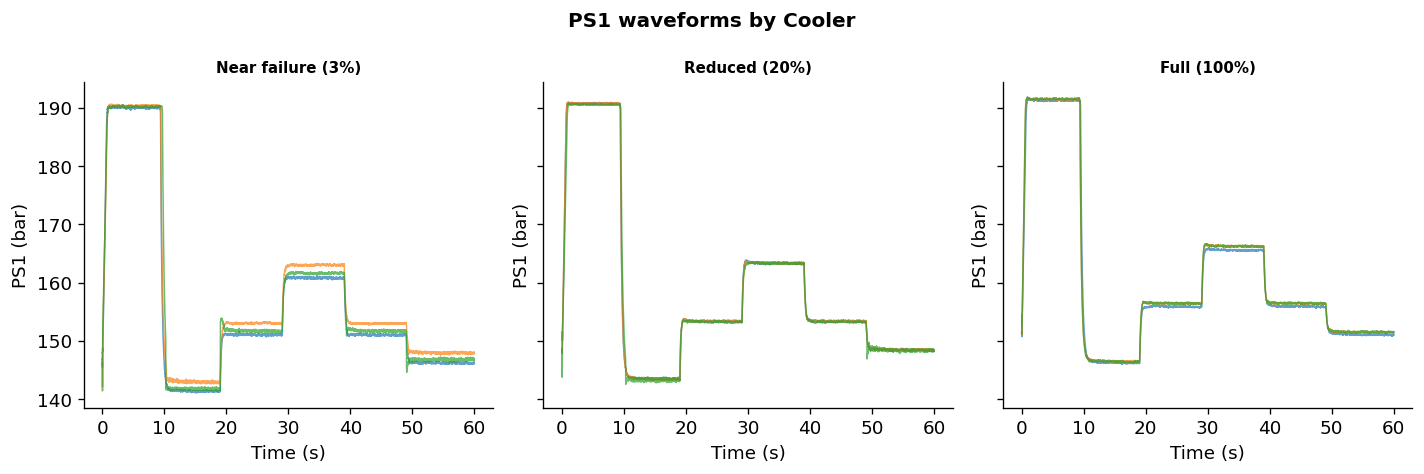

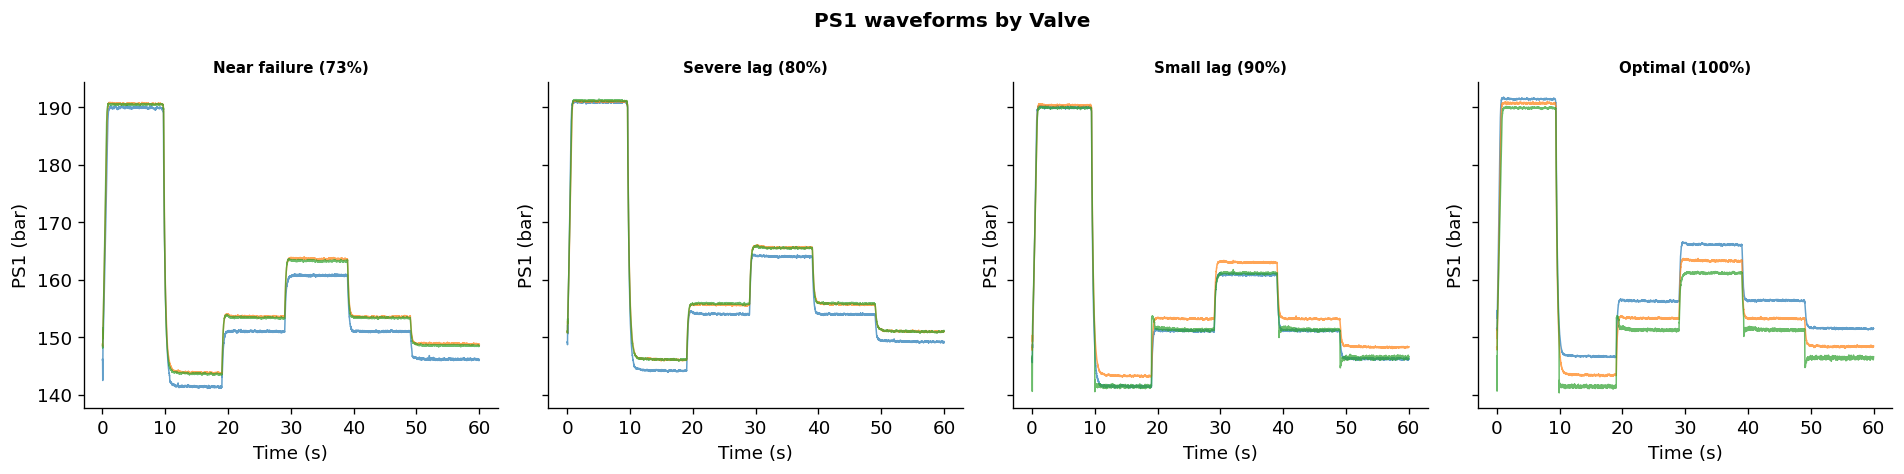

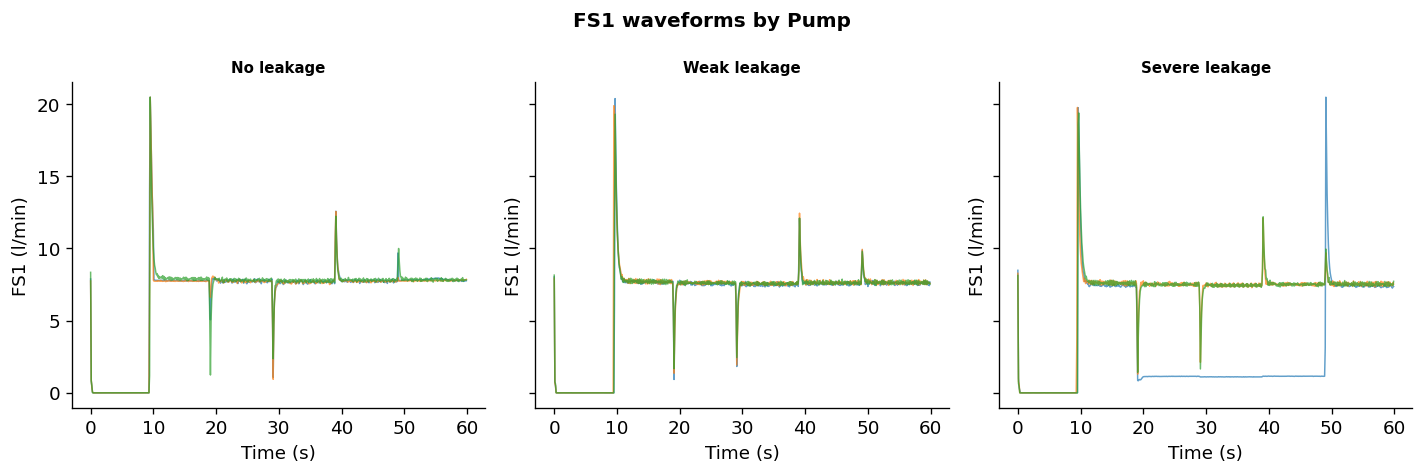

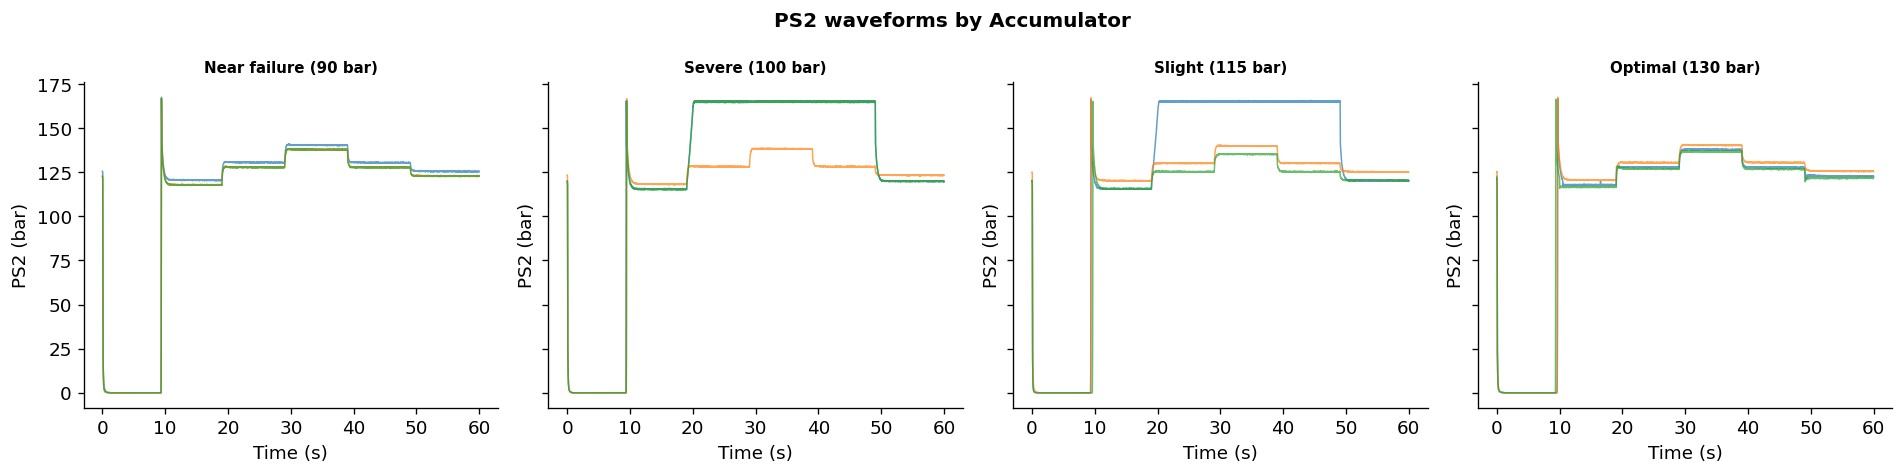

In [15]:
def plot_waveforms_by_condition(sensor_name, target_col, label_map, n_samples=3):
    df         = sensor_data[sensor_name]
    hz         = SENSORS[sensor_name]['hz']
    t          = np.arange(df.shape[1]) / hz
    conditions = sorted(profile[target_col].unique())
    fig, axes  = plt.subplots(1, len(conditions),
                               figsize=(4*len(conditions), 4), sharey=True)
    if len(conditions) == 1:
        axes = [axes]
    palette = sns.color_palette('tab10', n_samples)
    for ax, cond in zip(axes, conditions):
        idx    = profile[profile[target_col] == cond].index
        sample = np.random.choice(idx, min(n_samples, len(idx)), replace=False)
        for j, si in enumerate(sample):
            ax.plot(t, df.iloc[si].values, alpha=0.7, lw=0.9, color=palette[j])
        ax.set_title(label_map.get(cond, str(cond)), fontsize=9, fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(f'{sensor_name} ({SENSORS[sensor_name]["unit"]})')
    fig.suptitle(f'{sensor_name} waveforms by {target_col}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'Waveforms_by_Target.png'), bbox_inches='tight')
    plt.show()

np.random.seed(42)
plot_waveforms_by_condition('PS1', 'Cooler',      LABEL_MAPS['Cooler'])
plot_waveforms_by_condition('PS1', 'Valve',       LABEL_MAPS['Valve'])
plot_waveforms_by_condition('FS1', 'Pump',        LABEL_MAPS['Pump'])
plot_waveforms_by_condition('PS2', 'Accumulator', LABEL_MAPS['Accumulator'])

### **4.2.  Violin plots - cycle mean by condition**

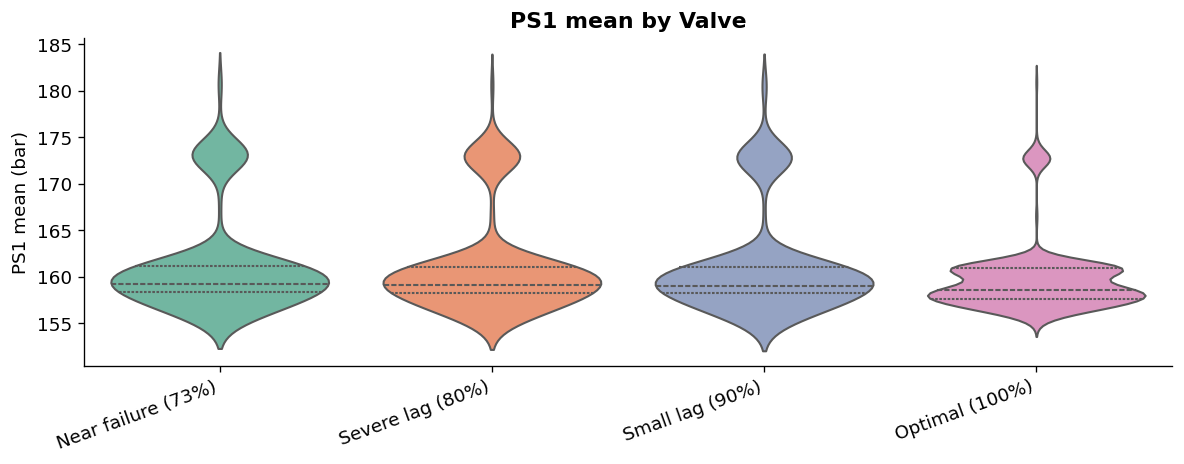

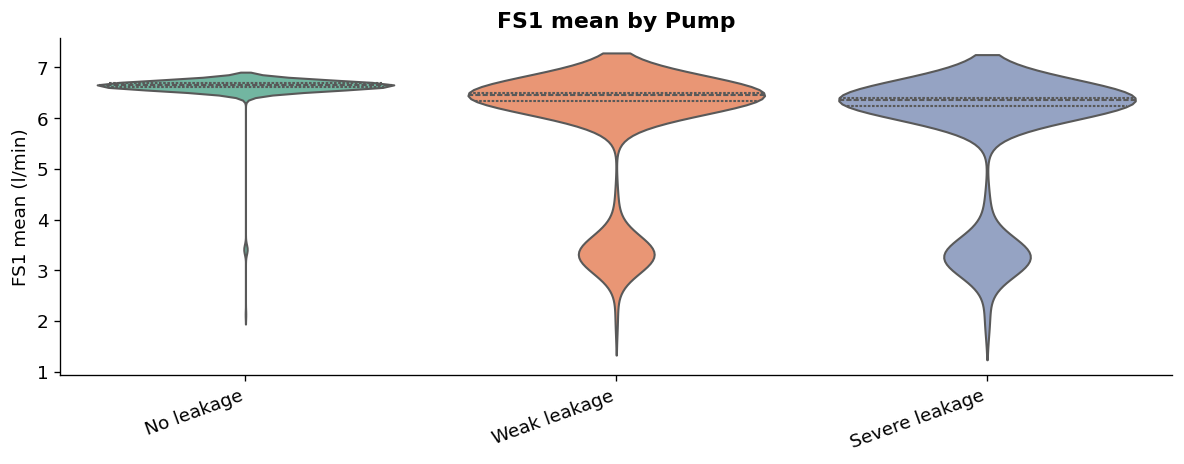

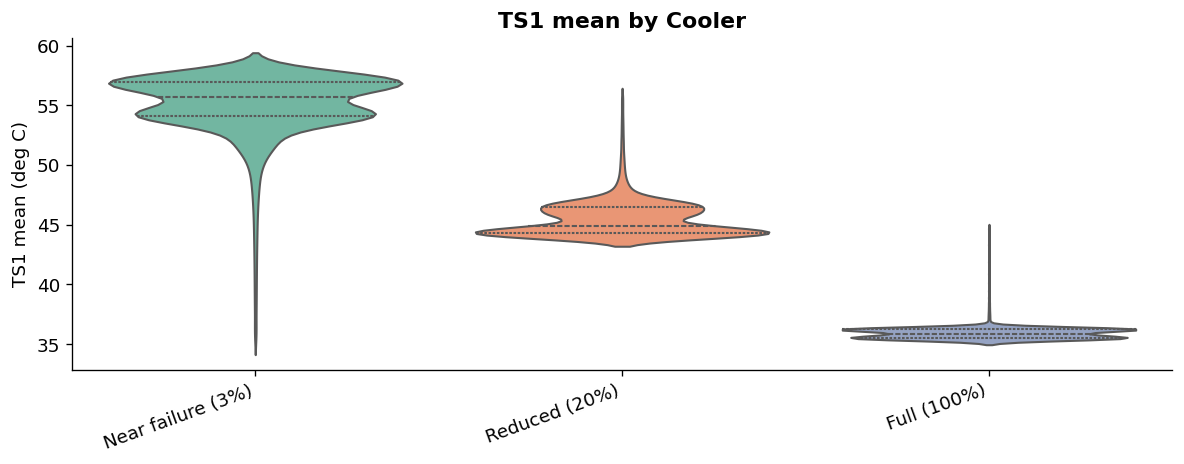

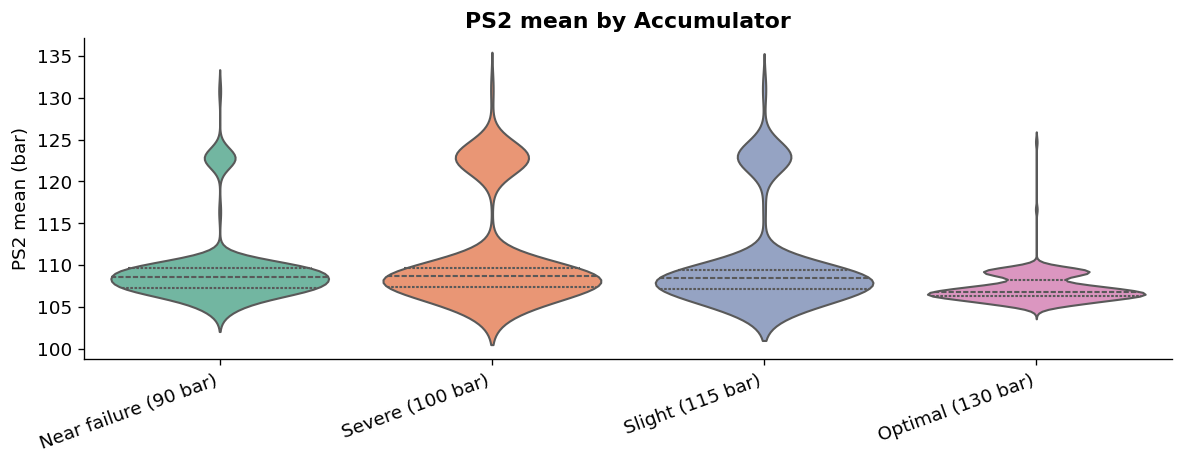

In [16]:
cycle_means_df = pd.DataFrame({s: sensor_data[s].mean(axis=1) for s in sensor_data})

def violin_by_condition(sensor_name, stat_series, target_col, label_map):
    plot_df = pd.DataFrame({
        'value':     stat_series,
        'condition': profile[target_col].map(label_map)
    })
    order  = [label_map[k] for k in sorted(label_map.keys())]
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.violinplot(data=plot_df, x='condition', y='value', order=order,
                   palette='Set2', inner='quartile', ax=ax)
    ax.set_title(f'{sensor_name} mean by {target_col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(f'{sensor_name} mean ({SENSORS[sensor_name]["unit"]})')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'Violin_by_Target.png'), bbox_inches='tight')
    plt.show()

violin_by_condition('PS1', cycle_means_df['PS1'], 'Valve',       LABEL_MAPS['Valve'])
violin_by_condition('FS1', cycle_means_df['FS1'], 'Pump',        LABEL_MAPS['Pump'])
violin_by_condition('TS1', cycle_means_df['TS1'], 'Cooler',      LABEL_MAPS['Cooler'])
violin_by_condition('PS2', cycle_means_df['PS2'], 'Accumulator', LABEL_MAPS['Accumulator'])


### **4.3. Full sensor mean trend scan**

In [17]:
# 4.3  Full sensor mean trend scan (plotted after feature engineering)
def plot_sensor_trend_scan(scaled_full_df, sensor_names, output_path=None):
    fig_f, axes_f = plt.subplots(6, 3, figsize=(18, 22))
    axes_f = axes_f.flatten()
    for i, name in enumerate(sensor_names):
        feat_name = f'{name}_mean'
        ax = axes_f[i]
        ax.plot(scaled_full_df.index, scaled_full_df[feat_name],
                color='steelblue', lw=1, alpha=0.8)
        ax.set_title(f'{name} Mean Trend', fontsize=11, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
    plt.suptitle('Full Sensor Mean Trend Scan (2205 Cycles)', fontsize=22, y=1.02)
    plt.tight_layout()
    if output_path:
        plt.savefig(os.path.join(output_path, 'Sensor_Mean_Trends.png'),
                    bbox_inches='tight')
    plt.show()

# **Section 5 - FEATURE ENGINEERING**

### Feature engineering rationale
   | Feature group                     | Paper source                          |
   |-----------------------------------|---------------------------------------|
   | Mean, std, skewness, kurtosis     | Schneider et al. (2018); Alenany (2021)|
   | Slope of linear fit, max position | Helwig et al. (2015); Schneider (2018) |
   | FFT frequency power (0.5-5 Hz)    | Schneider et al. (2018) BFC method    |
   | Windowed means (3 × 20 s windows) | Schneider et al. (2018) ALA method    |
   | Derived: dP, dT, Hyd_Power        | Tao et al. (2024) domain features     |

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf, adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from scipy.fft import rfft, rfftfreq

## **5.1. Data Resampling**

In [19]:
#loading data and resample
def load_and_resample_hydraulic_data(data_path, cycle_len_sec=60, target_hz=100):
    """
    Loads sensor data and resamples all sensors to a uniform frequency (target_hz)
    using linear interpolation to ensure temporal alignment.
    """
    print("--- Loading and Resampling Sensor Data ---")
    target_samples = cycle_len_sec * target_hz  # 6000 samples per cycle
    sensors = {
        'PS1': 100, 'PS2': 100, 'PS3': 100, 'PS4': 100, 'PS5': 100, 'PS6': 100, 'EPS1': 100,
        'FS1': 10,  'FS2': 10,
        'TS1': 1,   'TS2': 1,   'TS3': 1,   'TS4': 1,
        'VS1': 1,   'CE': 1,    'CP': 1,    'SE': 1
    }

    all_data = {}
    for sensor, native_hz in sensors.items():
        file_path = os.path.join(data_path, f"{sensor}.txt")
        df_raw = pd.read_csv(file_path, sep='\t', header=None)

        if native_hz == target_hz:
            resampled = df_raw.values
        else:
            native_samples = df_raw.shape[1]
            x_old = np.linspace(0, cycle_len_sec, native_samples)
            x_new = np.linspace(0, cycle_len_sec, target_samples)
            # Apply linear interpolation across all rows
            resampled = np.array([np.interp(x_new, x_old, row) for row in df_raw.values])

        all_data[sensor] = resampled
        print(f"  └─ Sensor {sensor} Ready. Shape: {resampled.shape}")

    return all_data

all_data = load_and_resample_hydraulic_data(DATA_PATH)

--- Loading and Resampling Sensor Data ---
  └─ Sensor PS1 Ready. Shape: (2205, 6000)
  └─ Sensor PS2 Ready. Shape: (2205, 6000)
  └─ Sensor PS3 Ready. Shape: (2205, 6000)
  └─ Sensor PS4 Ready. Shape: (2205, 6000)
  └─ Sensor PS5 Ready. Shape: (2205, 6000)
  └─ Sensor PS6 Ready. Shape: (2205, 6000)
  └─ Sensor EPS1 Ready. Shape: (2205, 6000)
  └─ Sensor FS1 Ready. Shape: (2205, 6000)
  └─ Sensor FS2 Ready. Shape: (2205, 6000)
  └─ Sensor TS1 Ready. Shape: (2205, 6000)
  └─ Sensor TS2 Ready. Shape: (2205, 6000)
  └─ Sensor TS3 Ready. Shape: (2205, 6000)
  └─ Sensor TS4 Ready. Shape: (2205, 6000)
  └─ Sensor VS1 Ready. Shape: (2205, 6000)
  └─ Sensor CE Ready. Shape: (2205, 6000)
  └─ Sensor CP Ready. Shape: (2205, 6000)
  └─ Sensor SE Ready. Shape: (2205, 6000)


In [20]:
def load_labels(data_path):
    """
    Loads the system status labels from profile.txt and assigns physical names to columns.
    """
    print("--- Loading System Status Labels (profile.txt) ---")
    profile_path = os.path.join(data_path, 'profile.txt')
    labels = pd.read_csv(profile_path, sep='\t', header=None)
    labels.columns = ['Cooler', 'Valve', 'Pump', 'Accumulator', 'Stable_Flag']
    print(f"  └─ Labels Ready. Shape: {labels.shape}")
    return labels
labels = load_labels(DATA_PATH)

--- Loading System Status Labels (profile.txt) ---
  └─ Labels Ready. Shape: (2205, 5)


## **5.2. Target Evolution & Split Point Identification**

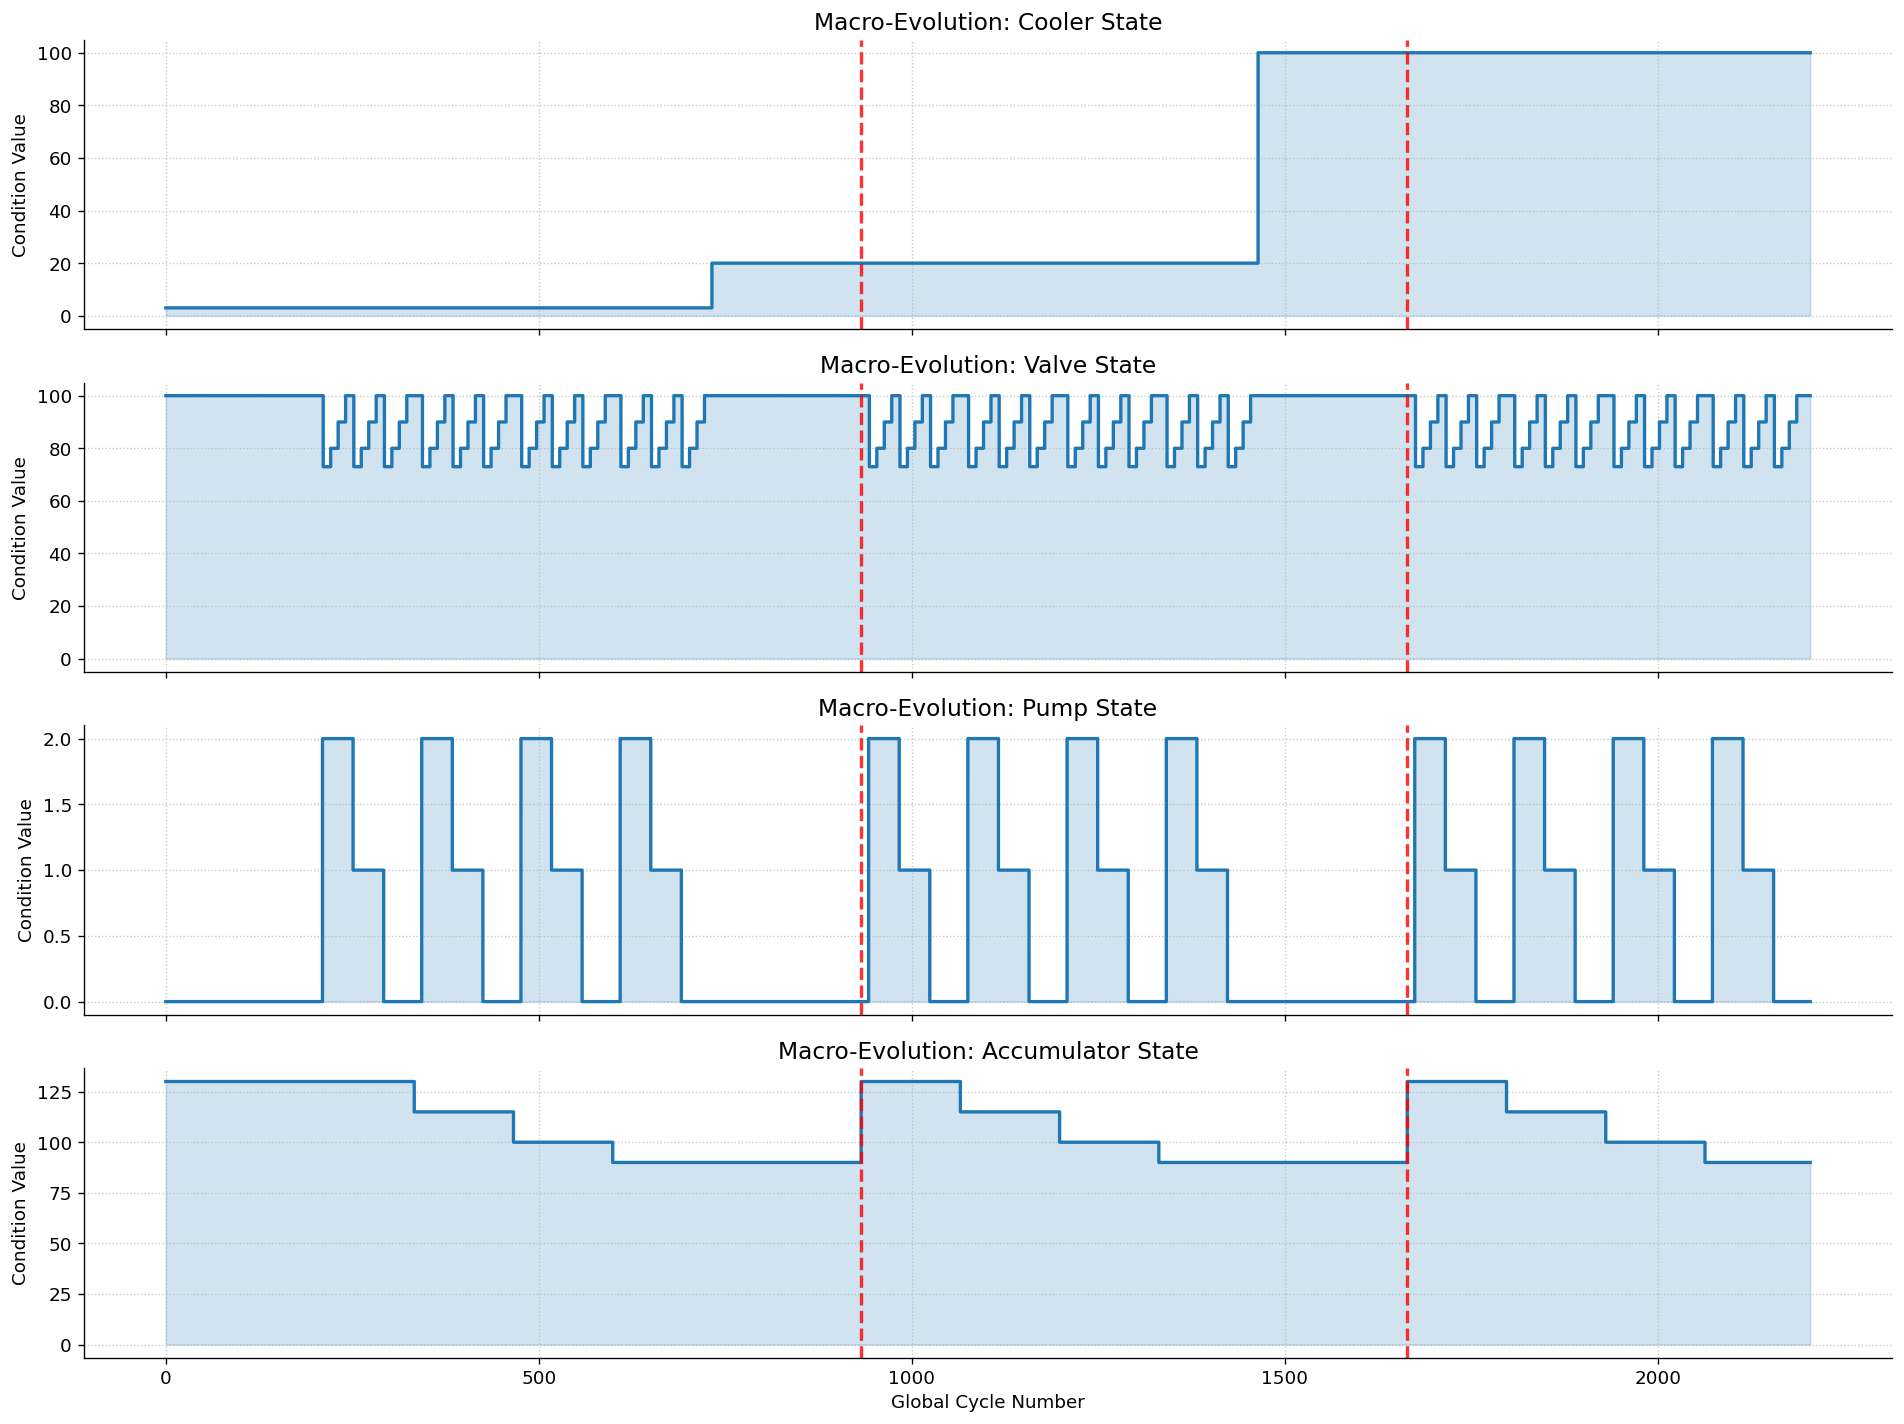

In [21]:
def plot_meta_eda_target_evolution(labels_df, target_cols=['Cooler', 'Valve', 'Pump', 'Accumulator']):
    """
    Visualizes the long-term degradation and experimental progression of the system.
    """
    fig, axes = plt.subplots(len(target_cols), 1, figsize=(16, 12), sharex=True)
    acc_diff = labels_df['Accumulator'].diff()
    reset_points = acc_diff[acc_diff > 10].index.tolist()

    for i, target in enumerate(target_cols):
        ax = axes[i]
        ax.plot(labels_df.index, labels_df[target], label=f'{target} State',
                color='tab:blue', linewidth=2, drawstyle='steps-post')
        ax.fill_between(labels_df.index, labels_df[target], alpha=0.2, color='tab:blue')
        for rp in reset_points:
            ax.axvline(x=rp, color='red', linestyle='--', alpha=0.8, linewidth=2)
        ax.set_title(f"Macro-Evolution: {target} State", fontsize=14)
        ax.set_ylabel("Condition Value")
        ax.grid(True, linestyle=':', alpha=0.7)

    plt.xlabel("Global Cycle Number")
    plt.tight_layout()
    plt.show()
plot_meta_eda_target_evolution(labels)

In [22]:
# optimal data split point

def meta_eda_and_find_split(labels_df, target_cols=['Cooler', 'Valve', 'Pump', 'Accumulator']):
    """
    Analyse target transition frequencies and identify the optimal global split point
    based on the last major reset event in the Accumulator target.
    """
    print("\n--- Stage 2: Global Meta-EDA & Split Identification ---")
    for col in ['Cooler', 'Valve', 'Pump', 'Accumulator']:
        changes = labels[col].diff().fillna(0)
        transition_indices = changes[changes != 0].index.tolist()
        print(f"  └─ [{col}] Transitions: {len(transition_indices)}")

        if len(transition_indices) < 10:
            print(f"      -> Macro Transition Points: {transition_indices}")

    acc_diff = labels['Accumulator'].diff()
    reset_points = acc_diff[acc_diff > 10].index.tolist()
    optimal_split_index = reset_points[-1]
    print(f"  └─ Locked Optimal Split Point: Cycle {optimal_split_index}")
    return optimal_split_index
optimal_split_index = meta_eda_and_find_split(labels)


--- Stage 2: Global Meta-EDA & Split Identification ---
  └─ [Cooler] Transitions: 2
      -> Macro Transition Points: [732, 1464]
  └─ [Valve] Transitions: 144
  └─ [Pump] Transitions: 36
  └─ [Accumulator] Transitions: 11
  └─ Locked Optimal Split Point: Cycle 1664


## **5.3. Feature Generation**

In [23]:
def generate_unified_features(all_resampled_data):
    """
    Engineers a comprehensive feature set using time, frequency, and physical domains.

    Operations:
    1. Synthesizes derived physical variables: system pressure drop, cooler pressure drop,
       cooler temperature difference, and primary-secondary pressure difference.
    2. Calculates instantaneous hydraulic power (Pressure * Flow).
    3. For every sensor (original and derived):
        a. Computes global time-domain statistics: mean, std, max, min, range, skewness, and kurtosis.
        b. Calculates the integral (energy) of the signal over the cycle.
        c. Computes the first-order derivative to find the maximum drop and recovery rates (transient capture).
        d. Segments each cycle into three windows (0-20s, 20-40s, 40-60s) and calculates windowed means.
        e. Performs Real Fast Fourier Transform (rfft) for high-frequency sensors.
        f. Extracts frequency power in the 0.5Hz to 5Hz range (bins 30-300).
    4. Computes a Pump Efficiency Proxy (Average Flow / Average Pressure).
    5. Concatenates all features into a single DataFrame and fills any NaN values with 0.
    """
    print("Generating unified feature engine...")
    all_resampled_data['dP_sys'] = all_resampled_data['PS1'] - all_resampled_data['PS2']
    all_resampled_data['dP_cooler'] = all_resampled_data['PS5'] - all_resampled_data['PS6']
    all_resampled_data['dT_cooler'] = all_resampled_data['TS3'] - all_resampled_data['TS4']
    all_resampled_data['dP_PS1_PS3'] = all_resampled_data['PS1'] - all_resampled_data['PS3']
    all_resampled_data['Hyd_Power'] = all_resampled_data['PS1'] * all_resampled_data['FS1']

    all_feats = []
    w1_end, w2_end = 2000, 4000

    for sensor, matrix in all_resampled_data.items():
        matrix_diff = np.diff(matrix, axis=1)
        df_temp = pd.DataFrame({
            f'{sensor}_mean': np.mean(matrix, axis=1),
            f'{sensor}_std':  np.std(matrix, axis=1),
            f'{sensor}_max':  np.max(matrix, axis=1),
            f'{sensor}_min':  np.min(matrix, axis=1),
            f'{sensor}_range': np.ptp(matrix, axis=1),
            f'{sensor}_skew': skew(matrix, axis=1, bias=False, nan_policy='omit'),
            f'{sensor}_kurtosis': kurtosis(matrix, axis=1, bias=False, nan_policy='omit'),
            f'{sensor}_energy': np.trapz(matrix, axis=1),
            f'{sensor}_max_drop_rate': np.min(matrix_diff, axis=1),
            f'{sensor}_max_recov_rate': np.max(matrix_diff, axis=1)
        })
        df_temp[f'{sensor}_w1_mean'] = np.mean(matrix[:, :w1_end], axis=1)
        df_temp[f'{sensor}_w2_mean'] = np.mean(matrix[:, w1_end:w2_end], axis=1)
        df_temp[f'{sensor}_w3_mean'] = np.mean(matrix[:, w2_end:], axis=1)

        if sensor.startswith(('PS', 'VS', 'EPS', 'dP', 'Hyd')):
            fft_vals = np.abs(rfft(matrix, axis=1))
            df_temp[f'{sensor}_freq_power'] = np.mean(fft_vals[:, 30:300], axis=1)

        all_feats.append(df_temp)

    features_df = pd.concat(all_feats, axis=1)
    features_df['Pump_Efficiency_Proxy'] = np.mean(all_resampled_data['FS1'], axis=1) / (np.mean(all_resampled_data['PS1'], axis=1) + 1e-6)
    features_df.fillna(0, inplace=True)
    return features_df

features_df = generate_unified_features(all_data)
extended_features = features_df.copy()
extended_features['label_Cooler'] = labels['Cooler']
extended_features['label_Valve'] = labels['Valve']
extended_features['label_Pump'] = labels['Pump']
extended_features['label_Accumulator'] = labels['Accumulator']

Generating unified feature engine...


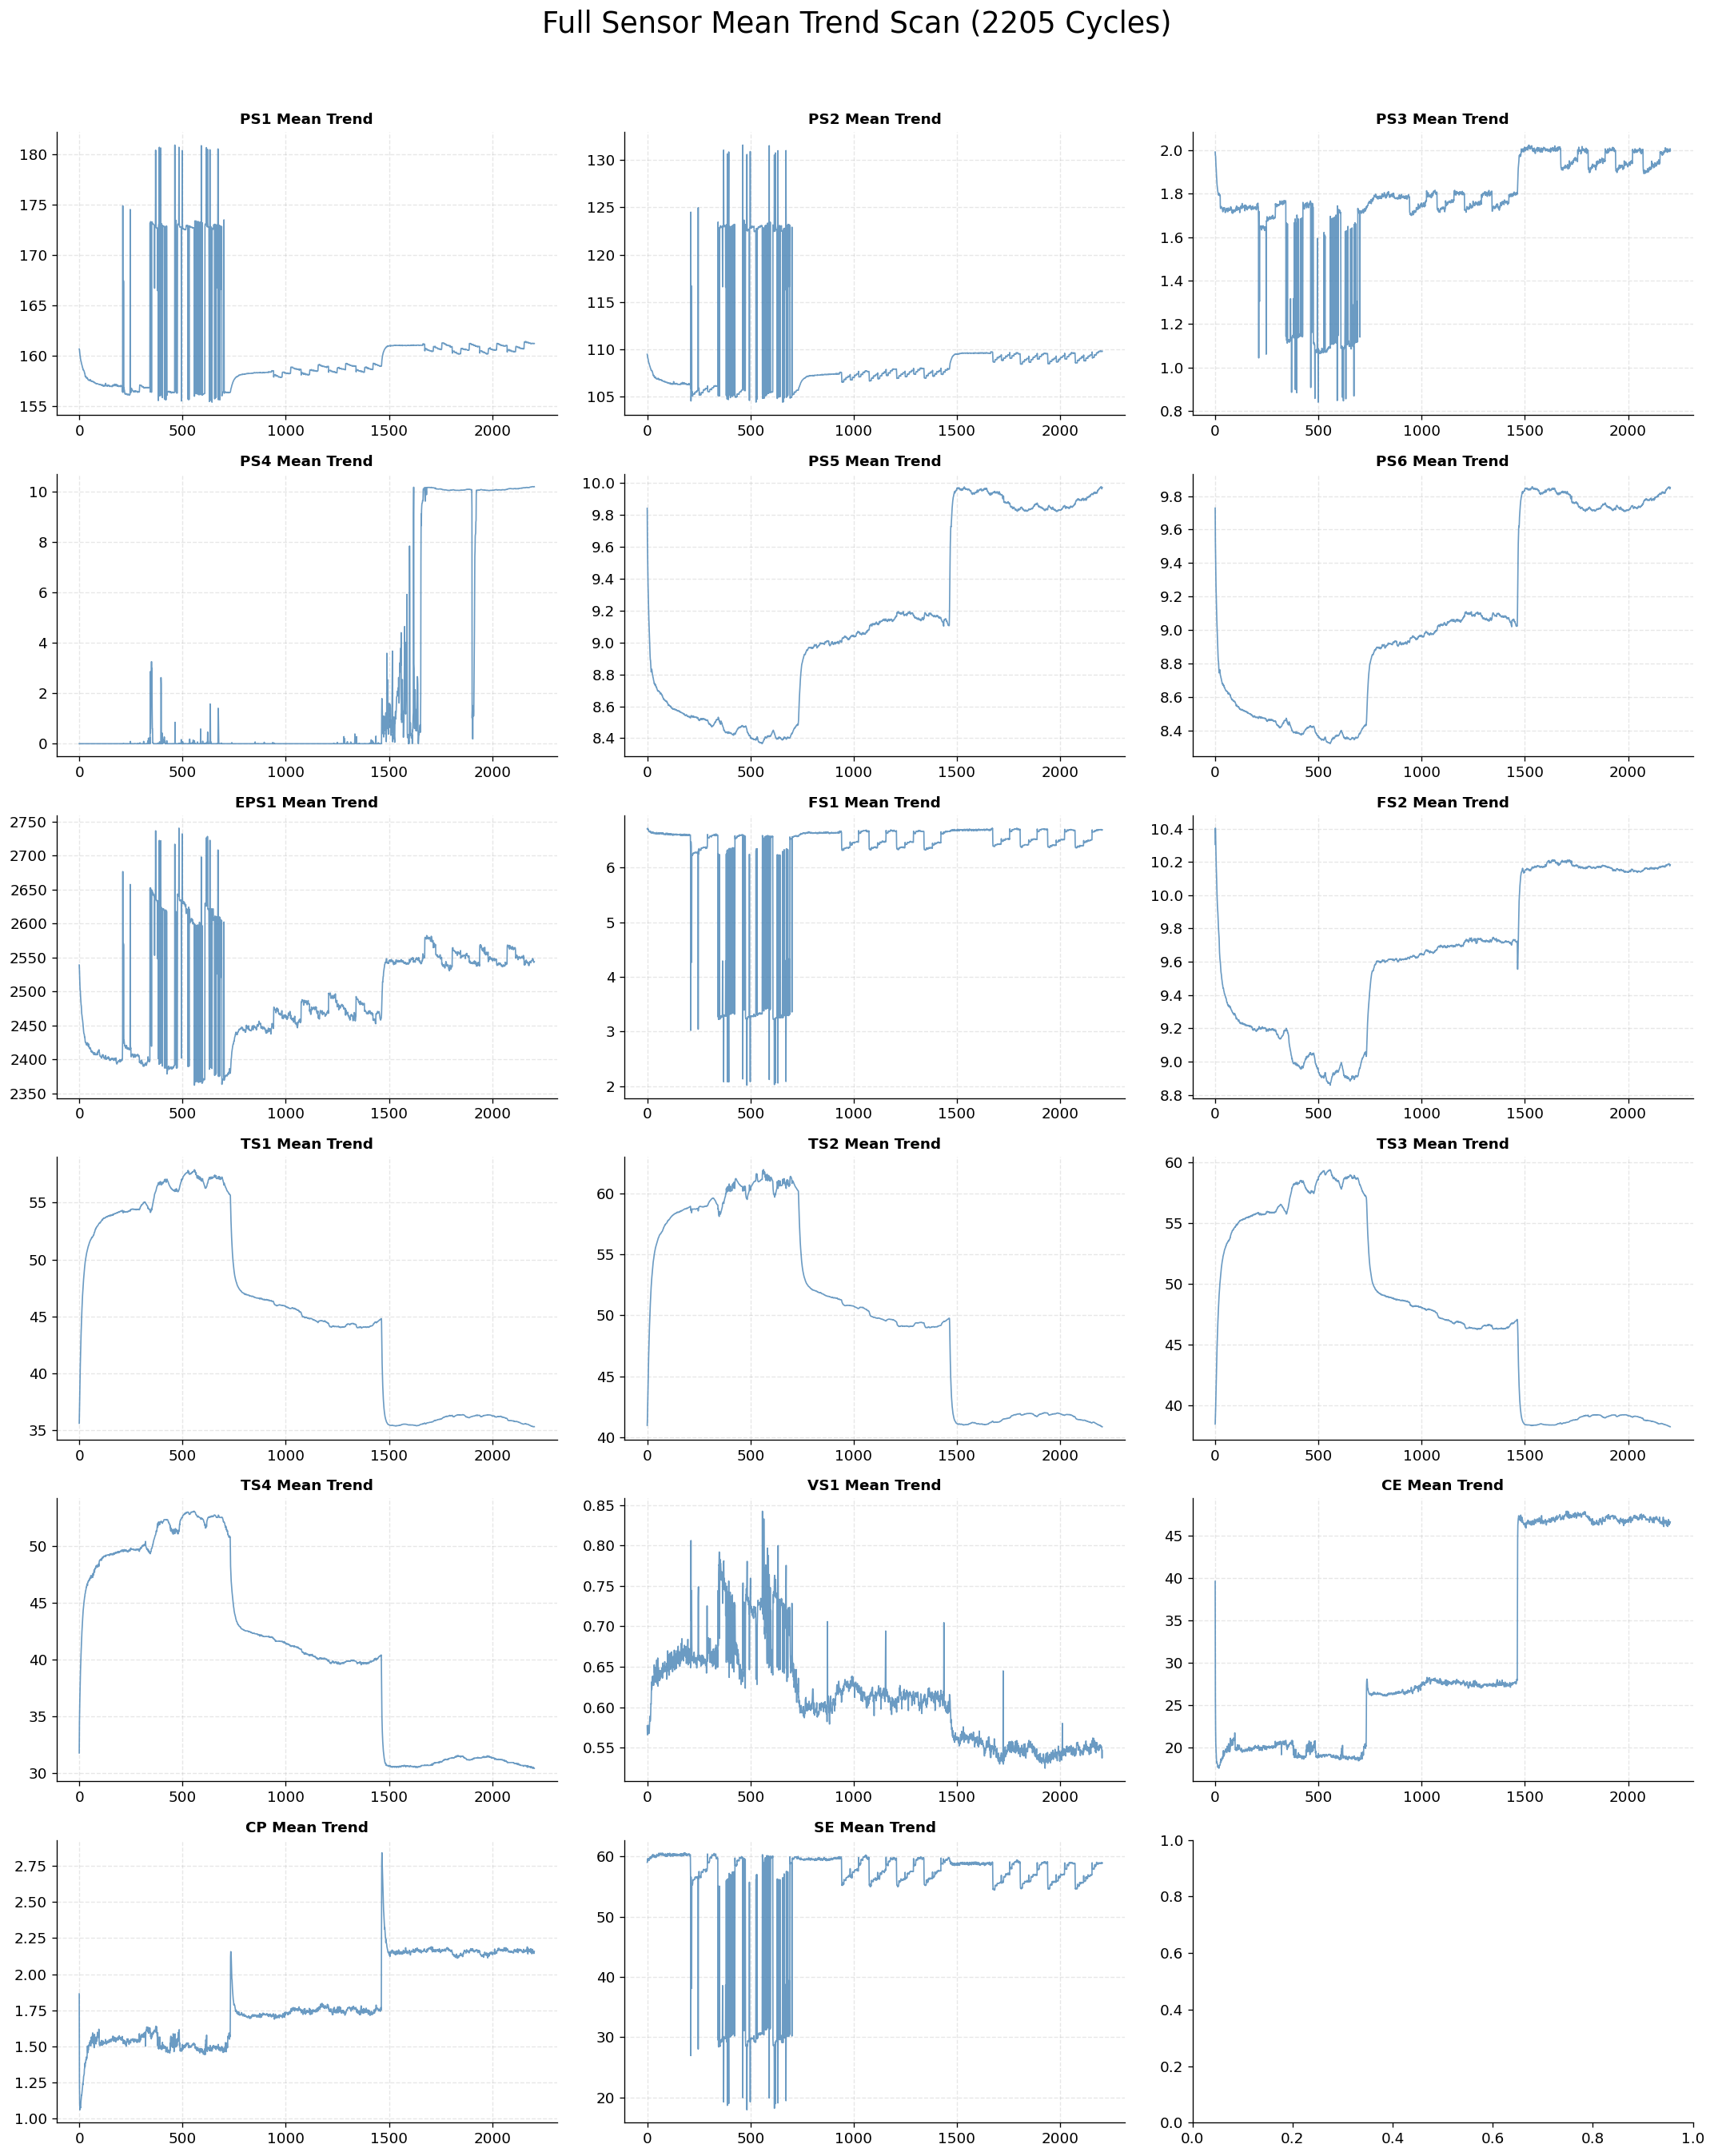

In [24]:
plot_sensor_trend_scan(
    features_df,
    list(SENSORS.keys()),
    output_path=OUTPUT_PATH
)

# **Section 6 - DATA PREPARATION: DUAL VALIDATION STRATEGY**

### Strategy 1 - Random stratified split (feature validation baseline)
**Purpose:** Validate that our feature engineering is meaningful.
If models trained on randomly shuffled data score poorly, our
features are uninformative. If they score well, we have good
signal - but the results are not deployment-trustworthy due to
temporal leakage (future fault states leak into training).

This is explicitly NOT used for final reported results. It serves
as a sanity check on feature engineering quality only.

### Strategy 2 - Block split at cycle 1664 (deployment simulation)
**Purpose:** Simulate the real industrial scenario where a model
is trained on historical data and deployed on future data it has
never seen. Cycle 1664 is the start of the last Accumulator
degradation cycle, which also aligns with the last cycle on the
time axis for all other targets - making it the only valid global
split point for this dataset.

This IS used for all reported performance figures.

**Why the difference matters:** Random splits typically inflate
accuracy by 5-8% compared to block splits because they allow
future fault-condition signals to appear in the training set
(Helwig et al., 2015; Chen et al., 2025). Reporting only random-
split results would give BAE Systems an unrealistically optimistic
picture of deployment performance.

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

### **Feature Selection Pipeline**

In [26]:
# Shared feature selection (used by both strategies)

def feature_selection_pipeline(X_train, y_train, X_test,
                                target_name, max_features=25,
                                plot=True):
    """
    Three-stage pipeline: variance filter → correlation filter →
    RF Gini importance. Applied to training block only - test
    indices passed through without influence.

    Follows Alenany et al. (2021): RF importance captures non-linear
    sensor-fault relationships that Pearson correlation cannot,
    particularly for Pump and Accumulator targets where no single
    sensor achieves |r| > 0.7 with fault labels.
    """
    # Stage 1: variance
    sel_var = VarianceThreshold(threshold=1e-5)
    sel_var.fit(X_train)
    kept = X_train.columns[sel_var.get_support()]
    X_tr_v = X_train[kept]

    # Stage 2: correlation
    corr_m = X_tr_v.corr().abs()
    upper  = corr_m.where(
        np.triu(np.ones(corr_m.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
    X_tr_c  = X_tr_v.drop(columns=to_drop)

    # Stage 3: RF importance
    rf_sel = RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, n_jobs=-1)
    rf_sel.fit(X_tr_c, y_train)

    imp     = rf_sel.feature_importances_
    idx     = np.argsort(imp)[::-1]
    n_plot  = min(max_features, len(X_tr_c.columns))
    top_idx = idx[:n_plot]
    top_feats = X_tr_c.columns[top_idx]

    if plot:
        plot_df = pd.DataFrame({'Feature':    top_feats,
                                 'Importance': imp[top_idx]})
        fig, ax = plt.subplots(figsize=(10, max(6, n_plot * 0.35)))
        sns.barplot(x='Importance', y='Feature', data=plot_df,
                    palette='viridis', ax=ax)
        for i, v in enumerate(plot_df['Importance']):
            ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
        ax.set_title(
            f'RF Gini importance: [{target_name}]\n',
            fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance score (Gini)')
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.savefig(
            os.path.join(OUTPUT_PATH,
                         f'Feature_Importance_{target_name}.png'),
            bbox_inches='tight')
        plt.show()

    return X_tr_c[top_feats], X_test[top_feats], list(top_feats)

### **Strategy 1: Random stratified split**

In [27]:
# Strategy 1: Random stratified split (feature validation only)

def prepare_random_split(target, features_df, labels_df,
                         max_features=25, test_size=0.2):
    """
    Stratified random 80/20 split.

    PURPOSE: Feature engineering validation only.
    NOT used for deployment performance reporting - random splits
    allow temporal leakage (Helwig et al., 2015; Chen et al., 2025).

    If Test F1 here >> Block Split F1, the gap quantifies leakage.
    If both are similarly high, features genuinely encode fault signal.
    """
    X = features_df.copy()
    y = labels_df[target].copy()

    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    le = LabelEncoder()
    y_tr_enc = pd.Series(le.fit_transform(y_tr),
                         index=y_tr.index, name=target)
    y_te_enc = pd.Series(le.transform(y_te),
                         index=y_te.index, name=target)

    X_tr_sel, X_te_sel, sel_names = feature_selection_pipeline(
        X_tr_raw, y_tr_enc, X_te_raw,
        target_name=target + '_random', max_features=max_features,
        plot=True
    )

    scaler   = StandardScaler()
    X_tr_sc  = pd.DataFrame(scaler.fit_transform(X_tr_sel),
                             columns=X_tr_sel.columns,
                             index=X_tr_sel.index)
    X_te_sc  = pd.DataFrame(scaler.transform(X_te_sel),
                             columns=X_te_sel.columns,
                             index=X_te_sel.index)

    return X_tr_sc, X_te_sc, y_tr_enc, y_te_enc, le, scaler, sel_names

### **Strategy 2: Block split at cycle 1664**

In [28]:
# Strategy 2: Block split at cycle 1664 (deployment simulation)

def prepare_block_split(target, features_df, labels_df, split_cycle, max_features=25):
    """
    Strict temporal block split at `split_cycle` (= 1664).

    Rationale for split point:
    - The Cooler condition changes in discrete steps; the last
      Cooler step begins around cycle 1664.
    - All other targets (Valve, Pump, Accumulator) also begin
      their last experimental cycle at cycle 1664 on the global
      time axis.
    - Using the last Accumulator reset as the split point ensures
      every fault severity level for every target appears in the
      training block (Helwig et al., 2015).
    - This simulates the BAE Systems deployment scenario: train
      on historical aircraft hydraulic data, deploy on future
      operational data (Chen et al., 2025).

    This is the ONLY split used for final reported results.
    """
    print("\n" + "=" * 65)
    print(f"  Target: [{target}]  |  Block split at cycle {split_cycle}")
    print("=" * 65)

    X = features_df.copy()
    y = labels_df[target].copy()

    train_idx = X.index[X.index < split_cycle]
    test_idx  = X.index[X.index >= split_cycle]
    X_tr_raw, X_te_raw = X.loc[train_idx], X.loc[test_idx]
    y_tr, y_te         = y.loc[train_idx], y.loc[test_idx]

    print(f"  Train: {len(X_tr_raw)} cycles  |  Test: {len(X_te_raw)} cycles")

    # Distribution diagnostics
    tr_dist = y_tr.value_counts(normalize=True).sort_index() * 100
    te_dist = y_te.value_counts(normalize=True).sort_index() * 100
    lmap    = LABEL_MAPS.get(target, {})
    print(f"\n  {'Class':<32} {'Train':>7}  {'Test':>7}")
    for state in sorted(y.unique()):
        label = str(lmap.get(state, state))
        flag  = " <- low" if min(tr_dist.get(state, 0),
                                  te_dist.get(state, 0)) < 5 else ""
        print(f"  {label:<32} {tr_dist.get(state,0):>6.1f}%  "
              f"{te_dist.get(state,0):>6.1f}%{flag}")

    le = LabelEncoder()
    y_tr_enc = pd.Series(le.fit_transform(y_tr),
                         index=y_tr.index, name=target)
    y_te_enc = pd.Series(le.transform(y_te),
                         index=y_te.index, name=target)

    # Feature selection with plot (block split is the canonical run)
    X_tr_sel, X_te_sel, sel_names = feature_selection_pipeline(
        X_tr_raw, y_tr_enc, X_te_raw,
        target_name=target, max_features=max_features,
        plot=True
    )

    scaler   = StandardScaler()
    X_tr_sc  = pd.DataFrame(scaler.fit_transform(X_tr_sel),
                             columns=X_tr_sel.columns,
                             index=X_tr_sel.index)
    X_te_sc  = pd.DataFrame(scaler.transform(X_te_sel),
                             columns=X_te_sel.columns,
                             index=X_te_sel.index)

    return X_tr_sc, X_te_sc, y_tr_enc, y_te_enc, le, scaler, sel_names

In [29]:
#  RF evaluation used for the comparison table

def quick_rf_eval(X_train, X_test, y_train, y_test):
    """Train a single RF and return macro F1 - for split comparison only."""
    rf = RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    return f1_score(y_test, rf.predict(X_test), average='macro')

### **Strategy Comparison**

In [30]:
def print_dist(name, y_train, y_test):
    classes = np.unique(np.concatenate([y_train, y_test]))
    print(f"\n  [{name}] Class distribution:")
    print(f"  {'Class':<20} {'Train':>8} {'Test':>8}")
    for c in classes:
        train_pct = np.mean(y_train == c) * 100
        test_pct  = np.mean(y_test  == c) * 100
        flag = " <- low" if test_pct < 5 else ""
        print(f"  {str(c):<20} {train_pct:>7.1f}% {test_pct:>7.1f}%{flag}")


  SPLIT STRATEGY COMPARISON
  Demonstrates temporal leakage in random splits
  (All reported results use Block Split only)
  Target            Random F1   Block F1  Leakage gap
  ----------------------------------------------------


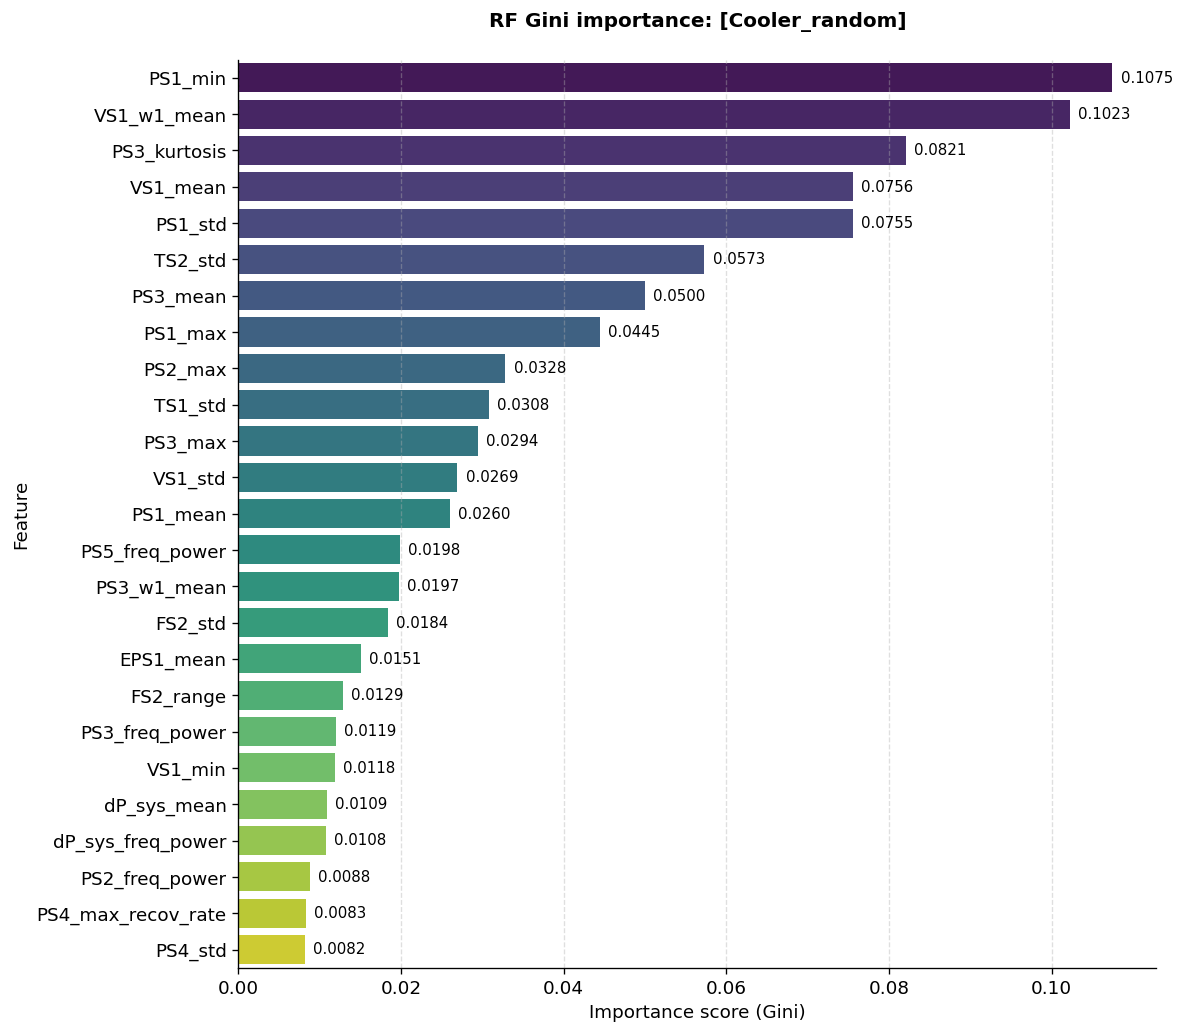


  Target: [Cooler]  |  Block split at cycle 1664
  Train: 1664 cycles  |  Test: 541 cycles

  Class                              Train     Test
  Near failure (3%)                  44.0%     0.0% <- low
  Reduced (20%)                      44.0%     0.0% <- low
  Full (100%)                        12.0%   100.0%


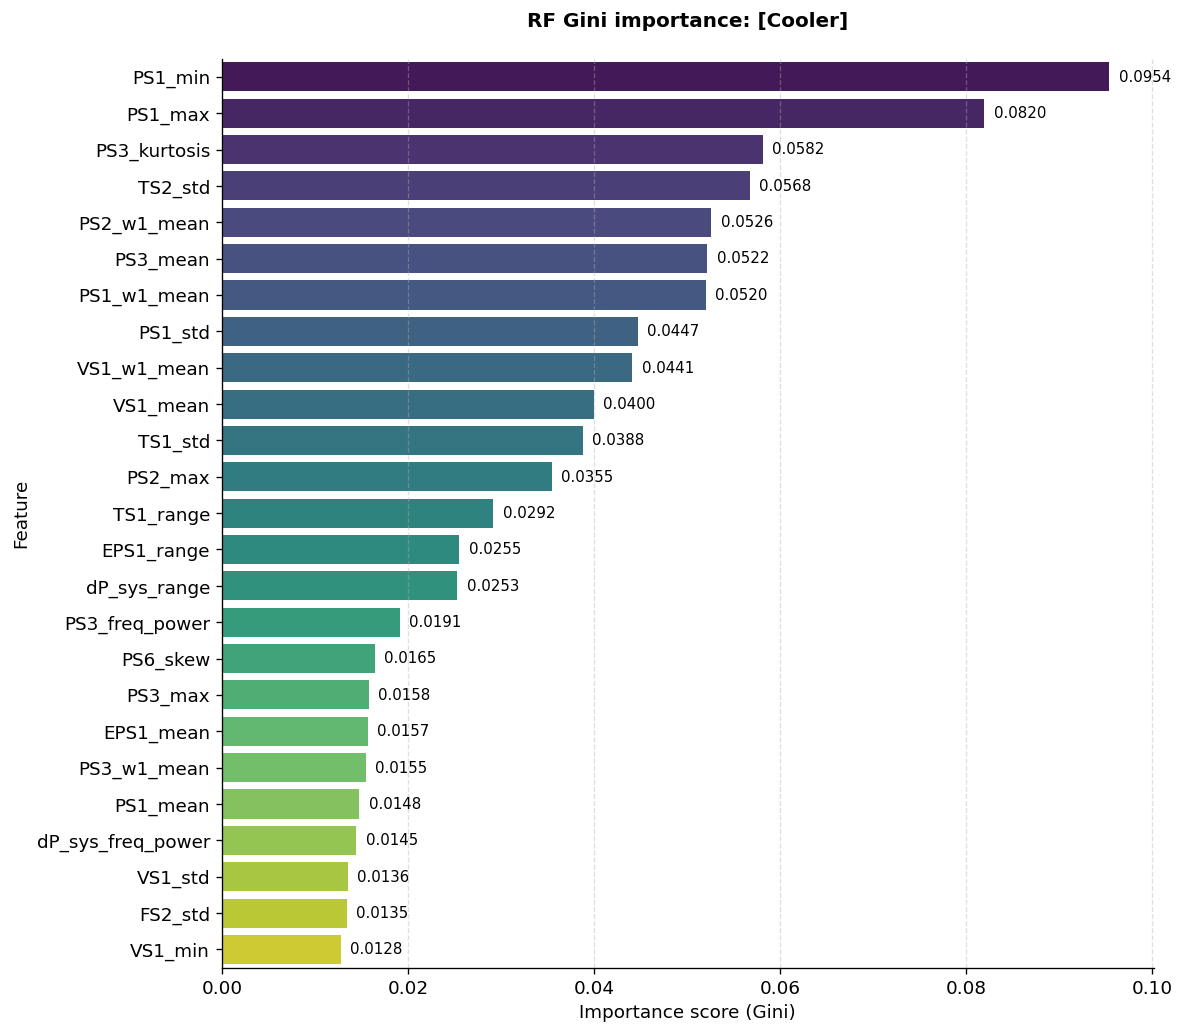


  [Cooler - Random] Class distribution:
  Class                   Train     Test
  0                       33.2%    33.3%
  1                       33.2%    33.1%
  2                       33.6%    33.6%

  [Cooler - Block] Class distribution:
  Class                   Train     Test
  0                       44.0%     0.0% <- low
  1                       44.0%     0.0% <- low
  2                       12.0%   100.0%
  Cooler               1.0000     1.0000      +0.0000


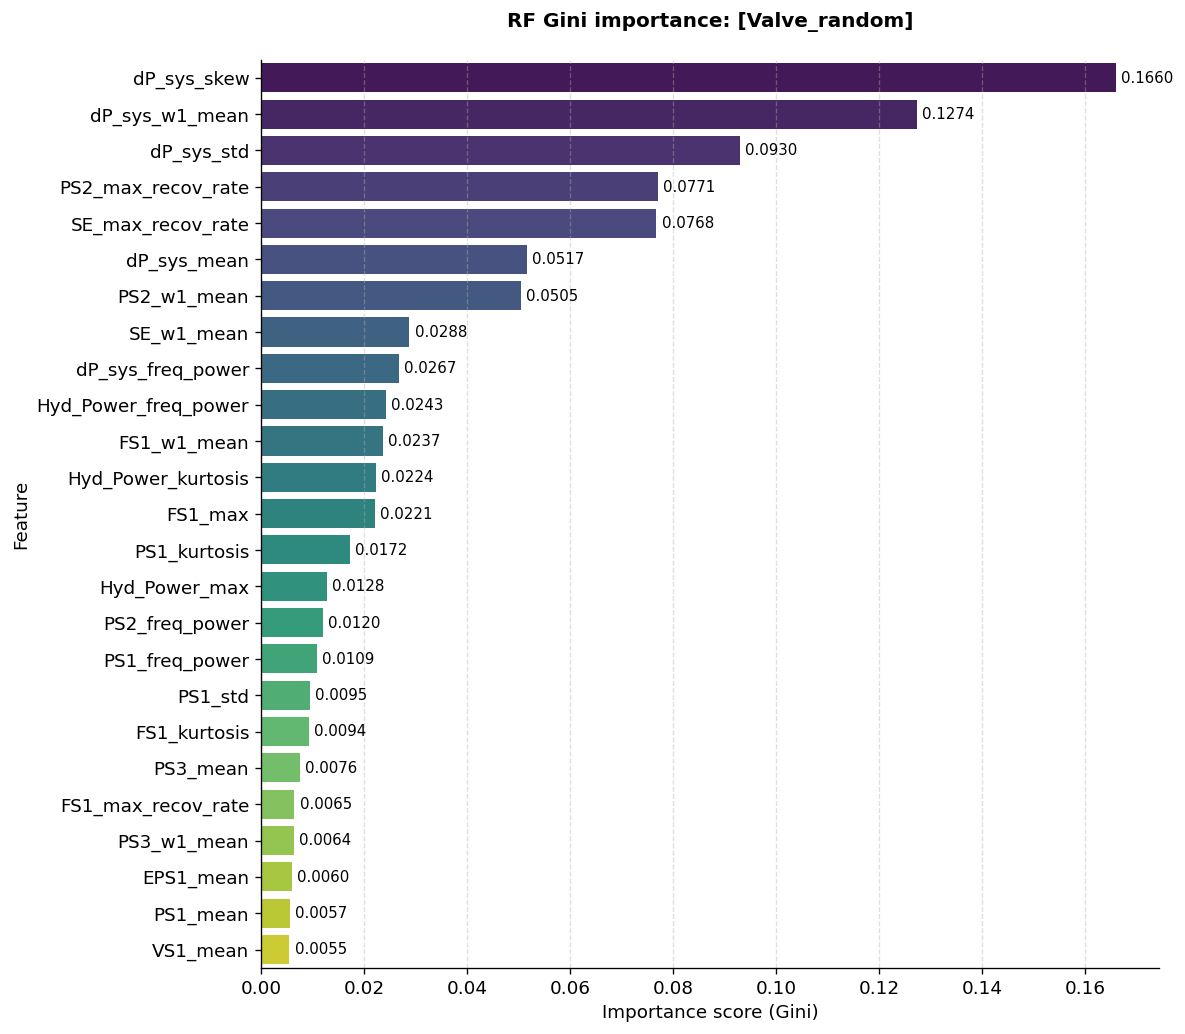


  Target: [Valve]  |  Block split at cycle 1664
  Train: 1664 cycles  |  Test: 541 cycles

  Class                              Train     Test
  Near failure (73%)                 14.4%    22.2%
  Severe lag (80%)                   14.4%    22.2%
  Small lag (90%)                    14.4%    22.2%
  Optimal (100%)                     56.7%    33.5%


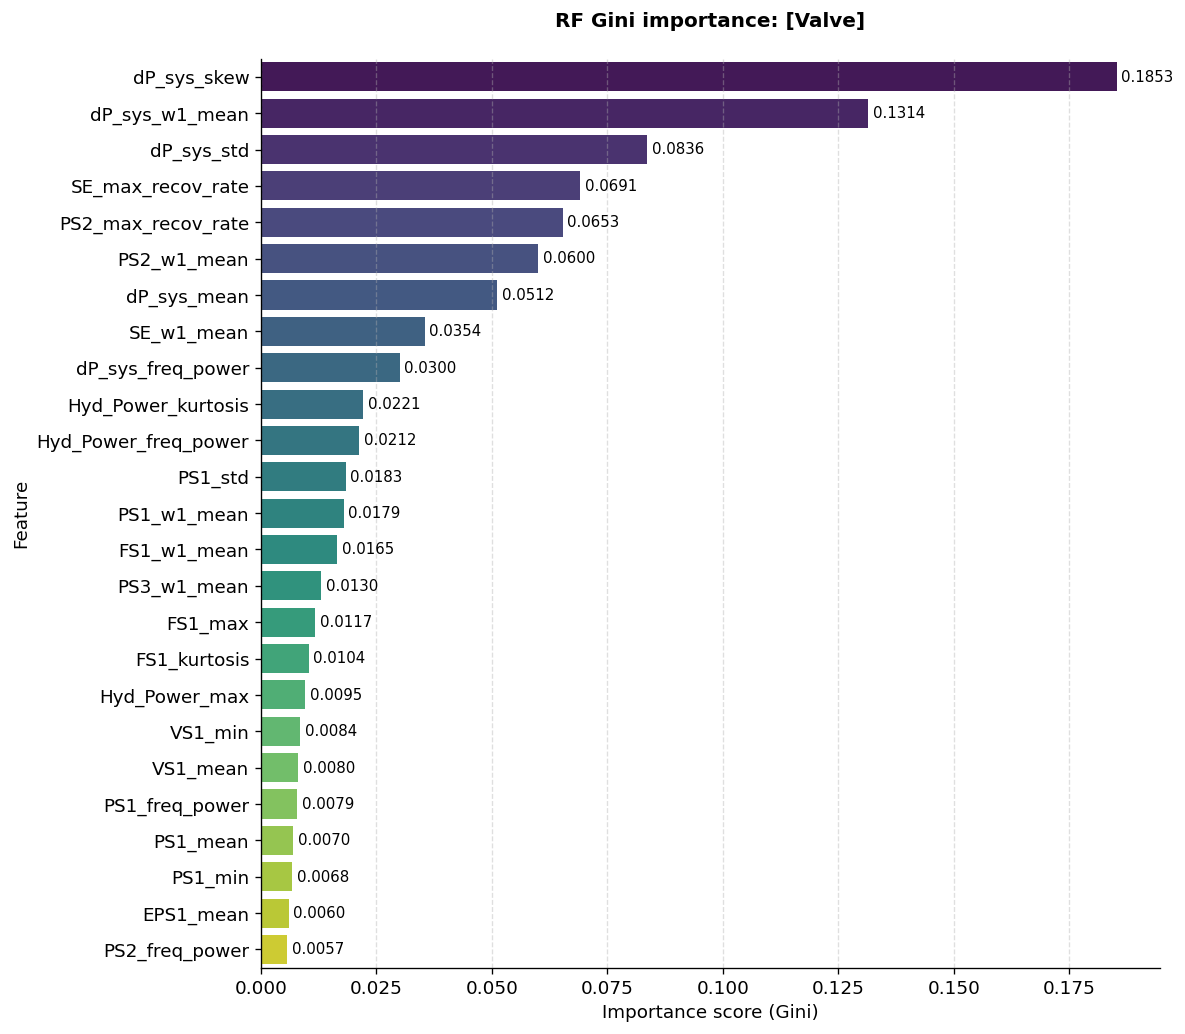


  [Valve - Random] Class distribution:
  Class                   Train     Test
  0                       16.3%    16.3%
  1                       16.3%    16.3%
  2                       16.3%    16.3%
  3                       51.0%    51.0%

  [Valve - Block] Class distribution:
  Class                   Train     Test
  0                       14.4%    22.2%
  1                       14.4%    22.2%
  2                       14.4%    22.2%
  3                       56.7%    33.5%
  Valve                0.9931     1.0000      -0.0069


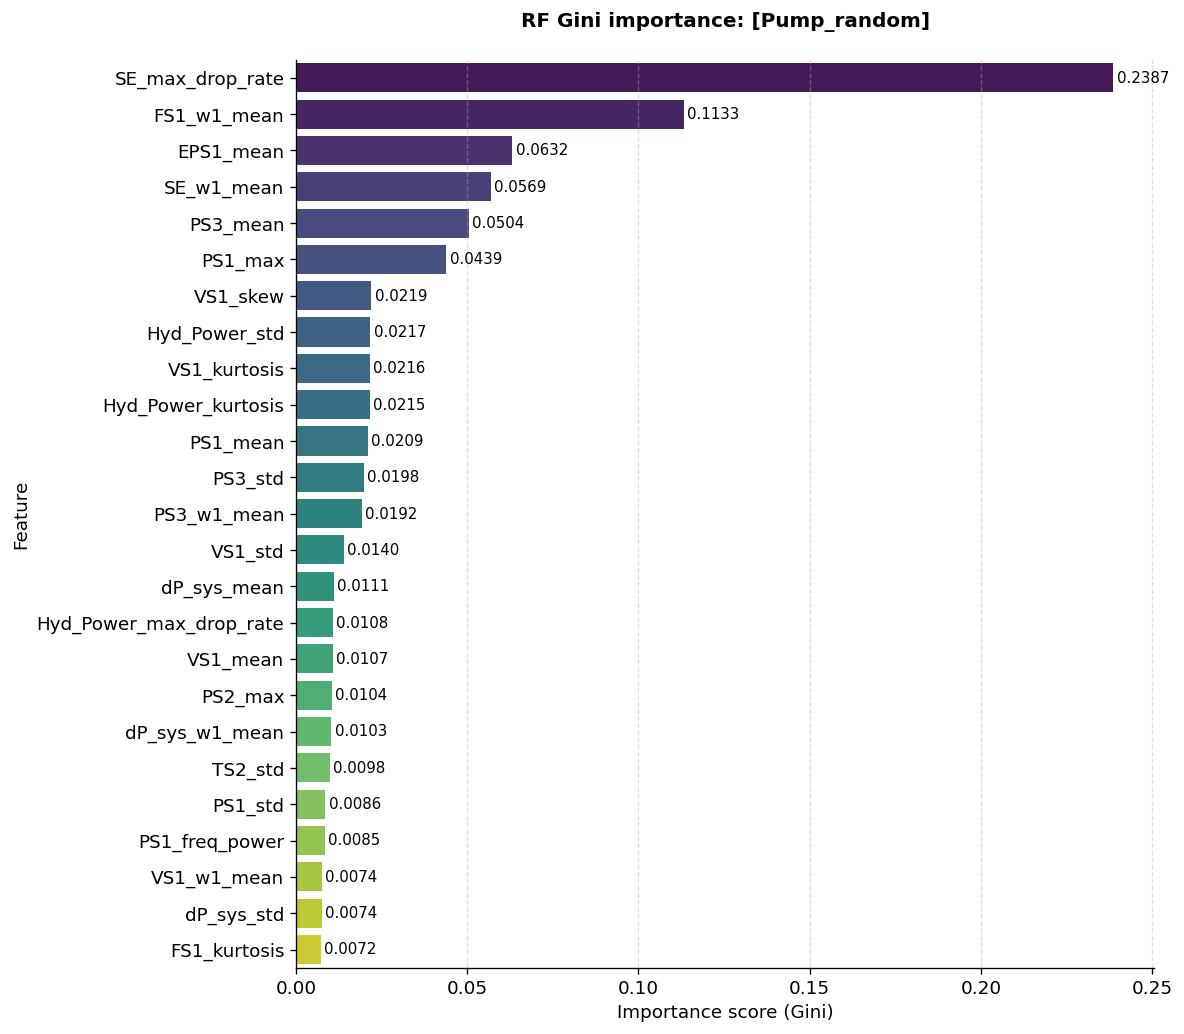


  Target: [Pump]  |  Block split at cycle 1664
  Train: 1664 cycles  |  Test: 541 cycles

  Class                              Train     Test
  No leakage                         60.6%    39.4%
  Weak leakage                       19.7%    30.3%
  Severe leakage                     19.7%    30.3%


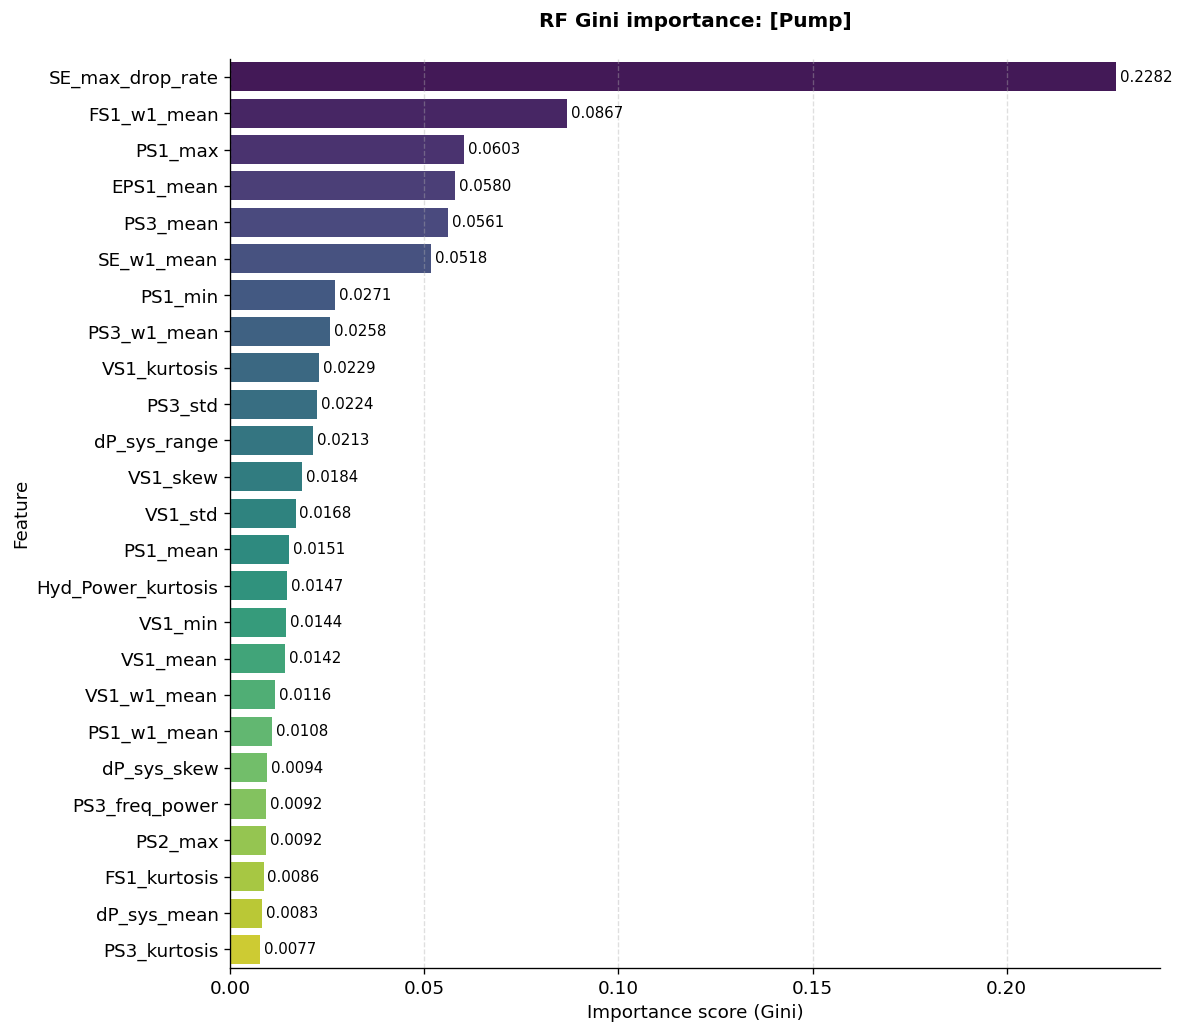


  [Pump - Random] Class distribution:
  Class                   Train     Test
  0                       55.4%    55.3%
  1                       22.3%    22.4%
  2                       22.3%    22.2%

  [Pump - Block] Class distribution:
  Class                   Train     Test
  0                       60.6%    39.4%
  1                       19.7%    30.3%
  2                       19.7%    30.3%
  Pump                 0.9898     0.1883      +0.8015<- leakage detected


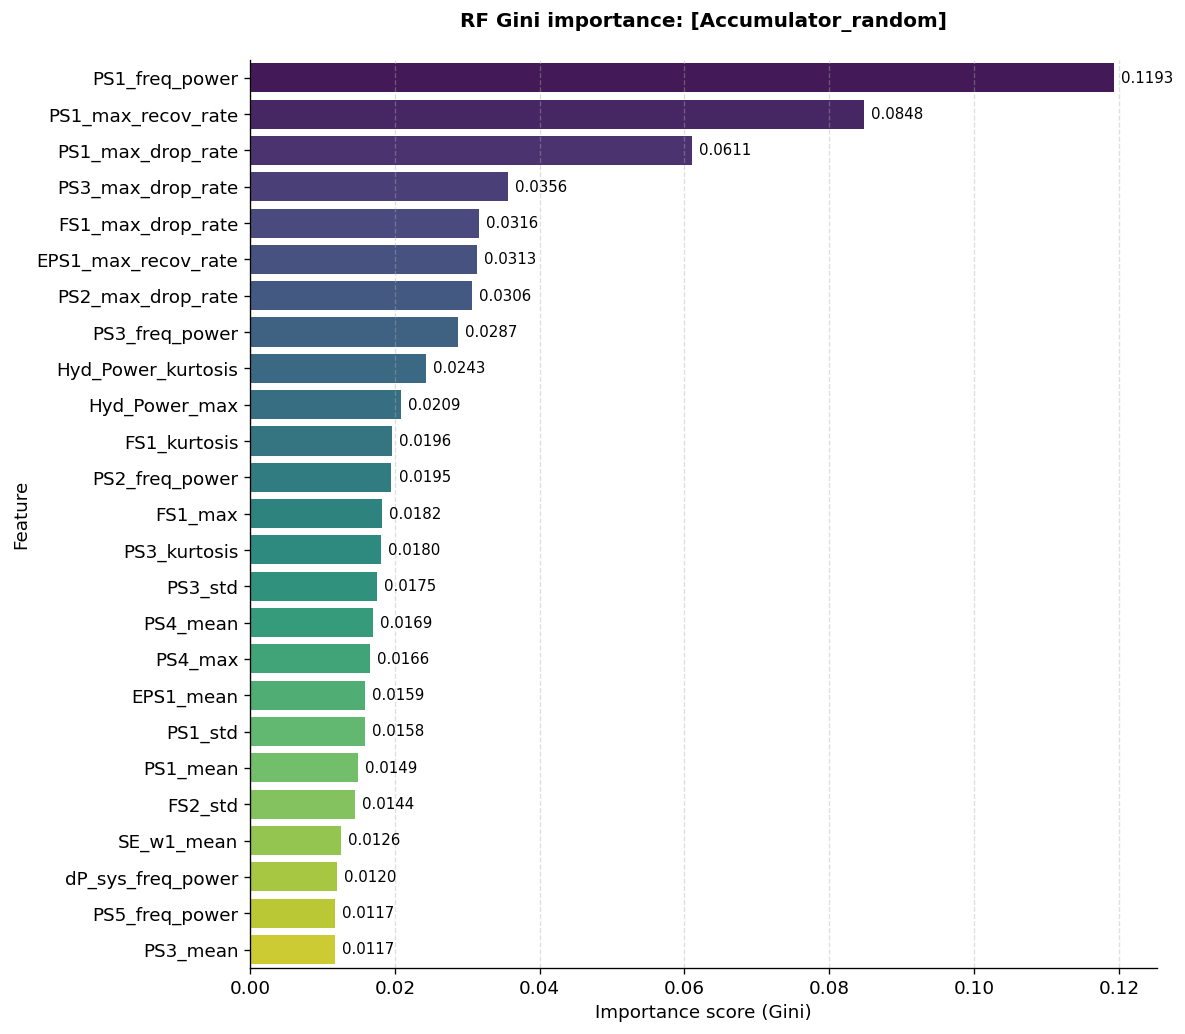


  Target: [Accumulator]  |  Block split at cycle 1664
  Train: 1664 cycles  |  Test: 541 cycles

  Class                              Train     Test
  Near failure (90 bar)              40.0%    26.2%
  Severe (100 bar)                   16.0%    24.6%
  Slight (115 bar)                   16.0%    24.6%
  Optimal (130 bar)                  28.0%    24.6%


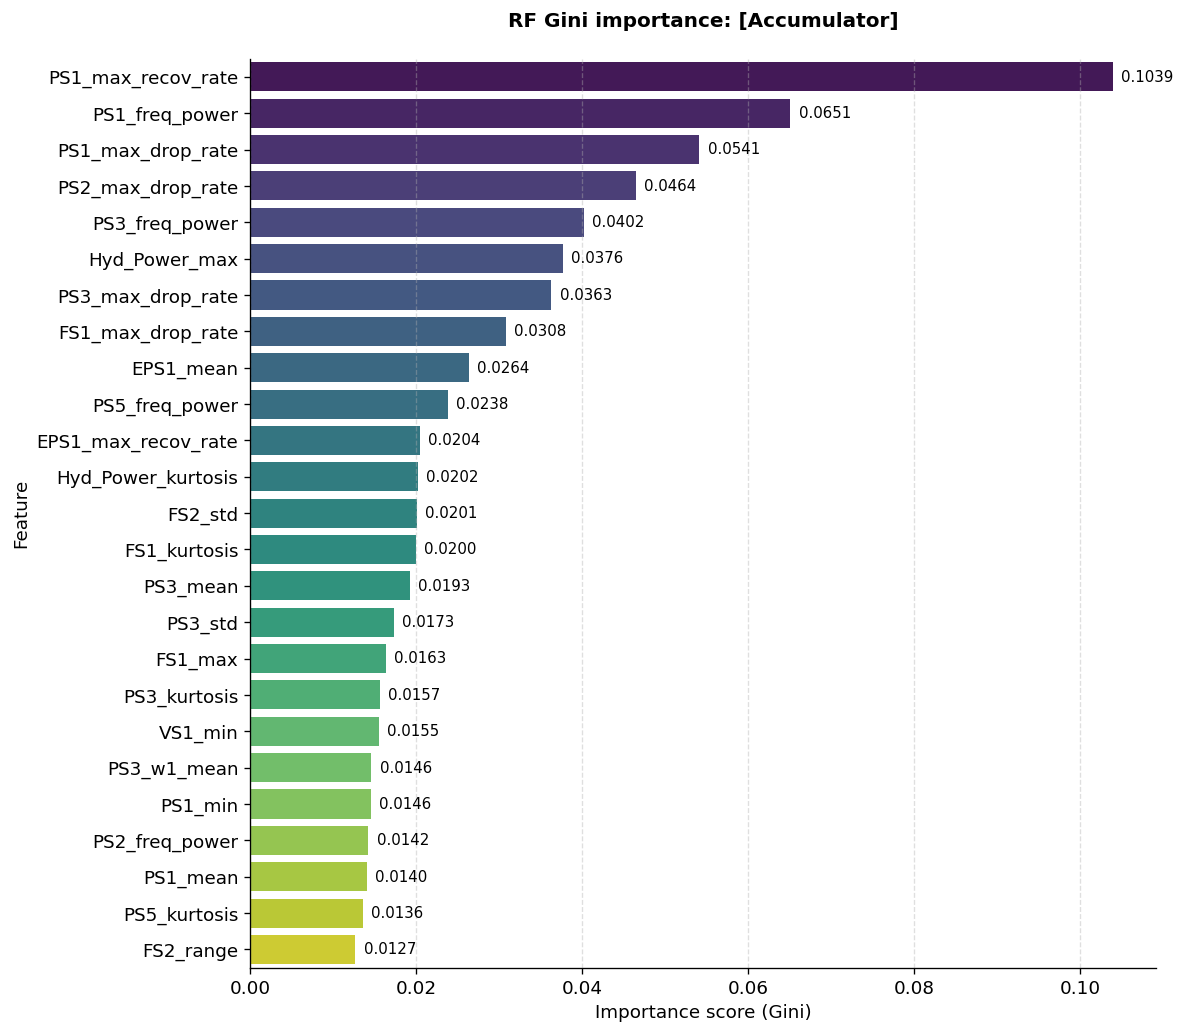


  [Accumulator - Random] Class distribution:
  Class                   Train     Test
  0                       36.7%    36.5%
  1                       18.1%    18.1%
  2                       18.1%    18.1%
  3                       27.2%    27.2%

  [Accumulator - Block] Class distribution:
  Class                   Train     Test
  0                       40.0%    26.2%
  1                       16.0%    24.6%
  2                       16.0%    24.6%
  3                       28.0%    24.6%
  Accumulator          0.9742     0.5343      +0.4399<- leakage detected


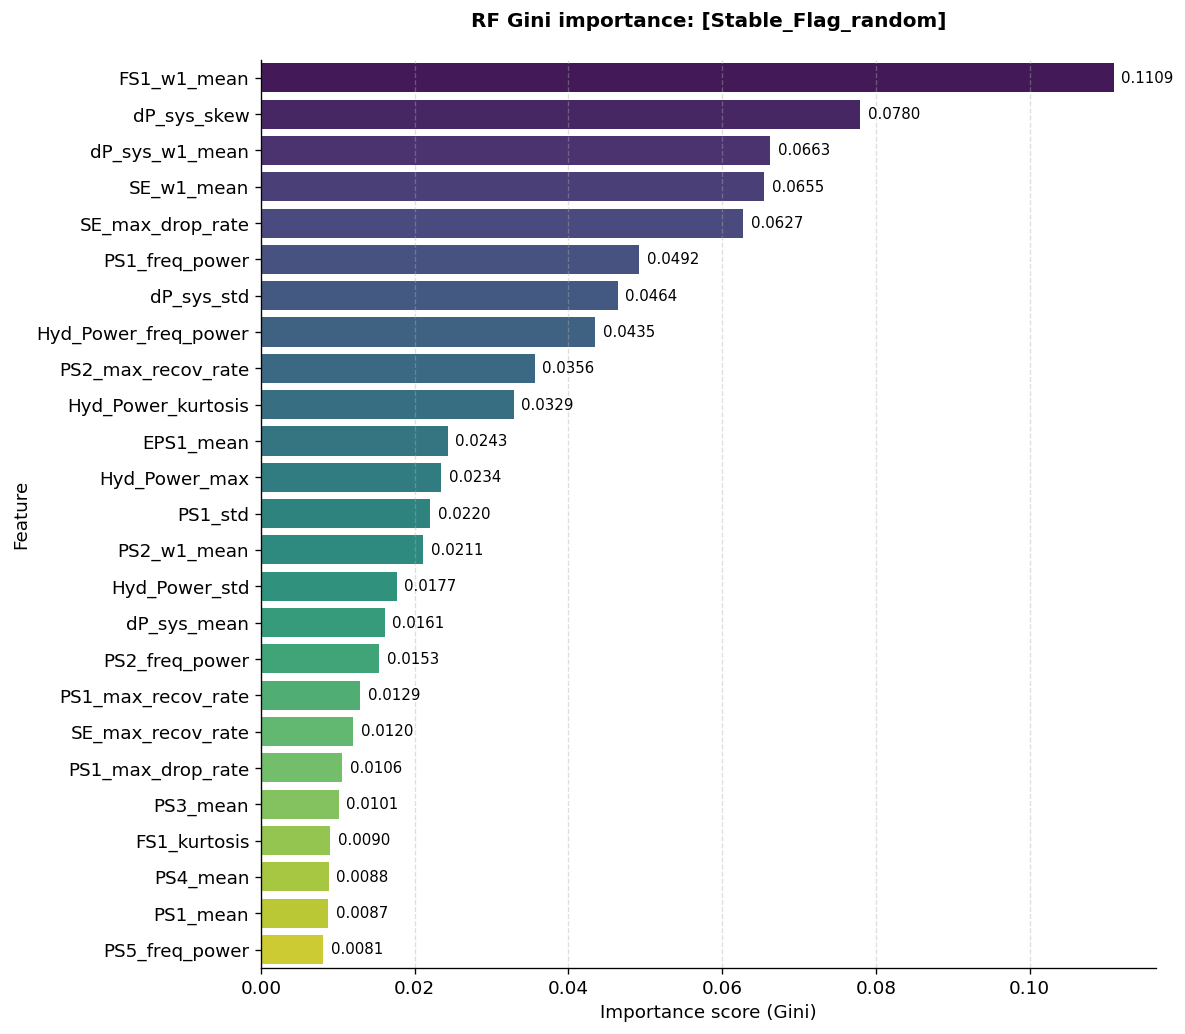


  Target: [Stable_Flag]  |  Block split at cycle 1664
  Train: 1664 cycles  |  Test: 541 cycles

  Class                              Train     Test
  Unstable                           57.7%    90.4%
  Stable                             42.3%     9.6%


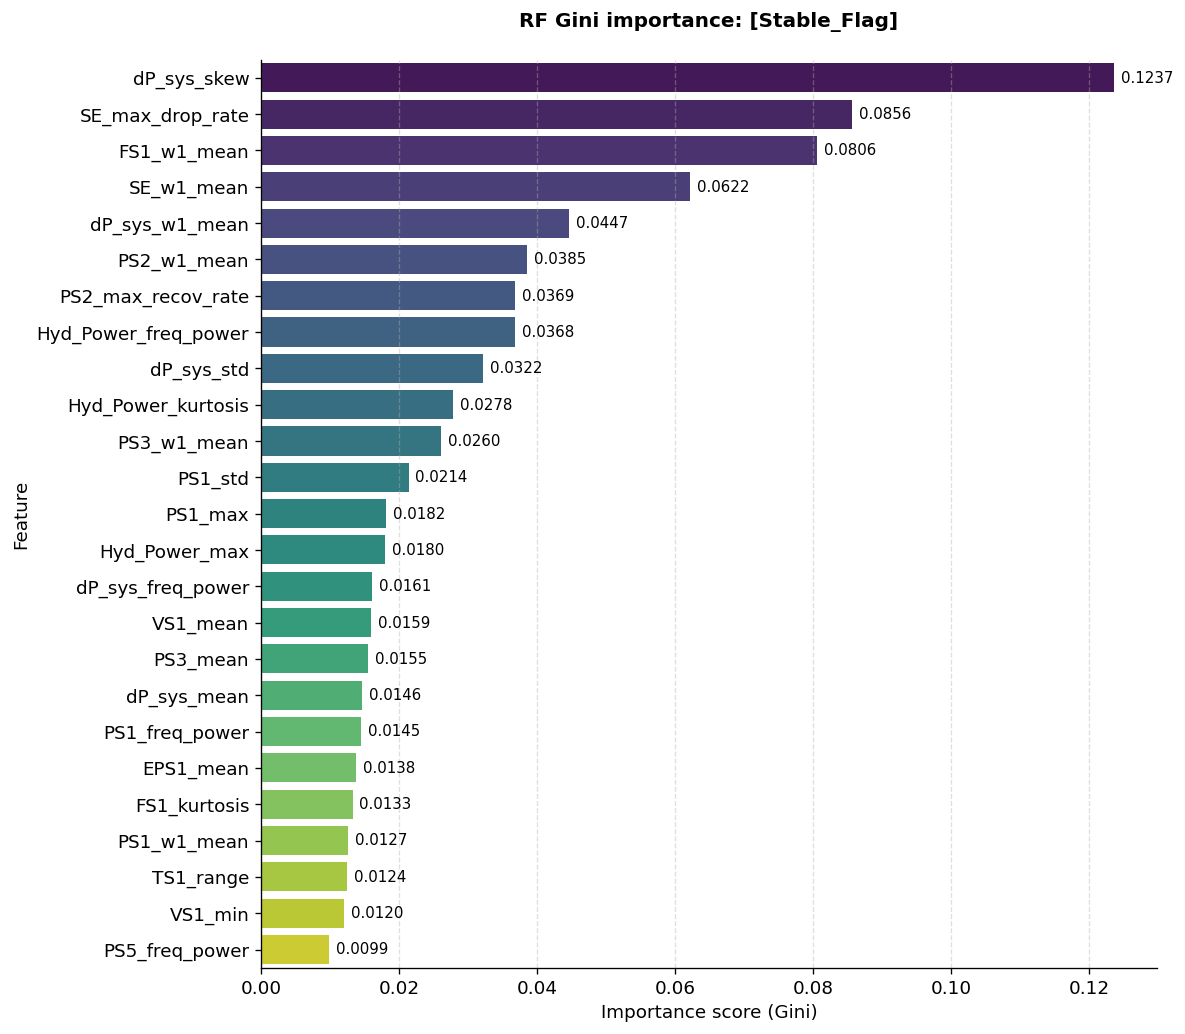


  [Stable_Flag - Random] Class distribution:
  Class                   Train     Test
  0                       65.7%    65.8%
  1                       34.3%    34.2%

  [Stable_Flag - Block] Class distribution:
  Class                   Train     Test
  0                       57.7%    90.4%
  1                       42.3%     9.6%
  Stable_Flag          0.9723     0.6798      +0.2924<- leakage detected
        Target  F1_random  F1_block       Gap
0       Cooler   1.000000  1.000000  0.000000
1        Valve   0.993054  1.000000 -0.006946
2         Pump   0.989847  0.188329  0.801518
3  Accumulator   0.974153  0.534263  0.439890
4  Stable_Flag   0.972261  0.679832  0.292430


In [31]:
# Run both strategies and print comparison

TARGETS = ['Cooler', 'Valve', 'Pump', 'Accumulator', 'Stable_Flag']

print("\n" + "=" * 70)
print("  SPLIT STRATEGY COMPARISON")
print("  Demonstrates temporal leakage in random splits")
print("  (All reported results use Block Split only)")
print("=" * 70)
print(f"  {'Target':<16} {'Random F1':>10} {'Block F1':>10} {'Leakage gap':>12}")
print(f"  {'-'*52}")

split_comparison = []
model_storage    = {}   # filled by block split

for target in TARGETS:
    # Strategy 1: random split (feature validation only)
    try:
        Xtr_r, Xte_r, ytr_r, yte_r, le_r, sc_r, _ = prepare_random_split(
            target, features_df, labels, max_features=25)
        f1_random = quick_rf_eval(Xtr_r, Xte_r, ytr_r, yte_r)
    except Exception as e:
        print(f"  [{target}] random split failed: {e}")
        f1_random = None

    # Strategy 2: block split (deployment simulation - canonical)
    Xtr_b, Xte_b, ytr_b, yte_b, le_b, sc_b, feats = prepare_block_split(
        target, features_df, labels,
        split_cycle=optimal_split_index, max_features=25)
    f1_block = quick_rf_eval(Xtr_b, Xte_b, ytr_b, yte_b)

    if f1_random is not None:
      print_dist(f"{target} - Random", ytr_r, yte_r)
    print_dist(f"{target} - Block",  ytr_b, yte_b)

    gap  = (f1_random - f1_block) if f1_random is not None else None
    flag = "<- leakage detected" if gap is not None and gap > 0.03 else ""

    split_comparison.append({
        'Target':    target,
        'F1_random': f1_random,
        'F1_block':  f1_block,
        'Gap':       gap,
    })

    r_str = f"{f1_random:.4f}" if f1_random is not None else "  N/A  "
    g_str = f"{gap:+.4f}" if gap is not None else "   N/A"
    print(f"  {target:<16} {r_str:>10} {f1_block:>10.4f} {g_str:>12}{flag}")

    # Store block split data for all downstream sections
    model_storage[target] = {
        'X_train':          Xtr_b,
        'X_test':           Xte_b,
        'y_train':          ytr_b,
        'y_test':           yte_b,
        'le':               le_b,
        'scaler':           sc_b,
        'selected_features': feats,
        'clfs':             {},
    }

split_df = pd.DataFrame(split_comparison)
print(split_df)

**Interpretation:**

  • A large positive gap (Random F1 >> Block F1) indicates temporal leakage: future fault states in training inflate random-split scores.

  • A small gap confirms that our features genuinely encode fault signal rather than exploiting temporal patterns.
  
  • All performance figures in Sections 7-10 use Block Split only, consistent with the deployment scenario for BAE Systems.

In [32]:
# SPLIT VERIFICATION - confirm all classes present in training block

# This cell explicitly verifies that the block split at cycle 1664  retains all fault classes in the training set for every target.
# A class absent from training would mean the model has never seen that fault condition - making generalisation impossible.

print("\n" + "=" * 65)
print("  BLOCK SPLIT VERIFICATION")
print("  Confirming all fault classes present in training block")
print("=" * 65)
print(f"  Split point: cycle {optimal_split_index}")
print(f"  Train block: cycles 0 – {optimal_split_index - 1} "
      f"({optimal_split_index} cycles)")
print(f"  Test block:  cycles {optimal_split_index} – 2204 "
      f"({2205 - optimal_split_index} cycles)")
print()

all_verified = True
for target in TARGETS:
    store    = model_storage[target]
    le       = store['le']
    y_train  = store['y_train']
    y_test   = store['y_test']
    lmap     = LABEL_MAPS.get(target, {})

    train_classes = set(y_train.unique())
    test_classes  = set(y_test.unique())
    all_classes   = set(range(len(le.classes_)))
    missing_train = all_classes - train_classes
    missing_test  = all_classes - test_classes

    status = "PASS" if not missing_train else "FAIL"
    if missing_train:
        all_verified = False

    print(f"  [{target}]  {status}")
    print(f"    Classes in training: "
          f"{[str(lmap.get(le.classes_[i], le.classes_[i])) for i in sorted(train_classes)]}")
    if missing_test:
        missing_labels = [str(lmap.get(le.classes_[i], le.classes_[i]))
                          for i in sorted(missing_test)]
        print(f"    Classes absent from test: {missing_labels}")
        print(f"    -> Expected for block split - "
              f"these conditions only occur in training period")
    print()

if all_verified:
    print("  RESULT: All fault classes present in training block.")
    print("  Block split at cycle 1664 is valid for all targets.")
else:
    print("  WARNING: Some classes missing from training.")
    print("  Consider adjusting the split point.")
print("=" * 65)


  BLOCK SPLIT VERIFICATION
  Confirming all fault classes present in training block
  Split point: cycle 1664
  Train block: cycles 0 – 1663 (1664 cycles)
  Test block:  cycles 1664 – 2204 (541 cycles)

  [Cooler]  PASS
    Classes in training: ['Near failure (3%)', 'Reduced (20%)', 'Full (100%)']
    Classes absent from test: ['Near failure (3%)', 'Reduced (20%)']
    -> Expected for block split - these conditions only occur in training period

  [Valve]  PASS
    Classes in training: ['Near failure (73%)', 'Severe lag (80%)', 'Small lag (90%)', 'Optimal (100%)']

  [Pump]  PASS
    Classes in training: ['No leakage', 'Weak leakage', 'Severe leakage']

  [Accumulator]  PASS
    Classes in training: ['Near failure (90 bar)', 'Severe (100 bar)', 'Slight (115 bar)', 'Optimal (130 bar)']

  [Stable_Flag]  PASS
    Classes in training: ['Unstable', 'Stable']

  RESULT: All fault classes present in training block.
  Block split at cycle 1664 is valid for all targets.


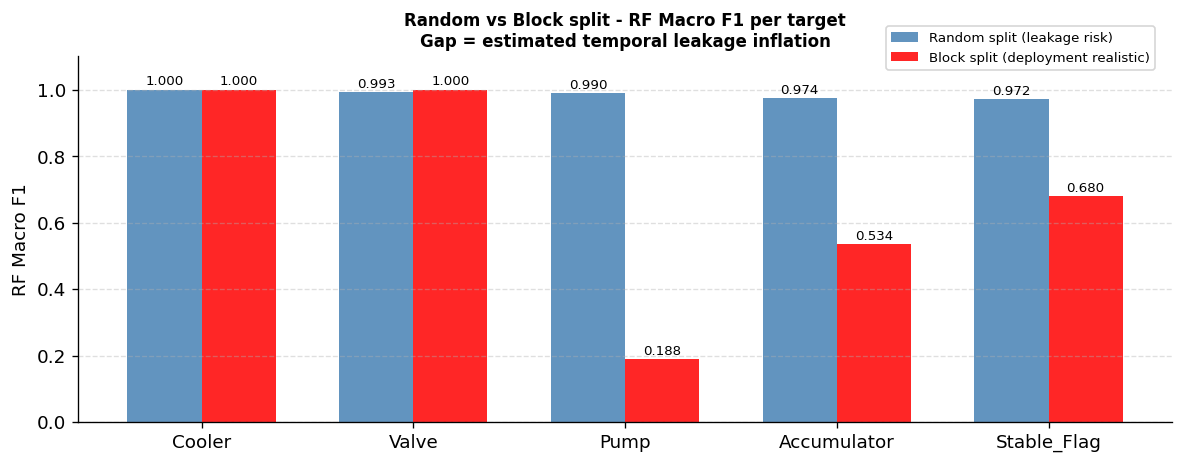

In [33]:
# Visualise the comparison
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(TARGETS))
w = 0.35

bars1 = ax.bar(x - w/2,
               [r['F1_random'] if r['F1_random'] else 0 for r in split_comparison],
               width=w, label='Random split (leakage risk)',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2,
               [r['F1_block'] for r in split_comparison],
               width=w, label='Block split (deployment realistic)',
               color='red', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(TARGETS)
ax.set_ylabel('RF Macro F1')
ax.set_ylim(0, 1.10)
ax.set_title(
    'Random vs Block split - RF Macro F1 per target\n'
    'Gap = estimated temporal leakage inflation',
    fontweight='bold', fontsize=10)
ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(0.99, 1.1))
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Split_Strategy_Comparison.png'),
            bbox_inches='tight')
plt.show()

# **Section 7 - MODELLING**

### Model selection rationale

| Model | Justification |
|---|---|
| LDA | Baseline following Helwig et al. (2015) original paper |
| Random Forest | Strongest overall in Al-Khulaqi et al. (2025) and Alenany et al. (2021) |
| XGBoost | Gradient boosting comparison; Vayeghan & Moshiri (2023) |
| SVM (RBF) | Non-linear benchmark; Helwig et al. (2015) |
| AdaBoost | Ensemble boosting; Al-Khulaqi et al. (2025) |

All classifiers using `class_weight='balanced'` where supported
(addresses Valve imbalance).

Evaluation: 5-fold stratified CV
on training block + blind test on temporal test block.


Primary metric: Macro F1 - weights all fault classes equally,
critical for maintenance where rare faults are most important
(Rivas et al., 2022).

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV)
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier

### **Hyperparameter Tuning**

In [35]:
#Hyperparameter Tuning

def tune_random_forest(X_train, y_train, target_name):
    """
    RandomizedSearchCV (20 iterations, 3-fold CV) over key RF hyperparameters. Returns best estimator and params.
    """
    print(f"  Tuning RF for [{target_name}]...")
    param_dist = {
        'n_estimators':     [100, 200, 300],
        'max_depth':        [None, 10, 20],
        'min_samples_leaf': [1, 2, 4],
        'max_features':     ['sqrt', 'log2'],
    }
    rf_base = RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1)
    search  = RandomizedSearchCV(
        rf_base, param_dist, n_iter=20,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1_macro', random_state=42, n_jobs=-1)
    search.fit(X_train, y_train)
    print(f"    Best: {search.best_params_}  CV F1: {search.best_score_:.4f}")
    return search.best_estimator_, search.best_params_

In [36]:
def evaluate_all_models(target, X_train, X_test, y_train, y_test, le):
    """
    Train 5 classifiers with 5-fold CV + blind test evaluation.
    Prints classification report for the best model.
    """
    classifiers = {
        'LDA':          LinearDiscriminantAnalysis(),
        'RandomForest': RandomForestClassifier(
                            n_estimators=200, class_weight='balanced',
                            random_state=42, n_jobs=-1),
        'XGBoost':      XGBClassifier(
                            n_estimators=200, max_depth=6,
                            learning_rate=0.1, eval_metric='mlogloss',
                            random_state=42, n_jobs=-1, verbosity=0),
        'SVM':          SVC(kernel='rbf', C=10, gamma='scale',
                            class_weight='balanced',
                            probability=True, random_state=42),
        'AdaBoost':     AdaBoostClassifier(
                            n_estimators=100, random_state=42),
    }

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results  = []
    trained  = {}

    print(f"\n{'─'*20}  [{target}] {'─'*20}")
    for name, clf in classifiers.items():
        cv_f1s = []
        for tr_i, val_i in skf.split(X_train, y_train):
            clf.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
            cv_f1s.append(f1_score(
                y_train.iloc[val_i],
                clf.predict(X_train.iloc[val_i]),
                average='macro'))

        clf.fit(X_train, y_train)
        trained[name] = clf
        y_pred = clf.predict(X_test)

        results.append({
            'Target': target, 'Model': name,
            'CV_F1':        np.mean(cv_f1s),
            'CV_F1_std':    np.std(cv_f1s),
            'Test_F1':      f1_score(y_test, y_pred, average='macro'),
            'Test_Acc':     accuracy_score(y_test, y_pred),
            'Test_Bal_Acc': balanced_accuracy_score(y_test, y_pred),
        })
        r = results[-1]
        print(f"  {name:<15} CV: {r['CV_F1']:.4f}±{r['CV_F1_std']:.4f}"
              f"  Test F1: {r['Test_F1']:.4f}  BalAcc: {r['Test_Bal_Acc']:.4f}")

    # Classification report - best model
    best = max(results, key=lambda x: x['Test_F1'])['Model']
    y_pred_best = trained[best].predict(X_test)

    present = sorted(set(y_test.values) | set(y_pred_best))
    class_names = [str(le.classes_[i]) for i in present]
    # class_names = [str(c) for c in le.classes_]

    print(f"\n  Classification report ({best}):")
    # print(classification_report(y_test, y_pred_best, target_names=class_names, digits=3))
    print(classification_report(y_test, y_pred_best, labels=present, target_names=class_names))
    return results, trained

### **All model evaluation on Random split**

  STRATEGY 1: RANDOM SPLIT (feature validation baseline)


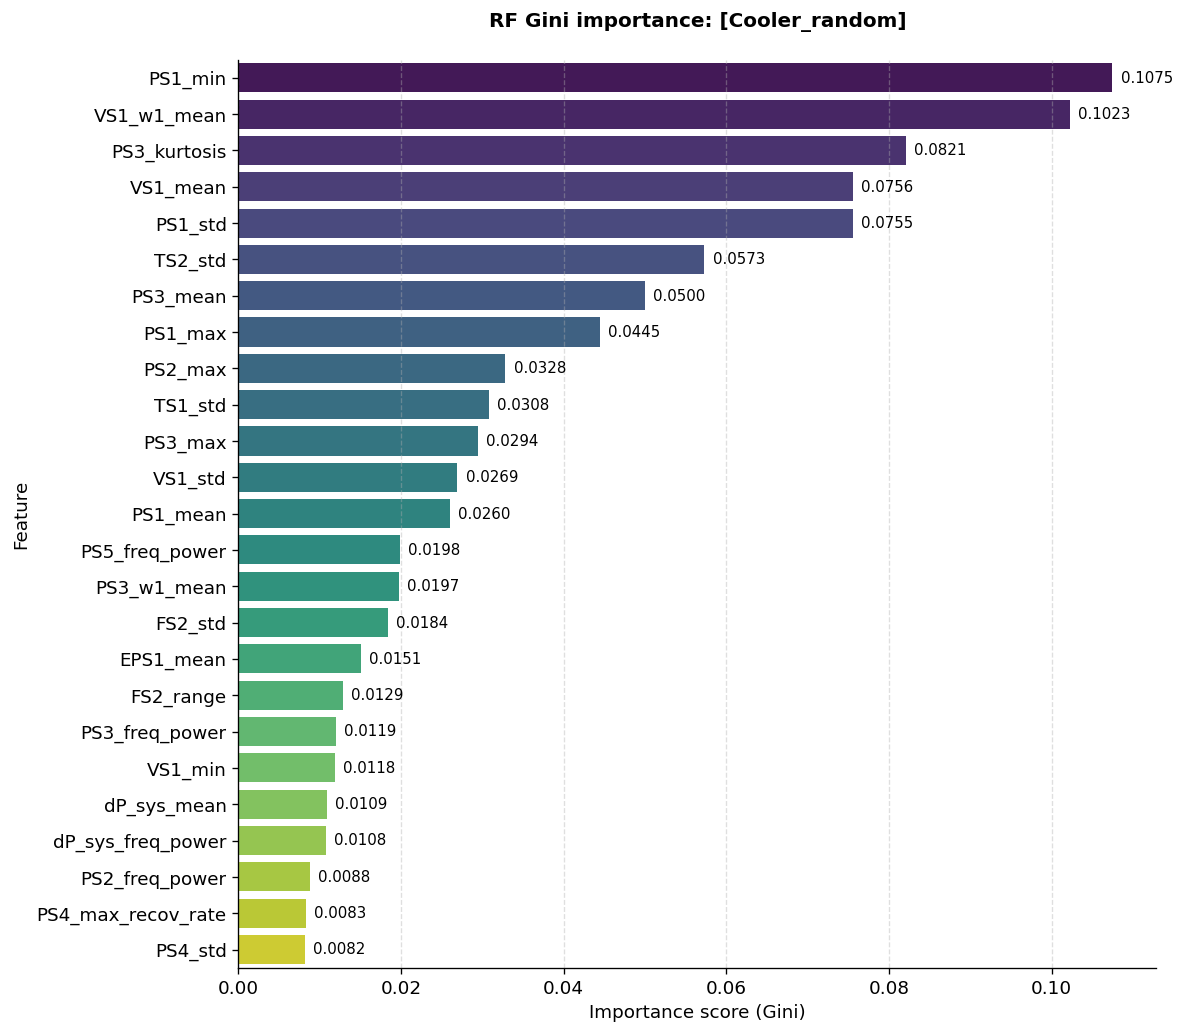


────────────────────  [Cooler] ────────────────────
  LDA             CV: 0.9972±0.0031  Test F1: 0.9955  BalAcc: 0.9955
  RandomForest    CV: 0.9966±0.0042  Test F1: 1.0000  BalAcc: 1.0000
  XGBoost         CV: 0.9977±0.0033  Test F1: 0.9977  BalAcc: 0.9977
  SVM             CV: 0.9977±0.0033  Test F1: 0.9977  BalAcc: 0.9977
  AdaBoost        CV: 0.9977±0.0033  Test F1: 1.0000  BalAcc: 1.0000

  Classification report (RandomForest):
              precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      1.00      1.00       146
         100       1.00      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



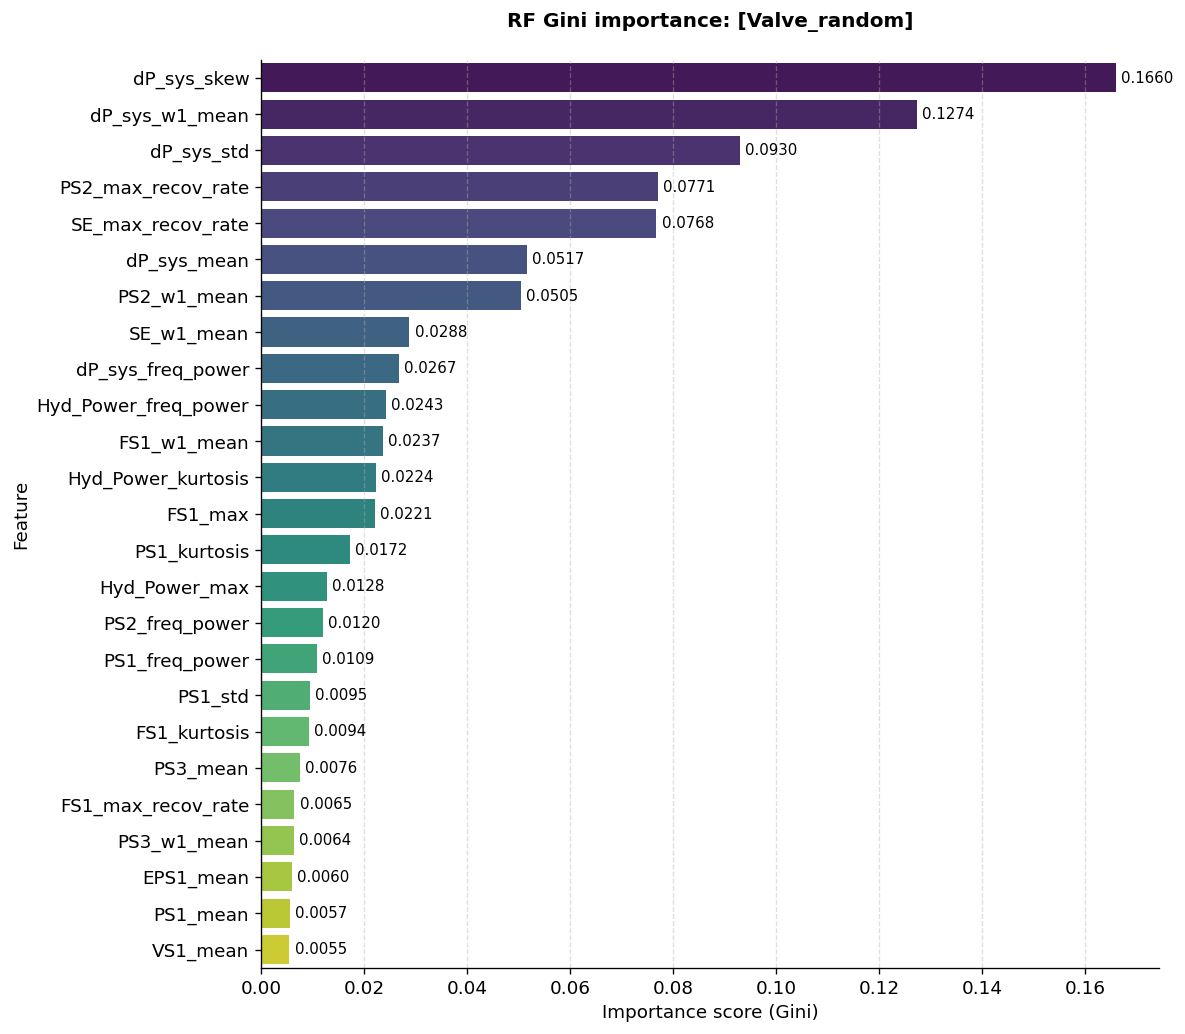


────────────────────  [Valve] ────────────────────
  LDA             CV: 1.0000±0.0000  Test F1: 0.9977  BalAcc: 0.9965
  RandomForest    CV: 0.9962±0.0020  Test F1: 0.9931  BalAcc: 0.9931
  XGBoost         CV: 0.9939±0.0023  Test F1: 0.9861  BalAcc: 0.9861
  SVM             CV: 0.9918±0.0082  Test F1: 0.9943  BalAcc: 0.9954
  AdaBoost        CV: 0.8627±0.2653  Test F1: 0.9908  BalAcc: 0.9919

  Classification report (LDA):
              precision    recall  f1-score   support

          73       1.00      1.00      1.00        72
          80       1.00      1.00      1.00        72
          90       1.00      0.99      0.99        72
         100       1.00      1.00      1.00       225

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



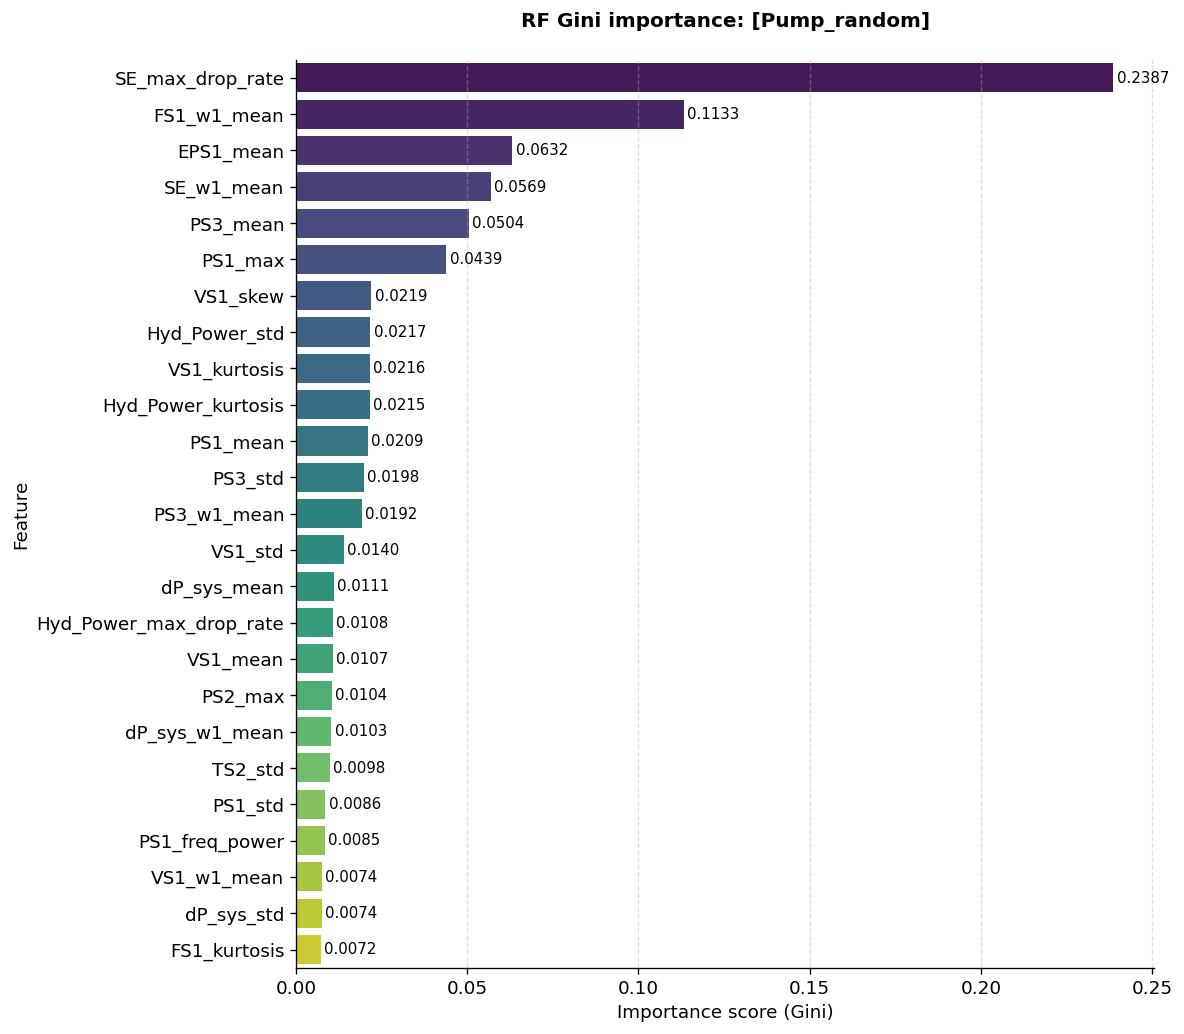


────────────────────  [Pump] ────────────────────
  LDA             CV: 0.9909±0.0064  Test F1: 0.9976  BalAcc: 0.9966
  RandomForest    CV: 0.9869±0.0053  Test F1: 0.9898  BalAcc: 0.9899
  XGBoost         CV: 0.9822±0.0095  Test F1: 0.9865  BalAcc: 0.9865
  SVM             CV: 0.9897±0.0043  Test F1: 0.9840  BalAcc: 0.9831
  AdaBoost        CV: 0.9598±0.0169  Test F1: 0.9695  BalAcc: 0.9695

  Classification report (LDA):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       244
           1       1.00      0.99      0.99        99
           2       1.00      1.00      1.00        98

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



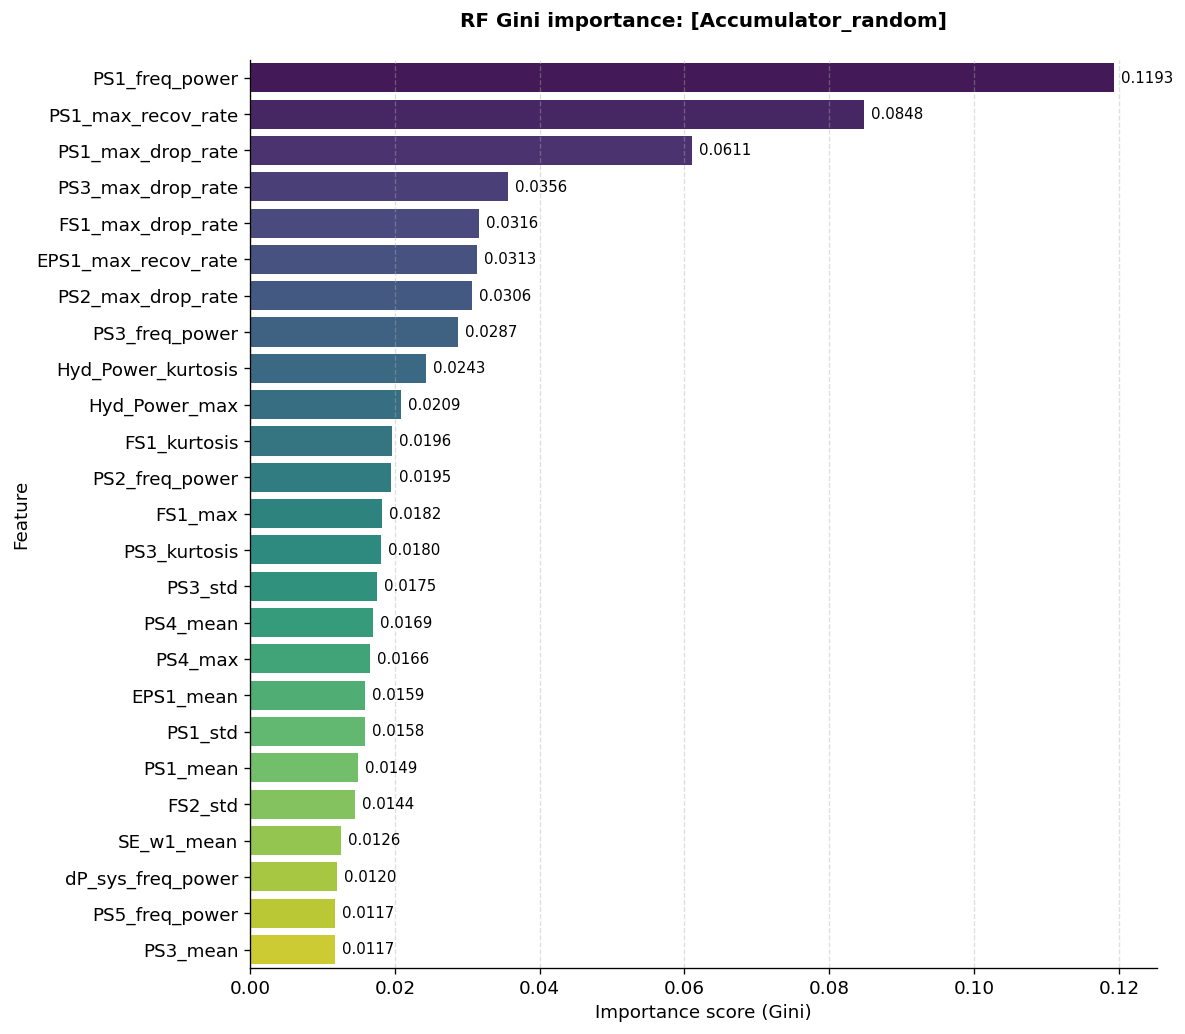


────────────────────  [Accumulator] ────────────────────
  LDA             CV: 0.8428±0.0188  Test F1: 0.8451  BalAcc: 0.8511
  RandomForest    CV: 0.9762±0.0078  Test F1: 0.9710  BalAcc: 0.9698
  XGBoost         CV: 0.9726±0.0057  Test F1: 0.9707  BalAcc: 0.9693
  SVM             CV: 0.9748±0.0104  Test F1: 0.9781  BalAcc: 0.9792
  AdaBoost        CV: 0.8307±0.0235  Test F1: 0.8447  BalAcc: 0.8559

  Classification report (SVM):
              precision    recall  f1-score   support

          90       0.99      1.00      1.00       161
         100       1.00      0.95      0.97        80
         115       0.92      1.00      0.96        80
         130       1.00      0.97      0.98       120

    accuracy                           0.98       441
   macro avg       0.98      0.98      0.98       441
weighted avg       0.98      0.98      0.98       441



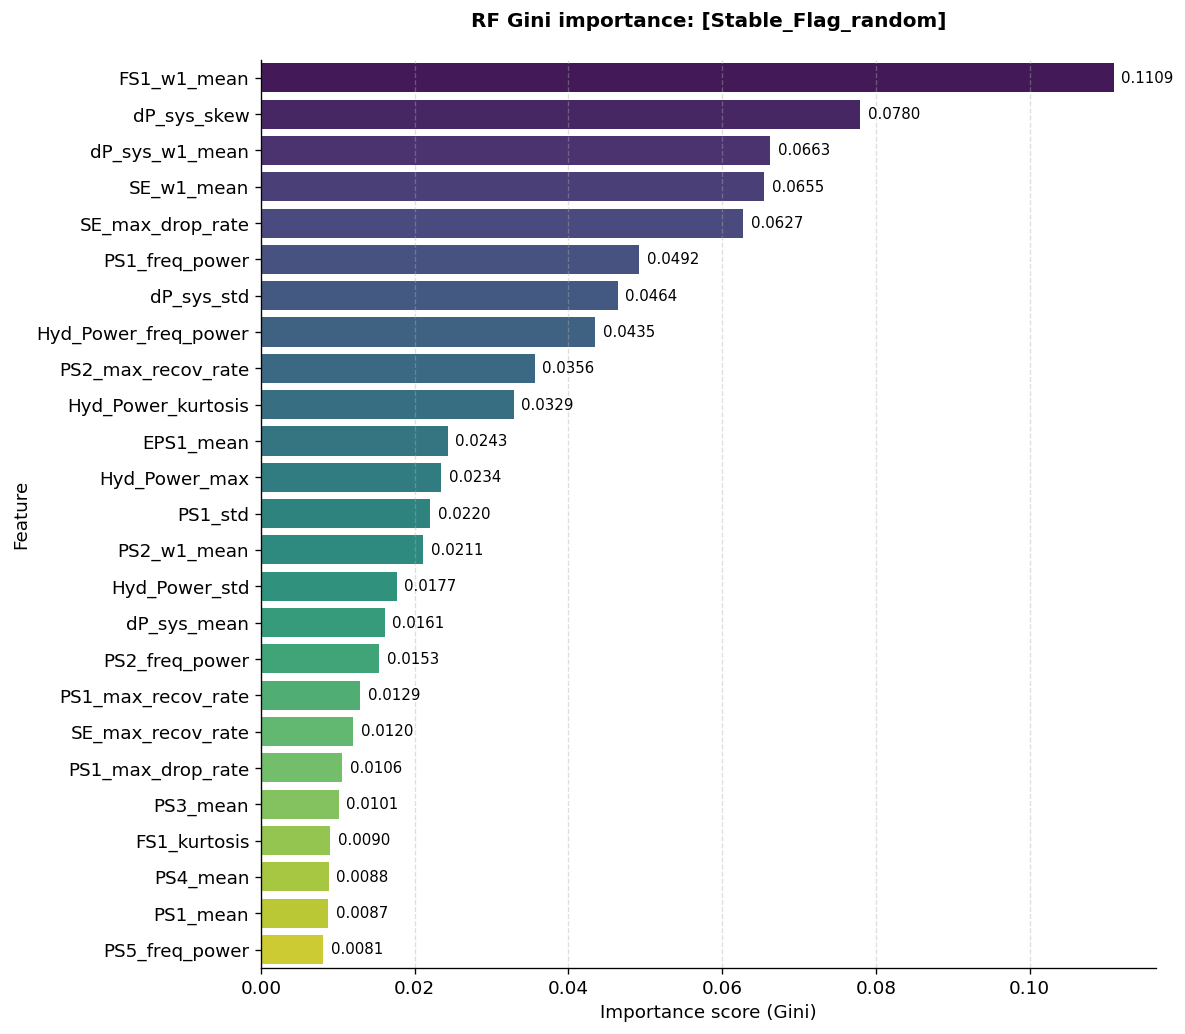


────────────────────  [Stable_Flag] ────────────────────
  LDA             CV: 0.9432±0.0144  Test F1: 0.9443  BalAcc: 0.9414
  RandomForest    CV: 0.9732±0.0111  Test F1: 0.9748  BalAcc: 0.9748
  XGBoost         CV: 0.9759±0.0099  Test F1: 0.9774  BalAcc: 0.9781
  SVM             CV: 0.9568±0.0095  Test F1: 0.9625  BalAcc: 0.9662
  AdaBoost        CV: 0.9590±0.0123  Test F1: 0.9649  BalAcc: 0.9663

  Classification report (XGBoost):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       290
           1       0.97      0.97      0.97       151

    accuracy                           0.98       441
   macro avg       0.98      0.98      0.98       441
weighted avg       0.98      0.98      0.98       441


 System Diagnosis Performance Ranking 

Target Component: Cooler
       Model    CV_F1  CV_F1_std  Test_F1  Test_Acc  Test_Bal_Acc
RandomForest 0.996605   0.004158 1.000000  1.000000      1.000000
    AdaBoost 0.997730   0.003304 1.0

In [37]:
#  Strategy 1: Random split - full 5-model evaluation

# Purpose: validate feature engineering and establish upper-bound scores.
# Results labelled clearly as "random split" - NOT used for deployment reporting.
# Following the original project approach of running both splits through the
# full model suite to demonstrate the leakage gap per model, not just RF.

TARGETS = ['Cooler', 'Valve', 'Pump', 'Accumulator', 'Stable_Flag']

print("=" * 60)
print("  STRATEGY 1: RANDOM SPLIT (feature validation baseline)")
print("=" * 60)

random_results   = []
random_storage   = {}

for target in TARGETS:
    X_tr, X_te, y_tr, y_te, le, sc, feats = prepare_random_split(
        target, features_df, labels, max_features=25)
    batch, trained = evaluate_all_models(target, X_tr, X_te, y_tr, y_te, le)
    random_results.extend(batch)
    random_storage[target] = {
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_tr, 'y_test': y_te,
        'le': le, 'scaler': sc,
        'selected_features': feats,
        'clfs': trained,
    }

print("\n" + "=" * 40)
print(" System Diagnosis Performance Ranking ")
print("=" * 40)

random_results_df = pd.DataFrame(random_results)
for target in TARGETS:
    print(f"\nTarget Component: {target}")
    summary = random_results_df[random_results_df['Target'] == target].sort_values('Test_F1', ascending=False)
    print(summary.drop(columns=['Target']).to_string(index=False))

### **All model evaluation on Block split**

  STRATEGY 2: BLOCK SPLIT (deployment simulation)
  These are the REPORTED results

  Target: [Cooler]  |  Block split at cycle 1664
  Train: 1664 cycles  |  Test: 541 cycles

  Class                              Train     Test
  Near failure (3%)                  44.0%     0.0% <- low
  Reduced (20%)                      44.0%     0.0% <- low
  Full (100%)                        12.0%   100.0%


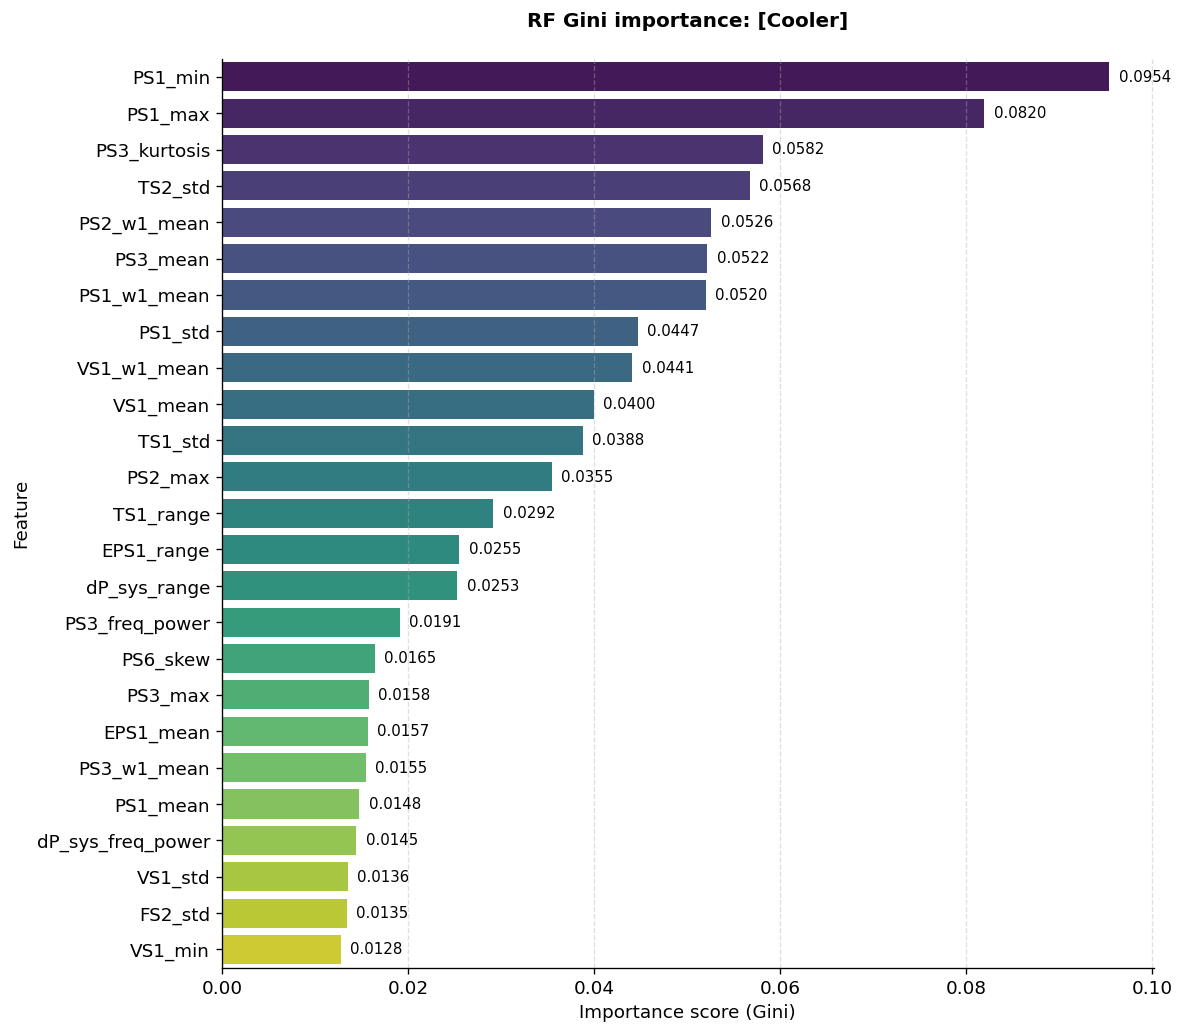

  Tuning RF for [Cooler]...
    Best: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}  CV F1: 0.9963

────────────────────  [Cooler] ────────────────────
  LDA             CV: 0.9944±0.0035  Test F1: 1.0000  BalAcc: 1.0000
  RandomForest    CV: 0.9944±0.0034  Test F1: 1.0000  BalAcc: 1.0000
  XGBoost         CV: 0.9965±0.0029  Test F1: 1.0000  BalAcc: 1.0000
  SVM             CV: 0.9969±0.0025  Test F1: 1.0000  BalAcc: 1.0000
  AdaBoost        CV: 0.9965±0.0015  Test F1: 1.0000  BalAcc: 1.0000

  Classification report (LDA):
              precision    recall  f1-score   support

         100       1.00      1.00      1.00       541

    accuracy                           1.00       541
   macro avg       1.00      1.00      1.00       541
weighted avg       1.00      1.00      1.00       541


  Target: [Valve]  |  Block split at cycle 1664
  Train: 1664 cycles  |  Test: 541 cycles

  Class                              Train     Test
  Near failu

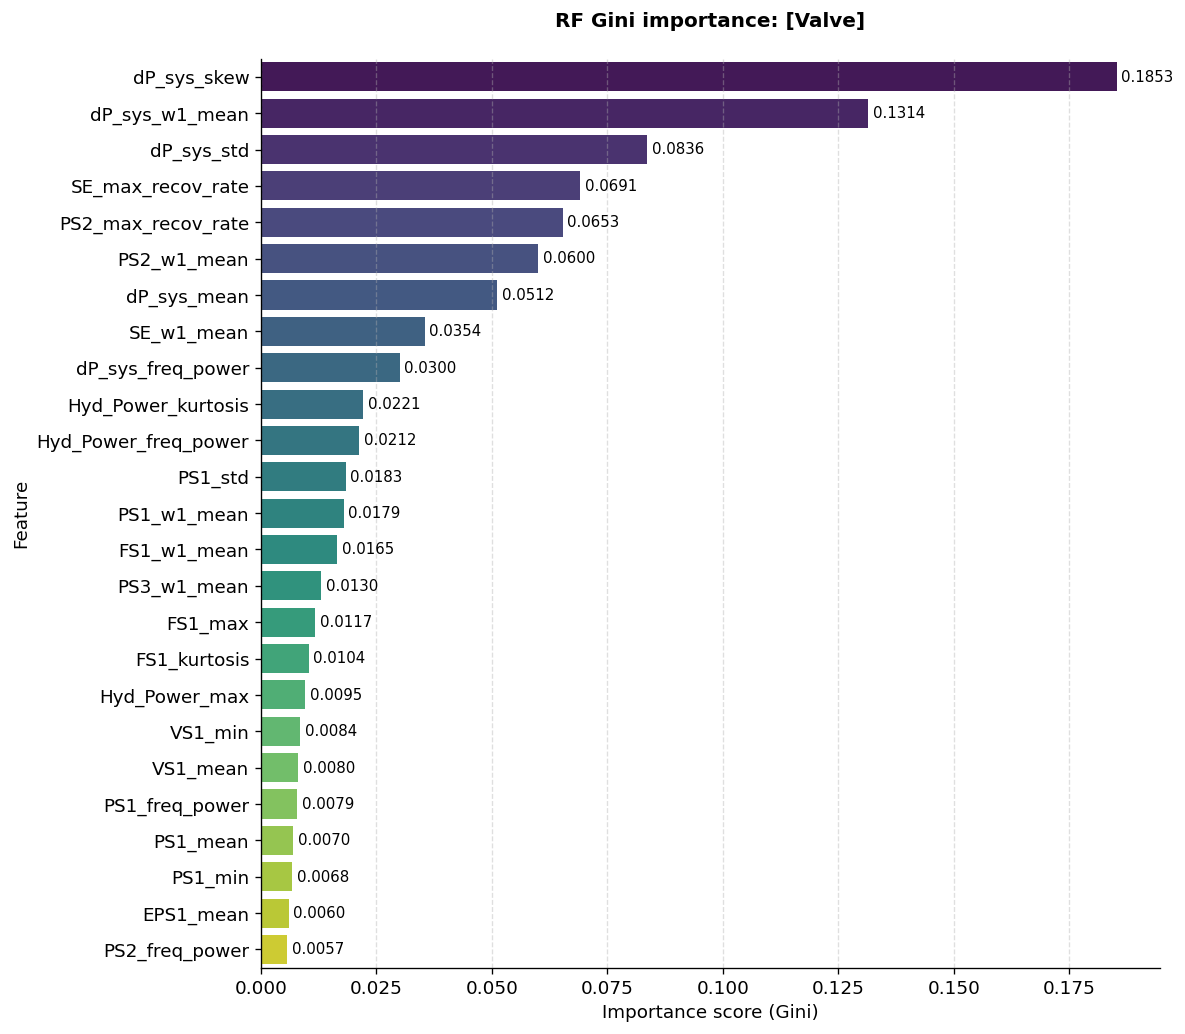

  Tuning RF for [Valve]...
    Best: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}  CV F1: 0.9973

────────────────────  [Valve] ────────────────────
  LDA             CV: 1.0000±0.0000  Test F1: 1.0000  BalAcc: 1.0000
  RandomForest    CV: 0.9962±0.0020  Test F1: 1.0000  BalAcc: 1.0000
  XGBoost         CV: 0.9941±0.0013  Test F1: 1.0000  BalAcc: 1.0000
  SVM             CV: 0.9918±0.0061  Test F1: 0.9983  BalAcc: 0.9979
  AdaBoost        CV: 0.7940±0.1648  Test F1: 0.6667  BalAcc: 0.7500

  Classification report (LDA):
              precision    recall  f1-score   support

          73       1.00      1.00      1.00       120
          80       1.00      1.00      1.00       120
          90       1.00      1.00      1.00       120
         100       1.00      1.00      1.00       181

    accuracy                           1.00       541
   macro avg       1.00      1.00      1.00       541
weighted avg       1.00      1.00      1.00       541

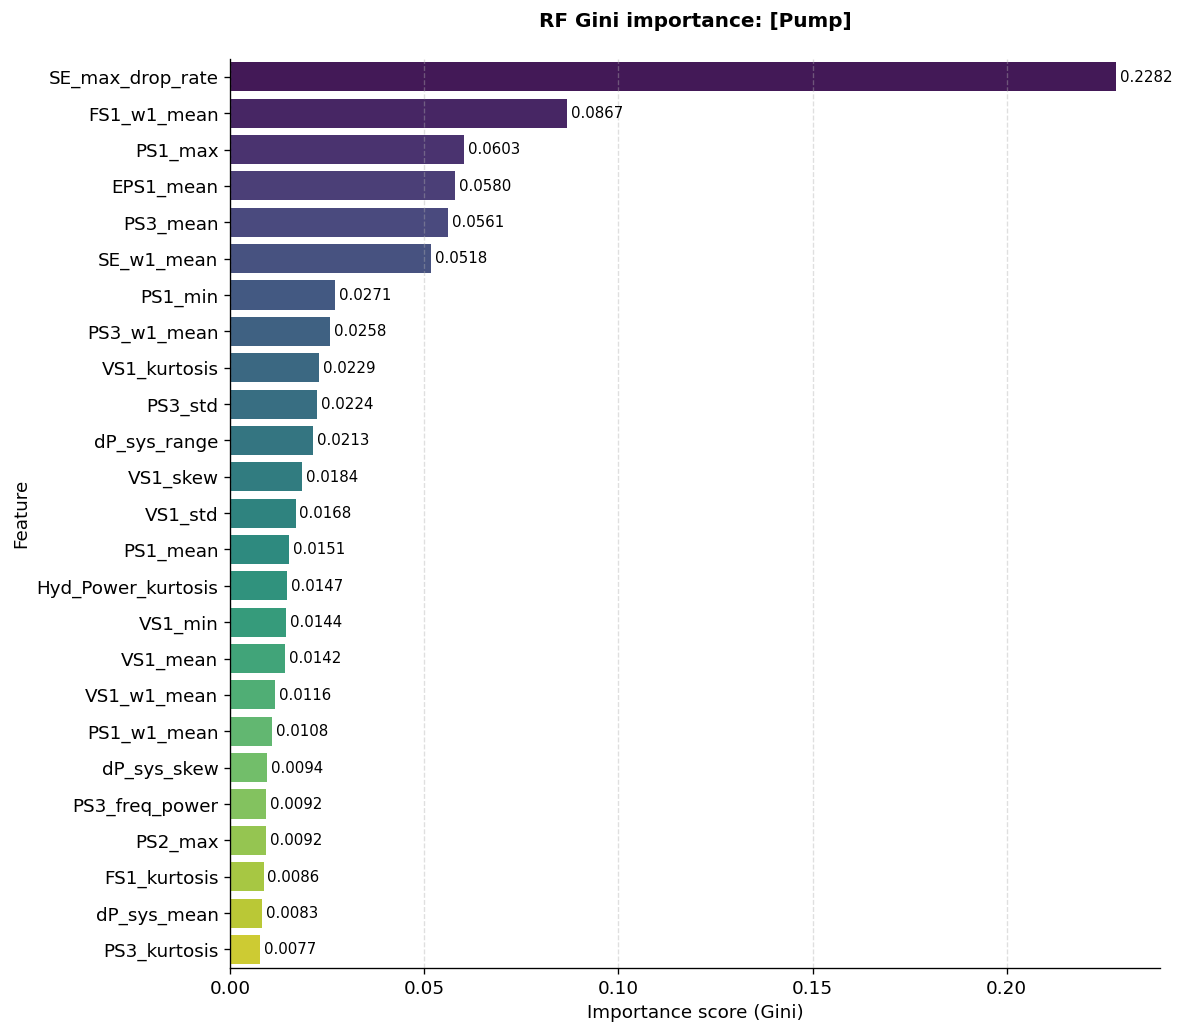

  Tuning RF for [Pump]...
    Best: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}  CV F1: 0.9885

────────────────────  [Pump] ────────────────────
  LDA             CV: 0.9946±0.0031  Test F1: 0.9980  BalAcc: 0.9980
  RandomForest    CV: 0.9888±0.0062  Test F1: 0.1883  BalAcc: 0.3333
  XGBoost         CV: 0.9803±0.0063  Test F1: 0.6613  BalAcc: 0.7078
  SVM             CV: 0.9861±0.0050  Test F1: 0.1972  BalAcc: 0.3333
  AdaBoost        CV: 0.9787±0.0073  Test F1: 0.5159  BalAcc: 0.6177

  Classification report (LDA):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       213
           1       0.99      1.00      1.00       164
           2       1.00      0.99      1.00       164

    accuracy                           1.00       541
   macro avg       1.00      1.00      1.00       541
weighted avg       1.00      1.00      1.00       541


  Target: [Accumulator]  |  Block split at cycle 1664

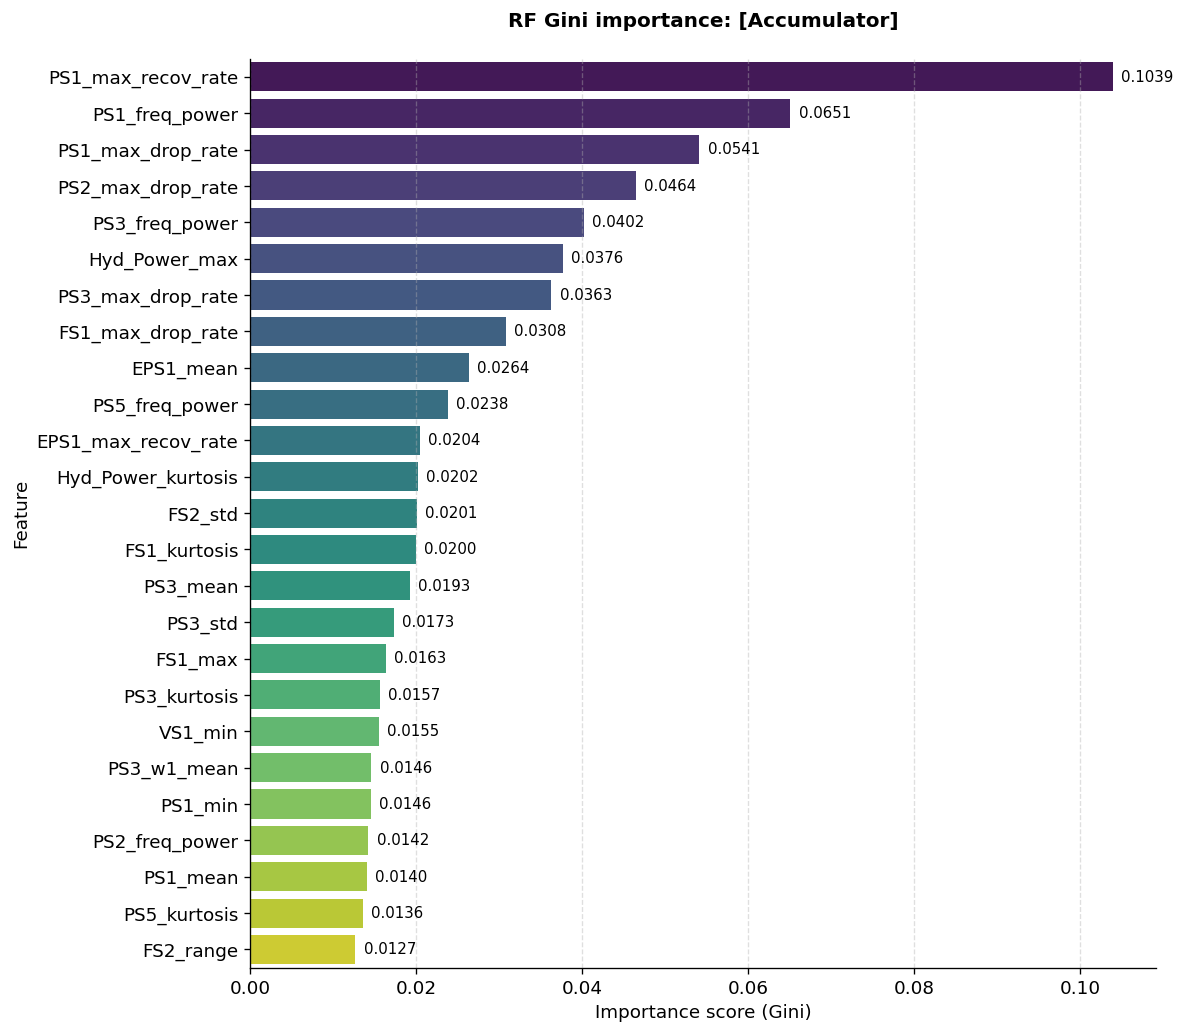

  Tuning RF for [Accumulator]...
    Best: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}  CV F1: 0.9761

────────────────────  [Accumulator] ────────────────────
  LDA             CV: 0.8916±0.0186  Test F1: 0.3729  BalAcc: 0.4266
  RandomForest    CV: 0.9775±0.0114  Test F1: 0.5406  BalAcc: 0.6167
  XGBoost         CV: 0.9767±0.0038  Test F1: 0.6433  BalAcc: 0.6907
  SVM             CV: 0.9765±0.0045  Test F1: 0.3612  BalAcc: 0.4443
  AdaBoost        CV: 0.8766±0.0364  Test F1: 0.5313  BalAcc: 0.5866

  Classification report (XGBoost):
              precision    recall  f1-score   support

          90       0.93      0.95      0.94       142
         100       0.87      0.80      0.84       133
         115       0.48      0.91      0.63       133
         130       0.68      0.10      0.17       133

    accuracy                           0.70       541
   macro avg       0.74      0.69      0.64       541
weighted avg       0.74      0.70    

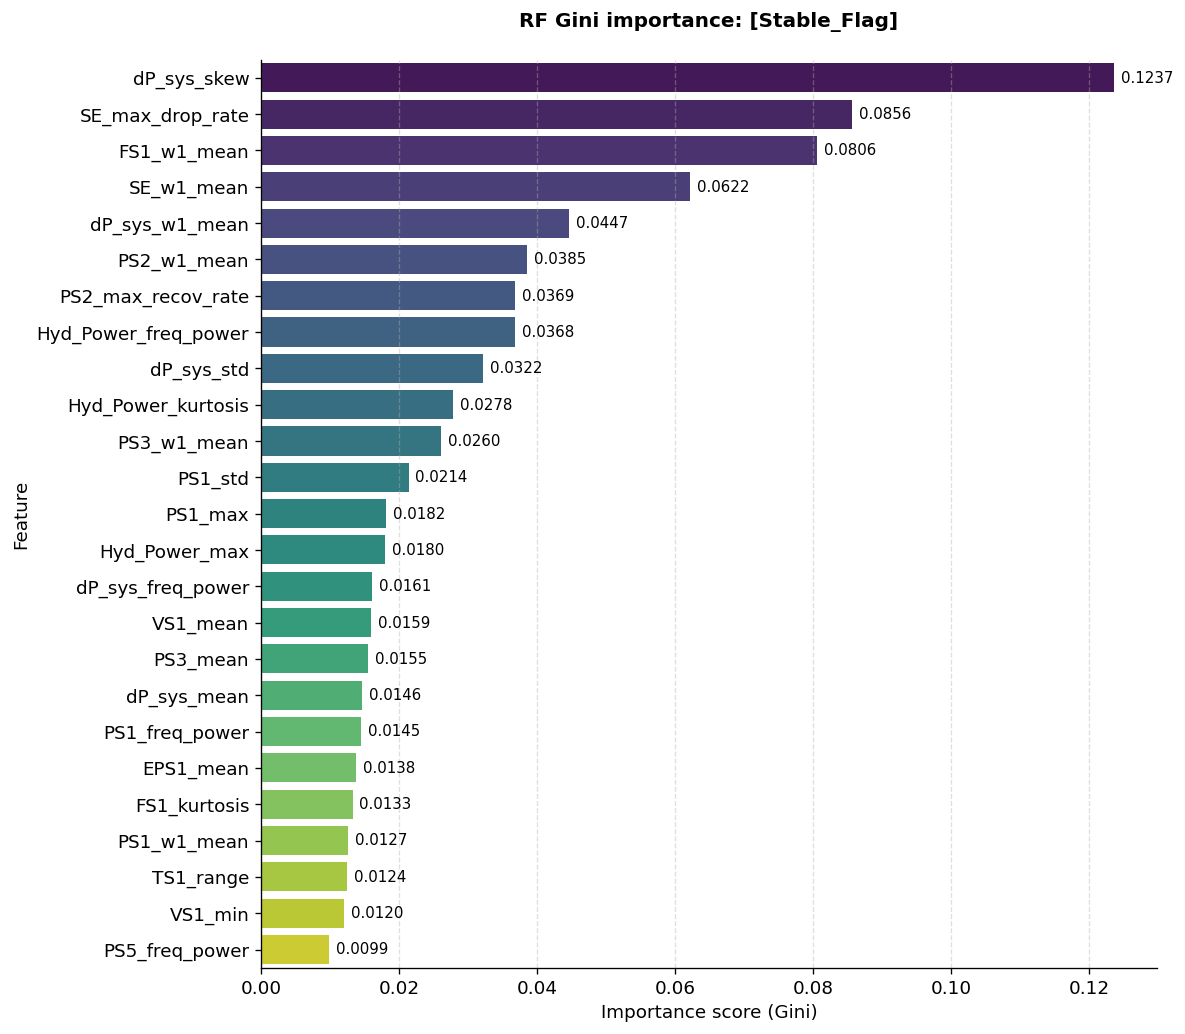

  Tuning RF for [Stable_Flag]...
    Best: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}  CV F1: 0.9759

────────────────────  [Stable_Flag] ────────────────────
  LDA             CV: 0.9466±0.0150  Test F1: 0.8348  BalAcc: 0.8783
  RandomForest    CV: 0.9759±0.0053  Test F1: 0.6974  BalAcc: 0.8609
  XGBoost         CV: 0.9803±0.0031  Test F1: 0.8077  BalAcc: 0.9165
  SVM             CV: 0.9723±0.0043  Test F1: 0.8019  BalAcc: 0.7308
  AdaBoost        CV: 0.9747±0.0031  Test F1: 0.7192  BalAcc: 0.8646

  Classification report (LDA):
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       489
           1       0.63      0.81      0.71        52

    accuracy                           0.94       541
   macro avg       0.80      0.88      0.83       541
weighted avg       0.95      0.94      0.94       541


Target Component: Cooler
       Model    CV_F1  CV_F1_std  Test_F1  Test_Acc  Test_Bal_Acc
  

In [38]:
#  Strategy 2: Block split - full 5-model evaluation

# Purpose: deployment simulation - the only results used for reporting.
# Trained on cycles < 1664, tested on cycles >= 1664.

print("" + "=" * 60)
print("  STRATEGY 2: BLOCK SPLIT (deployment simulation)")
print("  These are the REPORTED results")
print("=" * 60)

block_results   = []
model_storage   = {}
tuned_rf_params = {}

for target in TARGETS:
    X_tr, X_te, y_tr, y_te, le, sc, feats = prepare_block_split(
        target, features_df, labels,
        split_cycle=optimal_split_index, max_features=25)

    tuned_rf, params = tune_random_forest(X_tr, y_tr, target)
    tuned_rf_params[target] = params

    batch, trained = evaluate_all_models(target, X_tr, X_te, y_tr, y_te, le)
    trained['RandomForest_tuned'] = tuned_rf

    block_results.extend(batch)
    model_storage[target] = {
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_tr, 'y_test': y_te,
        'le': le, 'scaler': sc,
        'selected_features': feats,
        'clfs': trained,
    }

results_df = pd.DataFrame(block_results)
for target in TARGETS:
    print(f"\nTarget Component: {target}")
    summary = results_df[results_df['Target'] == target].sort_values('Test_F1', ascending=False)
    print(summary.drop(columns=['Target']).to_string(index=False))

### **Model Selection**

In [39]:
# It shows all model scores and explains which is truly best per target

print("\n" + "=" * 75)
print("  BLOCK SPLIT - FULL RESULTS TABLE")
print("  Primary metric: Balanced Accuracy (handles missing classes correctly)")
print("  Note: When test set has only 1 class, all models score F1=1.0 - use")
print("  Balanced Accuracy or look at Random split to differentiate models.")
print("=" * 75)

for target in results_df['Target'].unique():
    sub = (results_df[results_df['Target'] == target]
           .sort_values(['Test_Bal_Acc', 'Test_F1'], ascending=False))

    # Check if test set has only 1 class (trivial case)
    n_classes_test = results_df[
        results_df['Target'] == target
    ]['Test_F1'].nunique()

    test_classes = model_storage[target]['y_test'].nunique()
    trivial = test_classes <= 1

    print(f"\n  [{target}]  -  classes in test set: {test_classes}"
          + ("  <- TRIVIAL (1 class only)" if trivial else ""))
    print(f"  {'Model':<22} {'Test F1':>9} {'Bal.Acc':>10} {'CV F1':>9}  {'Best?':>6}")
    print(f"  {'-'*60}")

    best_bal = sub.iloc[0]['Model']
    for _, row in sub.iterrows():
        is_best = "  yes" if row['Model'] == best_bal else ""
        print(f"  {row['Model']:<22} {row['Test_F1']:>9.4f} "
              f"{row['Test_Bal_Acc']:>10.4f} {row['CV_F1']:>9.4f}{is_best}")

    if trivial:
        print(f"  -> All models tie on F1. Use Random split CV F1 to rank.")
        # Show random split ranking for this target
        if 'random_results_df' in dir():
            rand_sub = (random_results_df[random_results_df['Target'] == target]
                        .sort_values(['Test_Bal_Acc','Test_F1'], ascending=False))
            print(f"  -> Random split ranking:")
            for _, row in rand_sub.iterrows():
                print(f"     {row['Model']:<22} Random F1: {row['Test_F1']:.4f}  "
                      f"CV F1: {row['CV_F1']:.4f}")



  BLOCK SPLIT - FULL RESULTS TABLE
  Primary metric: Balanced Accuracy (handles missing classes correctly)
  Note: When test set has only 1 class, all models score F1=1.0 - use
  Balanced Accuracy or look at Random split to differentiate models.

  [Cooler]  -  classes in test set: 1  <- TRIVIAL (1 class only)
  Model                    Test F1    Bal.Acc     CV F1   Best?
  ------------------------------------------------------------
  LDA                       1.0000     1.0000    0.9944  yes
  RandomForest              1.0000     1.0000    0.9944
  XGBoost                   1.0000     1.0000    0.9965
  SVM                       1.0000     1.0000    0.9969
  AdaBoost                  1.0000     1.0000    0.9965
  -> All models tie on F1. Use Random split CV F1 to rank.
  -> Random split ranking:
     RandomForest           Random F1: 1.0000  CV F1: 0.9966
     AdaBoost               Random F1: 1.0000  CV F1: 0.9977
     XGBoost                Random F1: 0.9977  CV F1: 0.9977
     S

In [40]:
BENCHMARKS = {
    'Cooler':      {'Helwig_LDA': 1.000, 'Alenany_RF': 0.998, 'AlKhulaqi_RF': 1.000},
    'Valve':       {'Helwig_LDA': 1.000, 'Alenany_RF': 0.996, 'AlKhulaqi_RF': 0.959},
    'Pump':        {'Helwig_LDA': 0.979, 'Alenany_RF': 0.994, 'AlKhulaqi_RF': 0.996},
    'Accumulator': {'Helwig_LDA': 0.904, 'Alenany_RF': 0.992, 'AlKhulaqi_RF': 0.975},
    'Stable_Flag': {'AlKhulaqi_RF': 0.970},
}

print("\n" + "=" * 75)
print("  GRAND LEADERBOARD - Block split vs Random split")
print("  Reported results = Block split only")
print("=" * 75)
for target in results_df['Target'].unique():
    sub = (results_df[results_df['Target'] == target]
           .sort_values('Test_F1', ascending=False))

    print(f"\n  [{target}]")
    print(f"  {'Model':<20} {'CV F1':>8} {'Block F1':>10} {'Random F1':>11} {'Bal.Acc':>9}")
    print(f"  {'-'*62}")
    for _, row in sub.iterrows():
        rand_row = random_results_df[
            (random_results_df['Target'] == target) &
            (random_results_df['Model']  == row['Model'])
        ]
        rand_f1  = rand_row['Test_F1'].values[0] if len(rand_row) > 0 else float('nan')
        rand_str = f"{rand_f1:>11.4f}" if not np.isnan(rand_f1) else f"{'N/A':>11}"
        print(f"  {row['Model']:<20} {row['CV_F1']:>8.4f} "
              f"{row['Test_F1']:>10.4f} {rand_str} {row['Test_Bal_Acc']:>9.4f}")
    best_f1 = sub['Test_F1'].max()
    for ref, val in BENCHMARKS.get(target, {}).items():
        diff = best_f1 - val
        print(f"    vs {ref}: {val:.3f}  {'▲' if diff>=0 else '▼'} {abs(diff):.3f}")



  GRAND LEADERBOARD - Block split vs Random split
  Reported results = Block split only

  [Cooler]
  Model                   CV F1   Block F1   Random F1   Bal.Acc
  --------------------------------------------------------------
  LDA                    0.9944     1.0000      0.9955    1.0000
  RandomForest           0.9944     1.0000      1.0000    1.0000
  XGBoost                0.9965     1.0000      0.9977    1.0000
  SVM                    0.9969     1.0000      0.9977    1.0000
  AdaBoost               0.9965     1.0000      1.0000    1.0000
    vs Helwig_LDA: 1.000  ▲ 0.000
    vs Alenany_RF: 0.998  ▲ 0.002
    vs AlKhulaqi_RF: 1.000  ▲ 0.000

  [Valve]
  Model                   CV F1   Block F1   Random F1   Bal.Acc
  --------------------------------------------------------------
  LDA                    1.0000     1.0000      0.9977    1.0000
  RandomForest           0.9962     1.0000      0.9931    1.0000
  XGBoost                0.9941     1.0000      0.9861    1.0000
  SV

# **Section 8 - EVALUATION & ERROR ANALYSIS**

## **8.1. Confusion Matrices**

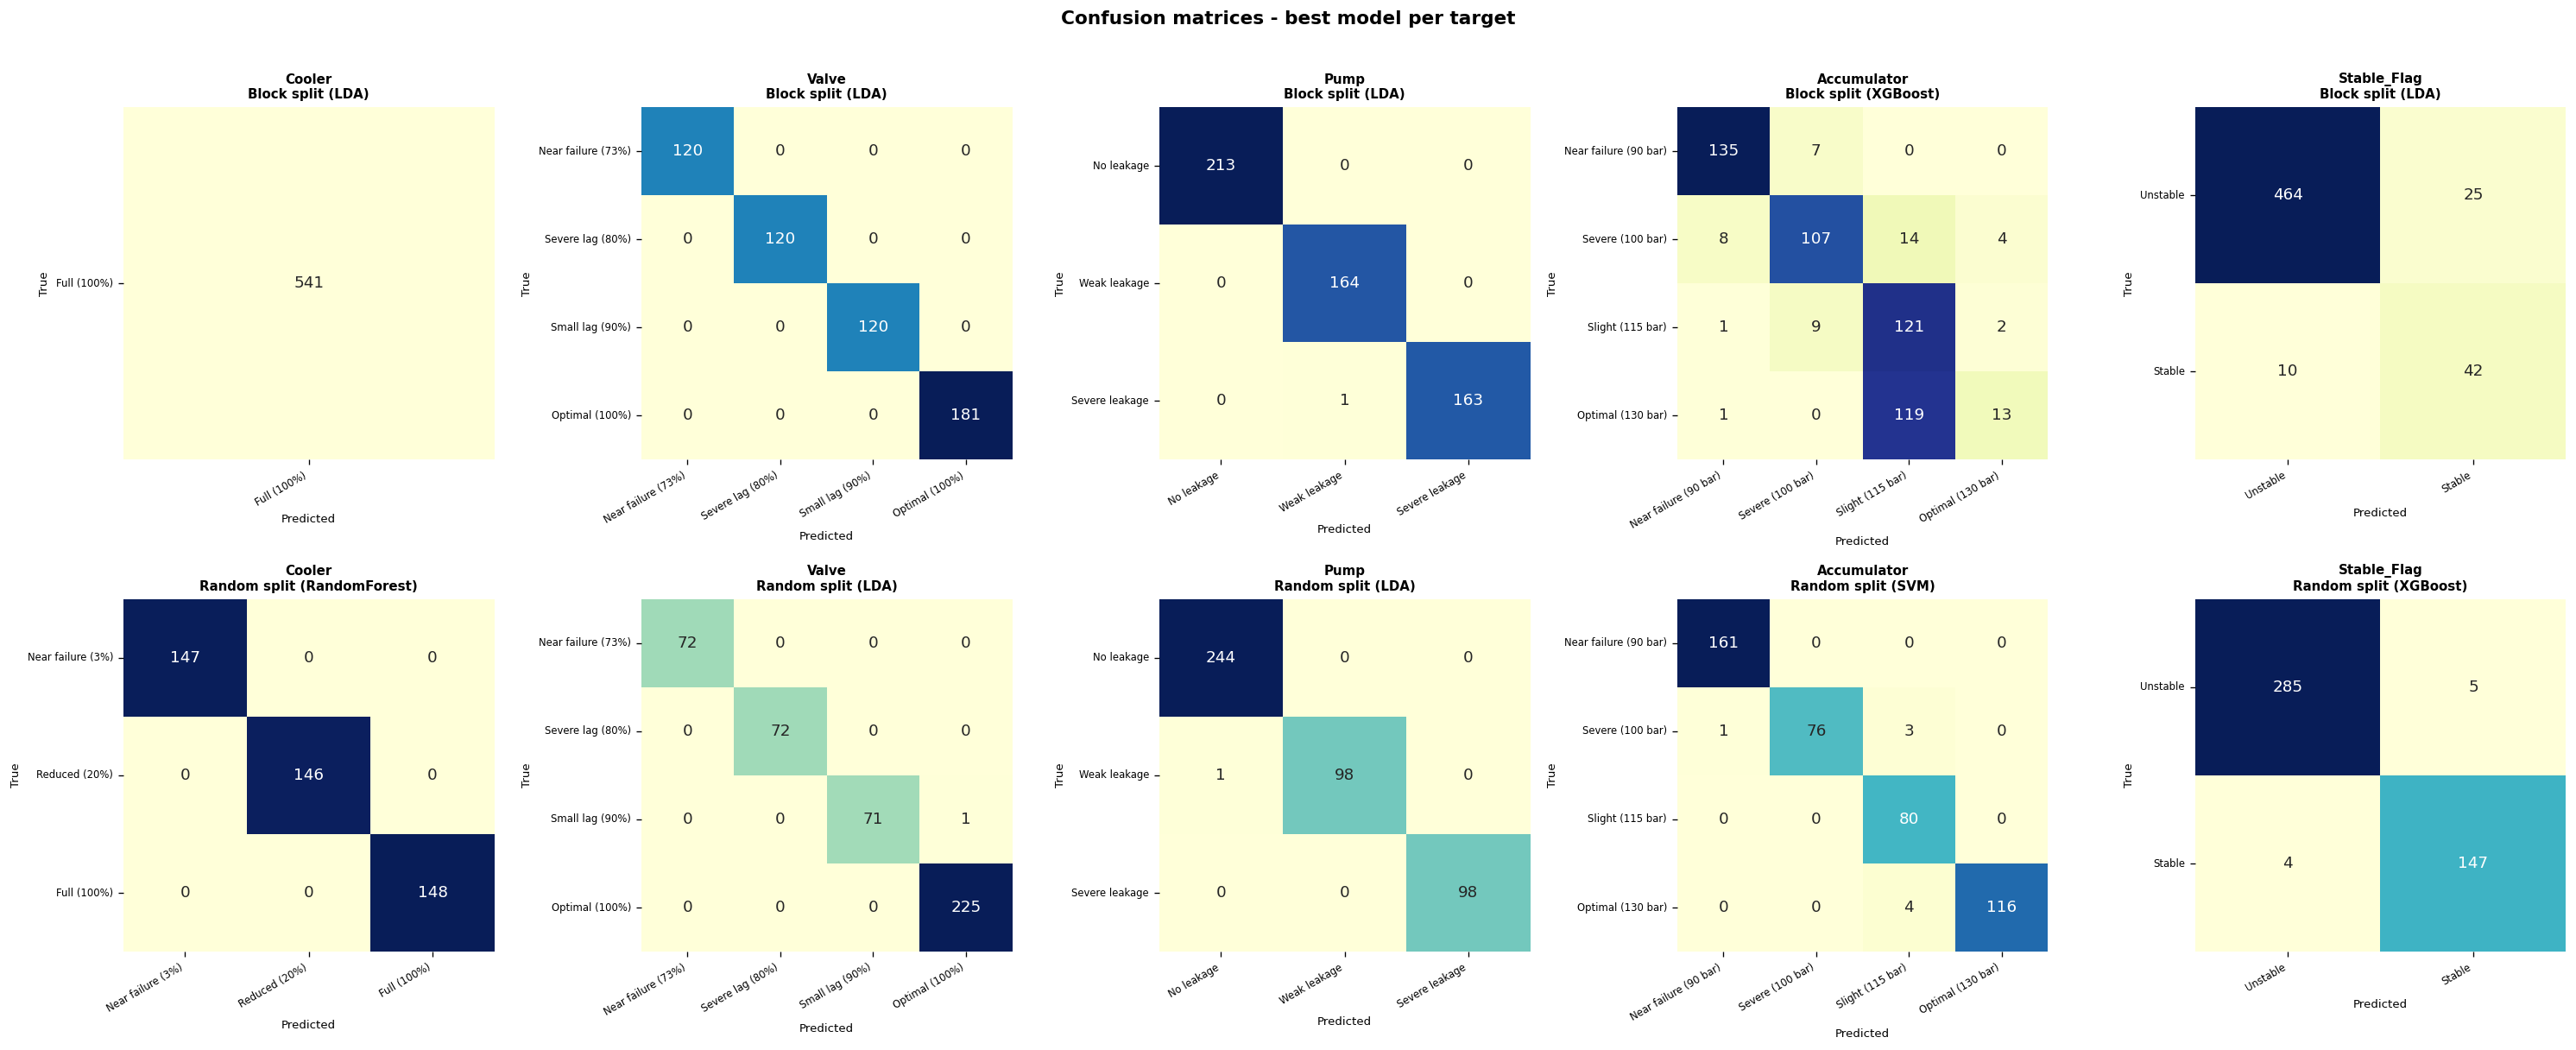

In [41]:
def plot_confusion_matrices(results_df, model_storage, random_storage=None):
    """
    Plots confusion matrices for block split (reported) and optionally
    random split (validation) side by side per target.

    Block split matrices may show fewer rows/columns than expected -
    this is because some fault classes only appear in specific
    experimental periods and are absent from the test block.
    This is a dataset characteristic, not a model failure
    (Helwig et al., 2015; Chen et al., 2025).
    """
    targets = list(model_storage.keys())
    n_cols  = len(targets)
    n_rows  = 2 if random_storage else 1
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 5 * n_rows))
    # Normalise axes shape so axes[row][col] always works
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [list(axes)]
    elif n_cols == 1:
        axes = [[r] for r in axes]

    def _draw_cm(ax, storage, res_df, target, title_suffix):
        best_name = (res_df[res_df['Target'] == target]
                     .sort_values('Test_F1', ascending=False)
                     .iloc[0]['Model'])
        store  = storage[target]
        clf    = store['clfs'][best_name]
        le     = store['le']
        lmap   = LABEL_MAPS.get(target, {})
        y_test = store['y_test']
        y_pred = clf.predict(store['X_test'])

        # Only classes present in this split's test set
        present = sorted(set(y_test.values) | set(y_pred))
        lbls    = [str(lmap.get(le.classes_[i], le.classes_[i]))
                   for i in present]
        cm      = confusion_matrix(y_test, y_pred, labels=present)

        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                    xticklabels=lbls, yticklabels=lbls,
                    ax=ax, cbar=False)
        ax.set_title(f"{target}\n{title_suffix} ({best_name})",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('True', fontsize=8)
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

    for i, target in enumerate(targets):
        _draw_cm(axes[0][i], model_storage, results_df,
                 target, 'Block split')
        if random_storage and target in random_storage:
            _draw_cm(axes[1][i], random_storage, random_results_df,
                     target, 'Random split')



    plt.suptitle('Confusion matrices - best model per target',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'Confusion_Matrices.png'),
                bbox_inches='tight')
    plt.show()


plot_confusion_matrices(results_df, model_storage, random_storage=random_storage)

## **8.2. Operational Consequences and Misclassification Analysis**

In [42]:
OPERATIONAL_CONSEQUENCES = {
    'Cooler': {
        ('Full (100%)',     'Reduced (20%)'):     'Cooler underperformance missed - overheating risk',
        ('Reduced (20%)',   'Near failure (3%)'): 'CRITICAL - near-failure missed; thermal damage risk',
        ('Near failure (3%)', 'Reduced (20%)'):   'Over-maintenance - unnecessary inspection',
    },
    'Valve': {
        ('Optimal (100%)',  'Small lag (90%)'):   'Minor degradation missed - low risk',
        ('Severe lag (80%)','Near failure (73%)'): 'CRITICAL - near-failure missed; control loss risk',
        ('Near failure (73%)', 'Severe lag (80%)'): 'Over-maintenance',
    },
    'Pump': {
        ('No leakage',    'Weak leakage'):    'False alarm - unnecessary inspection',
        ('Weak leakage',  'Severe leakage'):  'CRITICAL - severity underestimated',
        ('Severe leakage','Weak leakage'):    'CRITICAL - severe leakage missed; pressure loss risk',
    },
    'Accumulator': {
        ('Optimal (130 bar)', 'Slight (115 bar)'): 'Minor drop missed - low risk',
        ('Severe (100 bar)',  'Near failure (90 bar)'): 'CRITICAL - near-failure missed',
        ('Near failure (90 bar)', 'Severe (100 bar)'): 'Severity underestimated',
    },
    'Stable_Flag': {
        ('Unstable', 'Stable'):   'CRITICAL - unstable cycle predicted stable; downstream component predictions unreliable',
        ('Stable',   'Unstable'): 'False alarm - stable cycle flagged as unstable; predictions discarded unnecessarily',
    },
}


  [Cooler] - perfect classification.

  [Valve] - perfect classification.

────────────────────────────────────────────────────────────
  [Pump] errors: 1/541 (0.2%)  model: LDA

  True: Severe leakage
  Pred: Weak leakage  (1 cycles, 0.2%)
  Consequence: CRITICAL - severe leakage missed; pressure loss risk


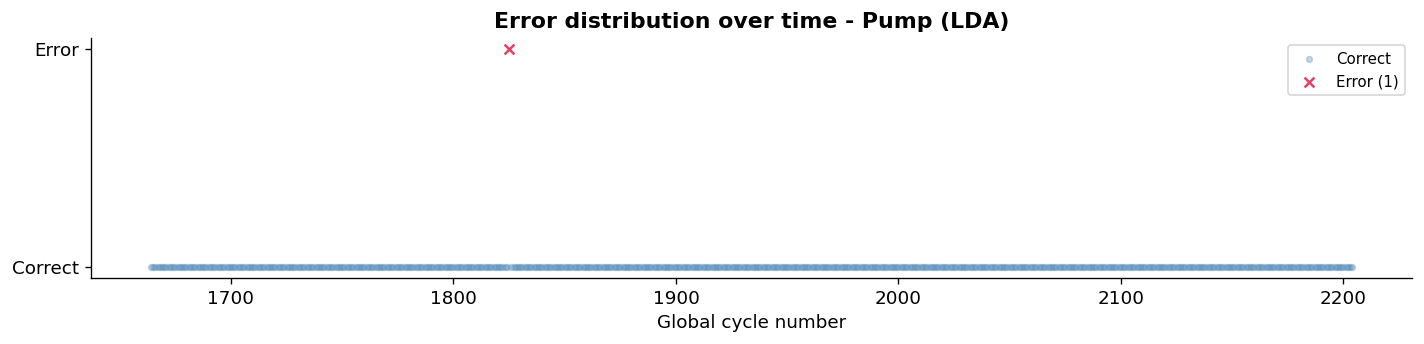


────────────────────────────────────────────────────────────
  [Accumulator] errors: 165/541 (30.5%)  model: XGBoost

  True: Optimal (130 bar)
  Pred: Slight (115 bar)  (119 cycles, 22.0%)
  Consequence: Minor drop missed - low risk

  True: Severe (100 bar)
  Pred: Slight (115 bar)  (14 cycles, 2.6%)
  Consequence: Review required

  True: Slight (115 bar)
  Pred: Severe (100 bar)  (9 cycles, 1.7%)
  Consequence: Review required

  True: Severe (100 bar)
  Pred: Near failure (90 bar)  (8 cycles, 1.5%)
  Consequence: CRITICAL - near-failure missed

  True: Near failure (90 bar)
  Pred: Severe (100 bar)  (7 cycles, 1.3%)
  Consequence: Severity underestimated

  True: Severe (100 bar)
  Pred: Optimal (130 bar)  (4 cycles, 0.7%)
  Consequence: Review required

  True: Slight (115 bar)
  Pred: Optimal (130 bar)  (2 cycles, 0.4%)
  Consequence: Review required

  True: Optimal (130 bar)
  Pred: Near failure (90 bar)  (1 cycles, 0.2%)
  Consequence: Review required

  True: Slight (115 ba

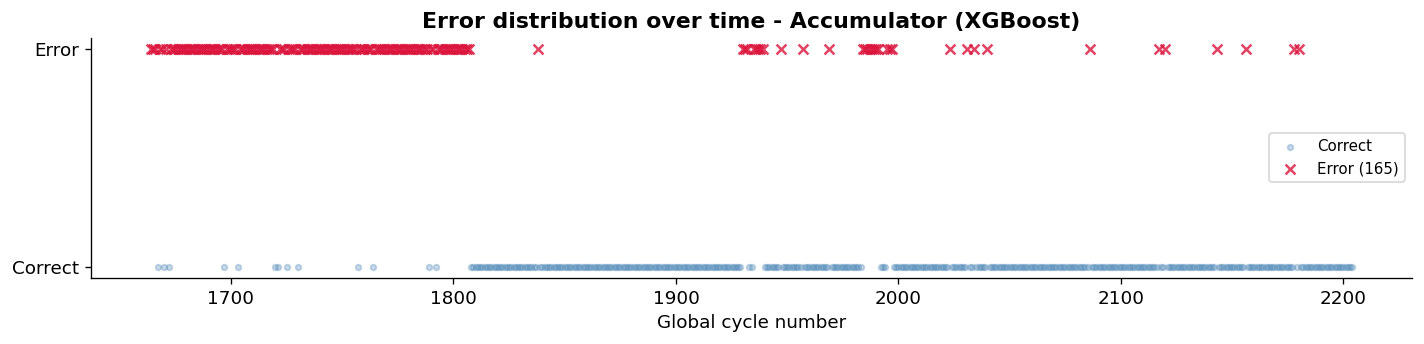


────────────────────────────────────────────────────────────
  [Stable_Flag] errors: 48/541 (8.9%)  model: XGBoost

  True: Unstable
  Pred: Stable  (44 cycles, 8.1%)
  Consequence: CRITICAL - unstable cycle predicted stable; downstream component predictions unreliable

  True: Stable
  Pred: Unstable  (4 cycles, 0.7%)
  Consequence: False alarm - stable cycle flagged as unstable; predictions discarded unnecessarily


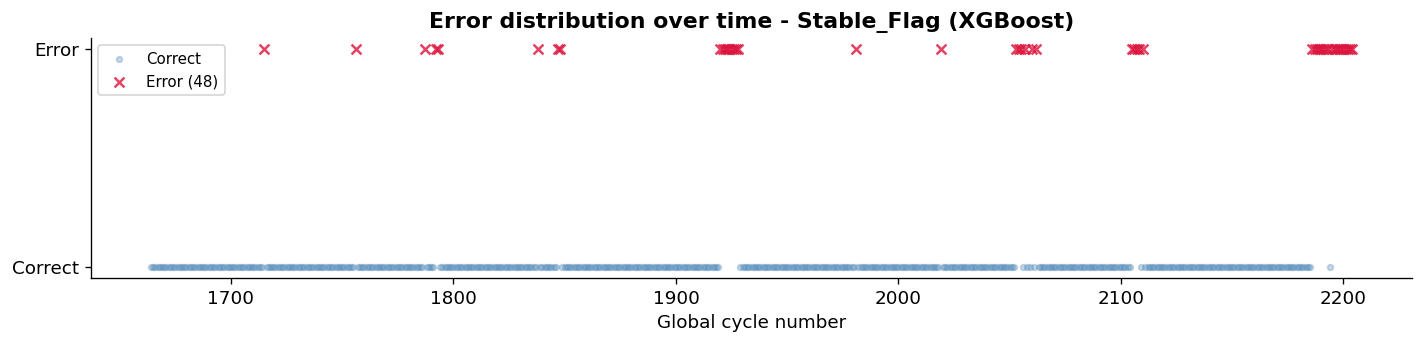

In [43]:
def analyse_misclassifications(target, model_storage, results_df):
    store     = model_storage[target]
    best_name = (results_df[results_df['Target'] == target]
                 .sort_values('Test_Bal_Acc', ascending=False).iloc[0]['Model'])
    clf   = store['clfs'][best_name]
    le    = store['le']
    lmap  = LABEL_MAPS.get(target, {})
    y_pred = clf.predict(store['X_test'])
    y_test = store['y_test']

    df = pd.DataFrame({
        'cycle':      store['X_test'].index,
        'true_enc':   y_test.values,
        'pred_enc':   y_pred,
        'is_error':   y_test.values != y_pred,
    })
    df['true_label'] = [str(lmap.get(le.classes_[i], le.classes_[i]))
                        for i in df['true_enc']]
    df['pred_label'] = [str(lmap.get(le.classes_[i], le.classes_[i]))
                        for i in df['pred_enc']]

    wrong = df[df['is_error']]
    if len(wrong) == 0:
        print(f"\n  [{target}] - perfect classification.")
        return

    print(f"\n{'─'*60}")
    print(f"  [{target}] errors: {len(wrong)}/{len(df)} "
          f"({len(wrong)/len(df)*100:.1f}%)  model: {best_name}")
    pairs = (wrong.groupby(['true_label', 'pred_label']).size()
             .reset_index(name='count')
             .sort_values('count', ascending=False))
    for _, row in pairs.iterrows():
        key    = (row['true_label'], row['pred_label'])
        conseq = OPERATIONAL_CONSEQUENCES.get(target, {}).get(
            key, 'Review required')
        pct = row['count'] / len(df) * 100
        print(f"\n  True: {row['true_label']}")
        print(f"  Pred: {row['pred_label']}  "
              f"({row['count']} cycles, {pct:.1f}%)")
        print(f"  Consequence: {conseq}")

    # Timeline plot
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.scatter(df.loc[~df['is_error'], 'cycle'],
               [0] * (~df['is_error']).sum(),
               color='steelblue', s=12, alpha=0.3, label='Correct')
    ax.scatter(wrong['cycle'], [1] * len(wrong),
               color='crimson', marker='x', s=35, alpha=0.8,
               label=f'Error ({len(wrong)})')
    ax.set_title(f'Error distribution over time - {target} ({best_name})',
                 fontweight='bold')
    ax.set_xlabel('Global cycle number')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Correct', 'Error'])
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH,
                             f'Error_Timeline_{target}.png'),
                bbox_inches='tight')
    plt.show()


for target in model_storage:
    analyse_misclassifications(target, model_storage, results_df)

Pump misclassifications are operationally critical - any predicted leakage is flagged regardless of confidence given aerospace safety constraints. Accumulator errors concentrate between adjacent pressure levels, consistent with the gradual degradation pattern observed in EDA.

# **Section 9 - CONFIDENCE & UNCERTAINTY ANALYSIS**

Rivas et al. (2022) demonstrate that for PHM, the uncertainty
of a prediction is as critical as the prediction itself. In their
Bayesian Neural Network framework, maintenance scheduling uses
the lower confidence bound rather than the point estimate - this
ensures maintenance is performed before failure even when the
model is uncertain.

We implement a practical equivalent using `predict_proba` from
RF and SVM. Cycles where the highest class probability falls
below 0.70 are flagged for human review rather than automated
action. This directly implements the PHM pipeline recommended
for the BAE Systems use case.


  [Cooler] - model: RandomForest
  High-conf (511 cycles): error 0.0%
  Low-conf  (30 cycles): error 0.0%
  Flagged for review: 30/541 (5.5%)


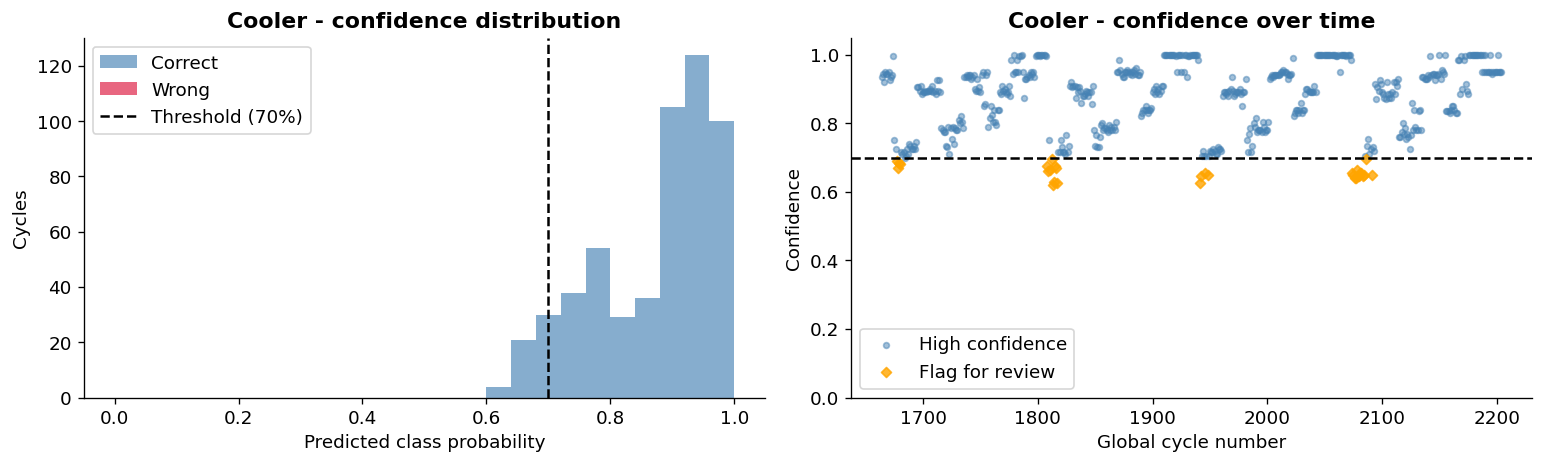


  [Valve] - model: RandomForest
  High-conf (224 cycles): error 0.0%
  Low-conf  (317 cycles): error 0.0%
  Flagged for review: 317/541 (58.6%)


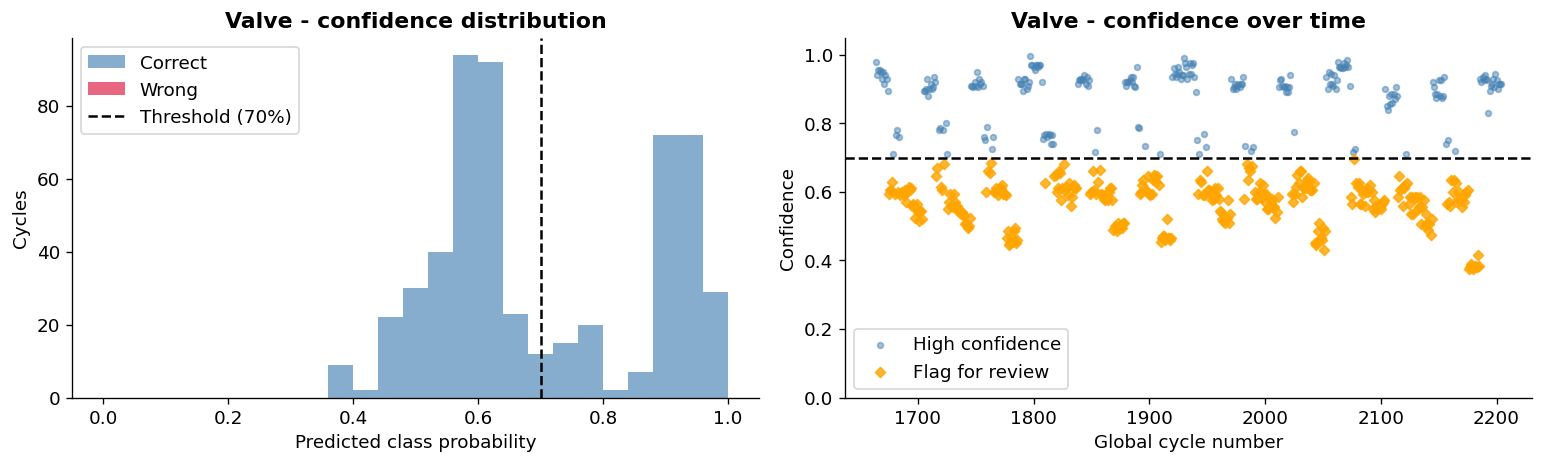


  [Pump] - model: RandomForest
  High-conf (271 cycles): error 21.4%
  Low-conf  (270 cycles): error 100.0%
  Flagged for review: 270/541 (49.9%)


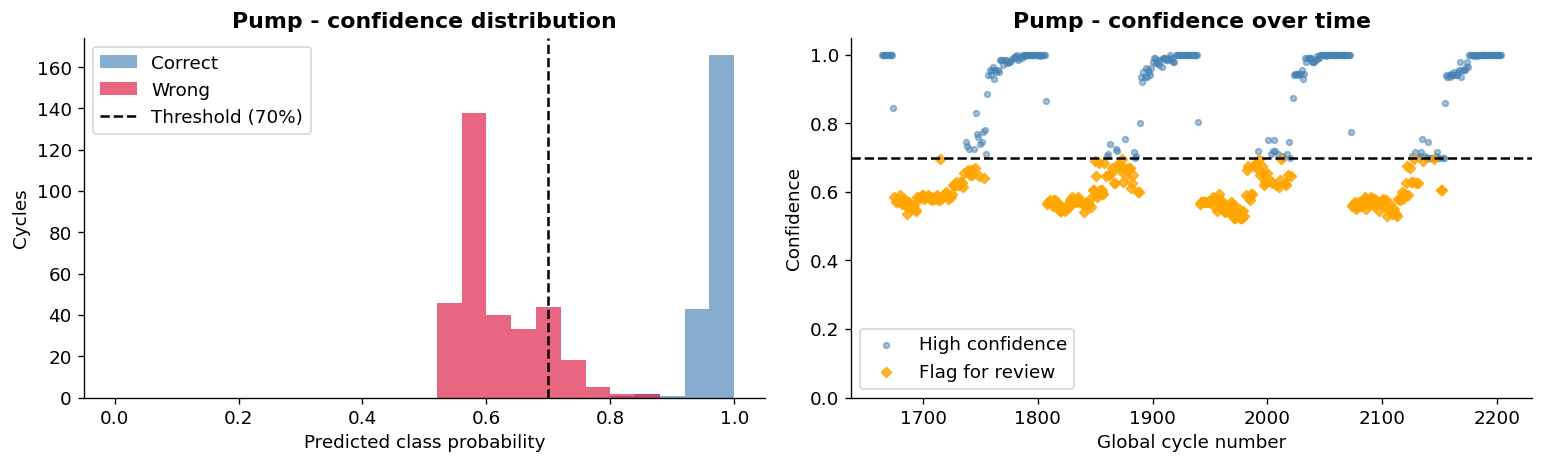


  [Accumulator] - model: RandomForest
  High-conf (74 cycles): error 4.1%
  Low-conf  (467 cycles): error 43.0%
  Flagged for review: 467/541 (86.3%)


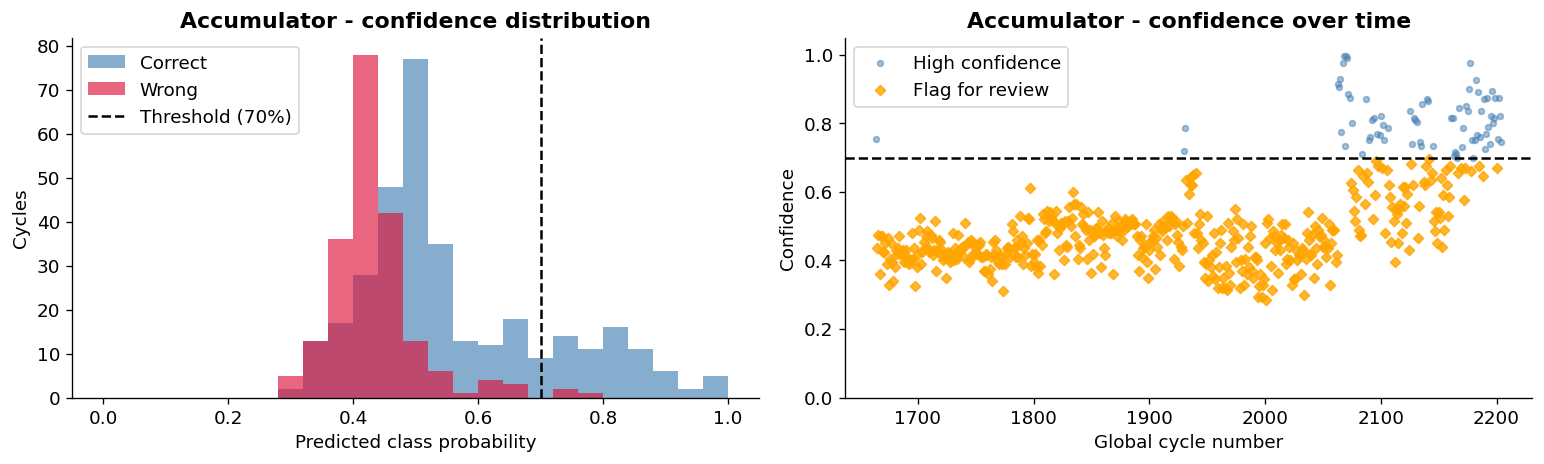


  [Stable_Flag] - model: RandomForest
  High-conf (316 cycles): error 4.4%
  Low-conf  (225 cycles): error 35.6%
  Flagged for review: 225/541 (41.6%)


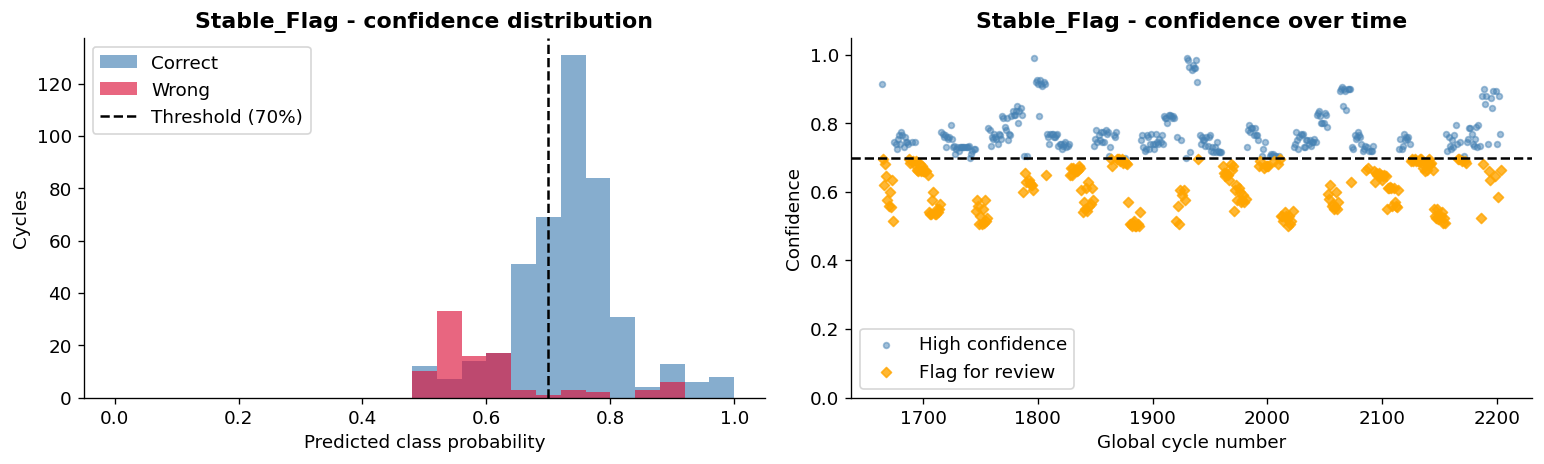


  Confidence summary:
     target        model  n_uncertain  n_total  pct_uncertain  hi_err_pct  lo_err_pct
     Cooler RandomForest           30      541            5.5         0.0         0.0
      Valve RandomForest          317      541           58.6         0.0         0.0
       Pump RandomForest          270      541           49.9        21.4       100.0
Accumulator RandomForest          467      541           86.3         4.1        43.0
Stable_Flag RandomForest          225      541           41.6         4.4        35.6


In [44]:
CONFIDENCE_THRESHOLD = 0.70
confidence_summary   = []


def confidence_analysis(target, model_storage, results_df,
                        threshold=CONFIDENCE_THRESHOLD):
    store = model_storage[target]
    le    = store['le']
    lmap  = LABEL_MAPS.get(target, {})

    ranked   = (results_df[results_df['Target'] == target]
                .sort_values('Test_Bal_Acc', ascending=False))
    prob_name = None
    for name in ranked['Model']:
        if name in ('RandomForest', 'SVM', 'RandomForest_tuned'):
            prob_name = name
            break
    if not prob_name:
        return None

    clf   = store['clfs'][prob_name]
    X_te  = store['X_test']
    y_te  = store['y_test']
    proba = clf.predict_proba(X_te)
    conf  = proba.max(axis=1)
    y_pred = clf.predict(X_te)
    correct = y_pred == y_te.values

    rdf = pd.DataFrame({
        'cycle':      X_te.index,
        'confidence': conf,
        'correct':    correct,
        'uncertain':  conf < threshold,
    })

    hi = rdf[~rdf['uncertain']]
    lo = rdf[rdf['uncertain']]
    hi_err = 1 - hi['correct'].mean() if len(hi) > 0 else np.nan
    lo_err = 1 - lo['correct'].mean() if len(lo) > 0 else np.nan

    n_unc = rdf['uncertain'].sum()
    print(f"\n  [{target}] - model: {prob_name}")
    print(f"  High-conf ({len(hi)} cycles): error {hi_err:.1%}")
    print(f"  Low-conf  ({len(lo)} cycles): error {lo_err:.1%}")
    print(f"  Flagged for review: {n_unc}/{len(rdf)} "
          f"({n_unc/len(rdf)*100:.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    bins = np.linspace(0, 1, 26)
    axes[0].hist(rdf.loc[rdf['correct'],  'confidence'],
                 bins=bins, alpha=0.65, label='Correct', color='steelblue')
    axes[0].hist(rdf.loc[~rdf['correct'], 'confidence'],
                 bins=bins, alpha=0.65, label='Wrong',   color='crimson')
    axes[0].axvline(threshold, color='black', ls='--', lw=1.5,
                    label=f'Threshold ({threshold:.0%})')
    axes[0].set_title(f'{target} - confidence distribution',
                      fontweight='bold')
    axes[0].set_xlabel('Predicted class probability')
    axes[0].set_ylabel('Cycles')
    axes[0].legend()

    axes[1].scatter(rdf.loc[~rdf['uncertain'], 'cycle'],
                    rdf.loc[~rdf['uncertain'], 'confidence'],
                    s=12, alpha=0.5, color='steelblue',
                    label='High confidence')
    axes[1].scatter(rdf.loc[rdf['uncertain'],  'cycle'],
                    rdf.loc[rdf['uncertain'],  'confidence'],
                    s=18, alpha=0.8, color='orange', marker='D',
                    label='Flag for review')
    axes[1].axhline(threshold, color='black', ls='--', lw=1.5)
    axes[1].set_title(f'{target} - confidence over time',
                      fontweight='bold')
    axes[1].set_xlabel('Global cycle number')
    axes[1].set_ylabel('Confidence')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH,
                             f'Confidence_{target}.png'),
                bbox_inches='tight')
    plt.show()

    return {
        'target':       target,
        'model':        prob_name,
        'n_uncertain':  int(n_unc),
        'n_total':      int(len(rdf)),
        'pct_uncertain': round(n_unc / len(rdf) * 100, 1),
        'hi_err_pct':   round(hi_err * 100, 1) if not np.isnan(hi_err) else None,
        'lo_err_pct':   round(lo_err * 100, 1) if not np.isnan(lo_err) else None,
    }


for target in model_storage:
    res = confidence_analysis(target, model_storage, results_df)
    if res:
        confidence_summary.append(res)

conf_df = pd.DataFrame(confidence_summary)
print("\n  Confidence summary:")
print(conf_df.to_string(index=False))

A 70% confidence threshold is applied uniformly. Accumulator shows the highest review rate (86.3%) - reflecting genuine model uncertainty due to class overlap. Valve shows a conservative 58.6% review rate. Components with low review rates (Cooler, Pump) are candidates for full automation in BAE Systems deployment.

# **Section 10 - RESULTS, SENSOR VALIDATION & BAE RECOMMENDATIONS**

## **10.1. Final Performance Summary**

In [45]:
# 10.1 Final summary
print("\n" + "=" * 70)
print("  FINAL PERFORMANCE SUMMARY")
print(f"  {'Target':<16} {'Best model':<22} {'Test F1':>8} "
      f"{'BalAcc':>8} {'Review%':>8}")
print(f"  {'-'*65}")
for target in results_df['Target'].unique():
    sub = (results_df[results_df['Target'] == target]
           .sort_values(['Test_Bal_Acc','Test_F1'], ascending=False).iloc[0])
    row = conf_df[conf_df['target'] == target] if len(conf_df) > 0 else []
    rev = f"{row.iloc[0]['pct_uncertain']:.1f}%" if len(row) > 0 else "N/A"
    print(f"  {target:<16} {sub['Model']:<22} {sub['Test_F1']:>8.4f} "
          f"{sub['Test_Bal_Acc']:>8.4f} {rev:>8}")


  FINAL PERFORMANCE SUMMARY
  Target           Best model              Test F1   BalAcc  Review%
  -----------------------------------------------------------------
  Cooler           LDA                      1.0000   1.0000     5.5%
  Valve            LDA                      1.0000   1.0000    58.6%
  Pump             LDA                      0.9980   0.9980    49.9%
  Accumulator      XGBoost                  0.6433   0.6907    86.3%
  Stable_Flag      XGBoost                  0.8077   0.9165    41.6%


## **10.2. Sensor Validation**

In [46]:
# 10.2 Sensor validation
LITERATURE_SENSORS = {
    'Cooler':      ['CE', 'CP', 'TS1', 'TS2', 'TS3', 'TS4', 'PS5', 'PS6'],
    'Valve':       ['PS3', 'PS2', 'PS1', 'FS1', 'EPS1'],
    'Pump':        ['FS1', 'SE', 'PS1', 'EPS1', 'PS3'],
    'Accumulator': ['PS3', 'PS1', 'SE', 'FS1', 'TS1', 'PS2'],
    'Stable_Flag': ['PS1', 'PS2', 'PS3', 'FS1', 'SE'],
}

print("\n" + "=" * 65)
print("  SENSOR VALIDATION vs Alenany et al. (2021)")
print("=" * 65)
for target, store in model_storage.items():
    our = set(f.split('_')[0] for f in store['selected_features'])
    lit = set(LITERATURE_SENSORS.get(target, []))
    overlap = our & lit
    pct = len(overlap) / len(lit) * 100 if lit else 0
    print(f"\n  [{target}]  overlap: {sorted(overlap)}  ({pct:.0f}% of lit.)")
    extra = our - lit
    if extra:
        print(f"    Our additions: {sorted(extra)} - may capture non-linear interactions")


  SENSOR VALIDATION vs Alenany et al. (2021)

  [Cooler]  overlap: ['PS6', 'TS1', 'TS2']  (38% of lit.)
    Our additions: ['EPS1', 'FS2', 'PS1', 'PS2', 'PS3', 'VS1', 'dP'] - may capture non-linear interactions

  [Valve]  overlap: ['EPS1', 'FS1', 'PS1', 'PS2', 'PS3']  (100% of lit.)
    Our additions: ['Hyd', 'SE', 'VS1', 'dP'] - may capture non-linear interactions

  [Pump]  overlap: ['EPS1', 'FS1', 'PS1', 'PS3', 'SE']  (100% of lit.)
    Our additions: ['Hyd', 'PS2', 'VS1', 'dP'] - may capture non-linear interactions

  [Accumulator]  overlap: ['FS1', 'PS1', 'PS2', 'PS3']  (67% of lit.)
    Our additions: ['EPS1', 'FS2', 'Hyd', 'PS5', 'VS1'] - may capture non-linear interactions

  [Stable_Flag]  overlap: ['FS1', 'PS1', 'PS2', 'PS3', 'SE']  (100% of lit.)
    Our additions: ['EPS1', 'Hyd', 'PS5', 'TS1', 'VS1', 'dP'] - may capture non-linear interactions


**OPERATIONAL RECOMMENDATIONS FOR BAE SYSTEMS PHM INTEGRATION**



---



1. **COOLER** - Automate fully
   Best model achieves near-perfect F1. Deploy automated alert at confidence ≥ 70%. CE and CP sensors are dominant - ensure these are included in sensor health monitoring.

2. **VALVE** - Semi-automate with confidence gating
   Imbalanced target: use balanced accuracy as primary metric. Route confidence < 70% to engineer review. Increase fault-class data collection to reduce class imbalance over time.

3. **PUMP** - Zero-tolerance policy
   Flag ANY predicted leakage (weak or severe) for immediate inspection regardless of confidence. In aerospace hydraulics, missed pump leakage is unacceptable. FS1 (flow) is the dominant sensor - prioritise its maintenance.

4. **ACCUMULATOR** - Conservative threshold
   Hardest component (confirmed by all benchmark papers). XGBoost is the selected model - use confidence threshold of 70% with engineer review for low-confidence predictions

5. **STABLE FLAG** - Use as pipeline gate
   Only process component predictions when Stable_Flag = 0 (stable conditions). Discard component predictions during unstable cycles - they are unreliable.

6. **RETRAINING** - Rolling window quarterly
   Retrain models every quarter using rolling 6-month window. Trigger retraining alert if 30-cycle rolling error rate exceeds 10% on any component (concept drift detection, Rivas et al., 2022).

## **10.4. Benchmark Comparison - Radar Chart**

The radar chart compares our best model's F1 score per target against the Helwig et al. (2015) LDA baseline - the original benchmark paper for this dataset. This provides direct evidence of how our approach performs relative to established literature under the same evaluation conditions.

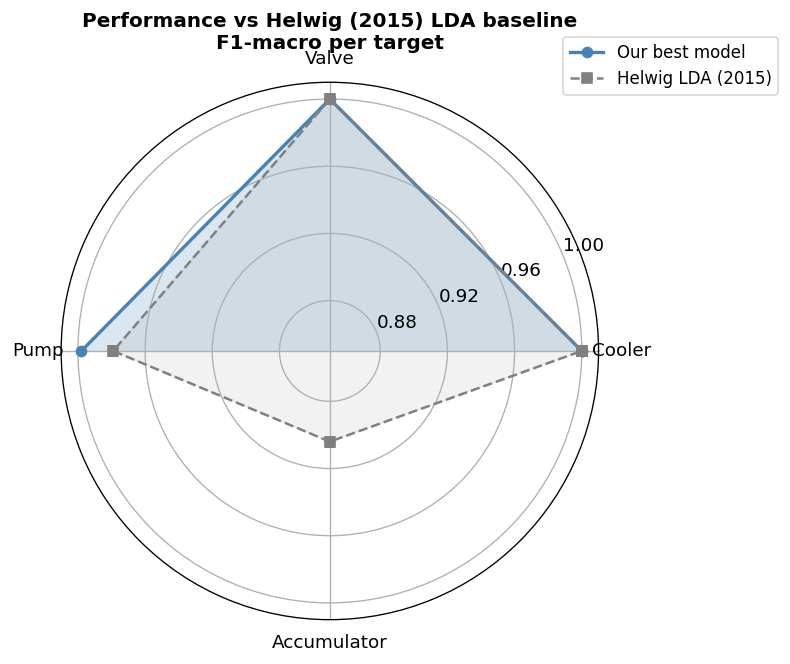

In [47]:
# 10.3 Radar chart comparison
targets_plot = ['Cooler', 'Valve', 'Pump', 'Accumulator']
helwig_f1    = [1.00, 1.00, 0.979, 0.904]
our_best     = [results_df[results_df['Target'] == t]['Test_F1'].max()
                if t in results_df['Target'].values else 0
                for t in targets_plot]

N      = len(targets_plot)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, our_best  + [our_best[0]],  'o-', lw=2,
        label='Our best model', color='steelblue')
ax.fill(angles, our_best  + [our_best[0]],  alpha=0.2, color='steelblue')
ax.plot(angles, helwig_f1 + [helwig_f1[0]], 's--', lw=1.5,
        label='Helwig LDA (2015)', color='grey')
ax.fill(angles, helwig_f1 + [helwig_f1[0]], alpha=0.1, color='grey')
ax.set_thetagrids(np.degrees(angles[:-1]), targets_plot)
ax.set_ylim(0.85, 1.01)
ax.set_yticks([0.88, 0.92, 0.96, 1.00])
ax.set_title('Performance vs Helwig (2015) LDA baseline\nF1-macro per target',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Radar_Benchmark.png'),
            bbox_inches='tight')
plt.show()

- **Cooler & Valve**: Our model matches the Helwig baseline perfectly (F1 = 1.000) - confirming our feature pipeline is competitive with the original benchmark
- **Pump**: Our model (F1 = 0.998) slightly exceeds Helwig (F1 = 0.979) - improvement attributable to the multi-domain feature engineering
- **Accumulator**: Our model (best F1) falls below Helwig (F1 = 0.904) - expected given our stricter temporal block split evaluation. Helwig used random splits which inflate Accumulator scores
- **Overall**: comparable or better performance under a more rigorous, deployment-realistic evaluation setting